# Real World Classification

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

# Question 1: K Folds - Cross Validation

## Data Preprocessing

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 72 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      500 non-null    int64  
 1   SepalLengthCm           472 non-null    float64
 2   SepalWidthCm            443 non-null    float64
 3   PetalLengthCm           350 non-null    float64
 4   PetalWidthCm            478 non-null    float64
 5   BranchLength            476 non-null    float64
 6   AvgDust                 500 non-null    float64
 7   SepalLengthMajorAxis    500 non-null    float64
 8   SepalLengthMinorAxis    500 non-null    float64
 9   SepalLengthElongation   500 non-null    float64
 10  SepalLengthCompactness  500 non-null    float64
 11  SepalLengthSpread       500 non-null    float64
 12  SepalLengthCurvature    500 non-null    float64
 13  SepalWidthMajorAxis     500 non-null    float64
 14  SepalWidthMinorAxis     500 non-null    float64
 15  

In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength', 'AvgDust', 'SepalLengthMajorAxis',
       'SepalLengthMinorAxis', 'SepalLengthElongation',
       'SepalLengthCompactness', 'SepalLengthSpread', 'SepalLengthCurvature',
       'SepalWidthMajorAxis', 'SepalWidthMinorAxis', 'SepalWidthElongation',
       'SepalWidthCompactness', 'SepalWidthSpread', 'SepalWidthCurvature',
       'PetalLengthMajorAxis', 'PetalLengthMinorAxis', 'PetalLengthElongation',
       'PetalLengthCompactness', 'PetalLengthSpread', 'PetalLengthCurvature',
       'PetalWidthMajorAxis', 'PetalWidthMinorAxis', 'PetalWidthElongation',
       'PetalWidthCompactness', 'PetalWidthSpread', 'PetalWidthCurvature',
       'IrisPigmentDensity', 'IrisPigmentUniformity', 'IrisPigmentContrast',
       'IrisPigmentGranularity', 'IrisVenationDensity', 'IrisVenationDepth',
       'IrisVenationSharpness', 'IrisVenationAsymmetry', 'FloralSymmetryScore',
       'FloralCompactnessScore', 

In [6]:
df[df['PetalWidthCm']<=0]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
6,7,6.3,3.3,4.700000,0.0,16.3,5.8,6.217246,6.433263,5.875367,...,0.503332,-0.646084,-1.511858,0.491013,0.317563,-1.104942,1.954232,-2.504990,0.536552,Iris-versicolor
41,42,6.1,3.0,NaN,-0.8,16.3,49.5,6.027123,5.827488,6.159649,...,0.968700,2.183968,-1.641392,-0.491076,-0.446787,-0.605695,-0.704740,-0.241480,0.041670,Iris-versicolor
54,55,6.5,3.0,NaN,-0.8,16.4,59.8,6.557692,6.673522,6.645652,...,0.459890,-1.372103,-1.456807,-0.413252,1.099892,-0.271728,0.028289,0.313557,-0.095100,Iris-virginica
91,92,6.9,3.9,NaN,-0.8,16.7,71.3,6.686094,6.686237,6.945315,...,-0.491275,0.310795,-0.849531,0.338771,0.924154,-0.402139,0.994426,-0.362912,1.128026,Iris-virginica
111,112,6.1,3.3,NaN,-0.0,16.3,5.8,6.228501,6.161557,5.972649,...,0.169808,0.076685,0.314890,0.023609,-0.235674,0.741921,1.040303,0.840125,0.767524,Iris-versicolor
125,126,6.2,3.0,4.600000,-0.9,16.6,49.5,6.479208,5.932342,6.367274,...,0.313866,-0.989002,-0.121396,0.602848,-0.022267,-0.061109,0.564385,-0.647595,0.488089,Iris-versicolor
135,136,6.0,3.2,NaN,-0.6,16.3,49.5,6.103417,5.931254,6.093462,...,0.140324,-0.279034,0.101114,-0.812550,-0.766600,-0.906332,-0.051322,-0.078302,-0.769102,Iris-versicolor
180,181,7.0,3.8,5.100000,-0.9,16.7,71.3,6.886908,6.622694,6.810346,...,-1.484500,0.054368,1.284102,-0.779706,0.388617,-0.849452,0.225983,-0.090232,-0.734670,Iris-virginica
182,183,6.2,3.0,5.085612,-0.8,16.3,49.5,5.786758,6.394371,6.152554,...,-1.649160,-0.415916,0.669971,0.158076,0.156814,-0.592292,-1.135118,2.006897,0.457660,Iris-versicolor
234,235,6.3,3.2,4.700000,-0.0,16.4,5.8,6.435890,6.414014,6.154092,...,0.081866,0.455876,-1.881790,-0.983051,2.850422,1.638473,0.467285,-0.113032,-1.197255,Iris-versicolor


### Median and Std report

In [7]:
missing_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength']
df[missing_cols].describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,472.000000,443.000000,350.000000,478.000000,476.000000
mean,6.320551,2.837472,5.085612,1.675732,16.302941
std,1.037115,0.389564,1.582807,0.706689,1.035228
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.600000,4.425000,1.300000,15.800000
50%,6.300000,2.900000,5.085612,1.600000,16.300000
75%,6.700000,3.100000,5.500000,2.000000,16.800000
max,9.600000,4.000000,9.200000,4.300000,19.700000


### Data Preprocessing - filling missing values

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    filled_X = imputer.fit_transform(df[feature_cols])
    df[feature_cols] = filled_X
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [9]:
print(df.shape, len(feature_cols))

(500, 72) 70


In [10]:
df[missing_cols].describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.319840,2.837040,5.049883,1.684440,16.303440
std,1.009275,0.372434,1.514955,0.694645,1.011012
min,3.000000,1.500000,0.500000,-1.000000,12.700000
25%,5.800000,2.630000,4.500000,1.300000,15.800000
50%,6.300000,2.900000,5.035683,1.700000,16.300000
75%,6.700000,3.040000,5.300000,2.000000,16.700000
max,9.600000,4.000000,9.200000,4.300000,19.700000


In [11]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Model Training

### Prepare the data

In [12]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


In [13]:
# Use the LinearModel to fit the data
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from model.metrics import evaluate_binary_classifier
from sklearn.model_selection import cross_val_score, KFold

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
print(seed)

40


### Train models with CV


================ reg_lambda = 1.0 ================

================ learning_rate = 0.005 ================
50. Training loss: 5.345292180193646, Val loss:6.167643284831131
100. Training loss: 5.296224011808861, Val loss:6.127281373274276
150. Training loss: 4.8400306524749, Val loss:5.663289839042357
200. Training loss: 3.956030489960089, Val loss:4.678448177505873
250. Training loss: 3.025551752960105, Val loss:3.5855917648371616
300. Training loss: 2.111379043647362, Val loss:2.511005704482397
350. Training loss: 1.2883999507464152, Val loss:1.5385431768051308
400. Training loss: 0.7867364587362522, Val loss:0.9271068875768295
450. Training loss: 0.6471882473534915, Val loss:0.7322842377714013
500. Training loss: 0.6253360670929398, Val loss:0.6890451485310944
550. Training loss: 0.6214428184404132, Val loss:0.678007488830359
600. Training loss: 0.6197227070202371, Val loss:0.6742567009782185
650. Training loss: 0.6182655994072067, Val loss:0.6725127370629195
700. Training loss: 0.

7000. Training loss: 0.5244466467116792, Val loss:0.6273208344705833
7050. Training loss: 0.5240825870782485, Val loss:0.6272084456686857
7100. Training loss: 0.5237216359193344, Val loss:0.6270977599369599
7150. Training loss: 0.5233637582617431, Val loss:0.6269887521214148
7200. Training loss: 0.5230089196310523, Val loss:0.6268813974607151
7250. Training loss: 0.52265708604303, Val loss:0.626775671579446
7300. Training loss: 0.5223082239952224, Val loss:0.6266715504815057
7350. Training loss: 0.5219623004587101, Val loss:0.6265690105436216
7400. Training loss: 0.5216192828700269, Val loss:0.6264680285089936
7450. Training loss: 0.5212791391232388, Val loss:0.6263685814810546
7500. Training loss: 0.520941837562178, Val loss:0.6262706469173495
7550. Training loss: 0.5206073469728321, Val loss:0.6261742026235313
7600. Training loss: 0.5202756365758793, Val loss:0.6260792267474689
7650. Training loss: 0.5199466760193726, Val loss:0.6259856977734655
7700. Training loss: 0.519620435371565

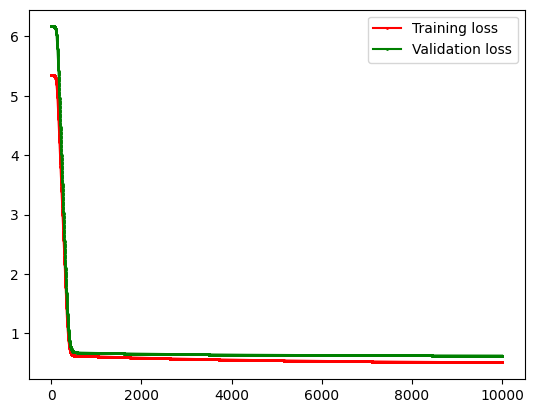

50. Training loss: 5.394694412658657, Val loss:5.345292180193648
100. Training loss: 5.327678143061511, Val loss:5.28415044254151
150. Training loss: 4.850816735360293, Val loss:4.854330116367889
200. Training loss: 3.9606317304733607, Val loss:3.972918362398221
250. Training loss: 3.0210325836960124, Val loss:3.0261011133586826
300. Training loss: 2.099539307429306, Val loss:2.0978209891647226
350. Training loss: 1.2777762484087407, Val loss:1.2729125617213366
400. Training loss: 0.7898716561395798, Val loss:0.7914404706472722
450. Training loss: 0.6570669486929853, Val loss:0.6653426665791166
500. Training loss: 0.6360112009785903, Val loss:0.6469307267030973
550. Training loss: 0.6321007806327863, Val loss:0.6441204215815117
600. Training loss: 0.6303150691858944, Val loss:0.6429709668852991
650. Training loss: 0.6287948256404936, Val loss:0.641939716299936
700. Training loss: 0.6273226661256253, Val loss:0.64090592999846
750. Training loss: 0.6258734178254893, Val loss:0.6398753046

6650. Training loss: 0.5332288956661085, Val loss:0.5787853852143316
6700. Training loss: 0.5328132508869523, Val loss:0.5785612975309405
6750. Training loss: 0.5324010398415128, Val loss:0.5783398584074486
6800. Training loss: 0.5319922238995484, Val loss:0.578121034219315
6850. Training loss: 0.5315867649990208, Val loss:0.5779047918206481
6900. Training loss: 0.5311846256357152, Val loss:0.5776910985364913
6950. Training loss: 0.5307857688530874, Val loss:0.5774799221552502
7000. Training loss: 0.5303901582323293, Val loss:0.5772712309212581
7050. Training loss: 0.529997757882651, Val loss:0.577064993527478
7100. Training loss: 0.5296085324317696, Val loss:0.576861179108336
7150. Training loss: 0.5292224470166034, Val loss:0.5766597572326847
7200. Training loss: 0.5288394672741648, Val loss:0.5764606978968957
7250. Training loss: 0.5284595593326465, Val loss:0.5762639715180752
7300. Training loss: 0.5280826898026986, Val loss:0.576069548927401
7350. Training loss: 0.5277088257688882

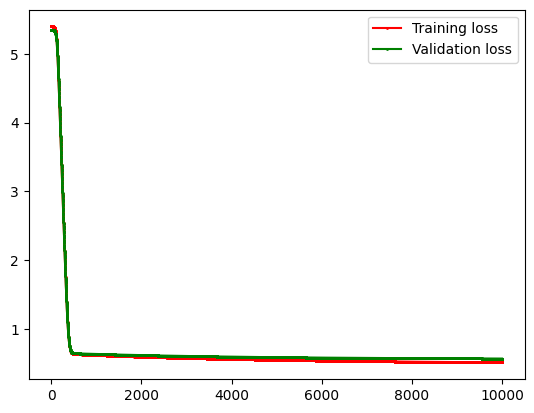

50. Training loss: 5.189316423750482, Val loss:6.373231060990504
100. Training loss: 5.144702121394793, Val loss:6.318706012495741
150. Training loss: 4.77916289380206, Val loss:5.82984597717447
200. Training loss: 3.9632102588855327, Val loss:4.863733381625536
250. Training loss: 3.0745912315989585, Val loss:3.7669271917739735
300. Training loss: 2.1986754583676804, Val loss:2.6854382393951437
350. Training loss: 1.3913011182130697, Val loss:1.6858767110500197
400. Training loss: 0.849595746507763, Val loss:0.9996225588210119
450. Training loss: 0.67483246821199, Val loss:0.74851203834017
500. Training loss: 0.6456173084590826, Val loss:0.6882011022048327
550. Training loss: 0.6408761076903016, Val loss:0.6725148375058164
600. Training loss: 0.6391647091367797, Val loss:0.6672753322358481
650. Training loss: 0.6378139253545209, Val loss:0.6649444818777169
700. Training loss: 0.6365192313600743, Val loss:0.6635246691632034
750. Training loss: 0.6352466537157788, Val loss:0.662410105910

7150. Training loss: 0.5520021596796557, Val loss:0.600059177375131
7200. Training loss: 0.5516780167942251, Val loss:0.5998330564106472
7250. Training loss: 0.551356506937141, Val loss:0.5996091004840124
7300. Training loss: 0.5510376008395808, Val loss:0.5993872859933079
7350. Training loss: 0.5507212696606392, Val loss:0.5991675896565886
7400. Training loss: 0.5504074849795267, Val loss:0.5989499885063131
7450. Training loss: 0.5500962187879359, Val loss:0.5987344598838931
7500. Training loss: 0.5497874434825728, Val loss:0.5985209814343619
7550. Training loss: 0.5494811318578492, Val loss:0.5983095311011563
7600. Training loss: 0.5491772570987307, Val loss:0.5981000871210076
7650. Training loss: 0.5488757927737379, Val loss:0.5978926280189457
7700. Training loss: 0.5485767128280973, Val loss:0.5976871326034059
7750. Training loss: 0.5482799915770367, Val loss:0.5974835799614385
7800. Training loss: 0.5479856036992231, Val loss:0.5972819494540227
7850. Training loss: 0.5476935242303

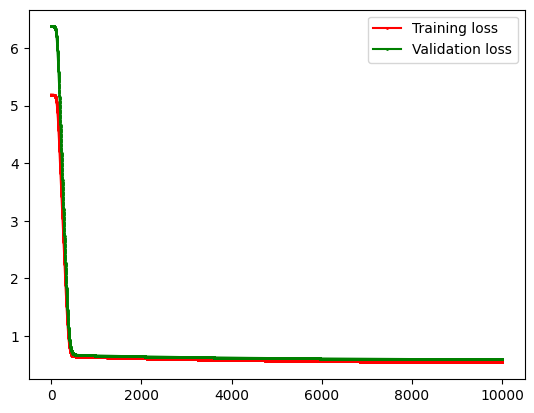

50. Training loss: 5.4973476921201865, Val loss:5.962055508671761
100. Training loss: 5.4251468220123, Val loss:5.9214082984905
150. Training loss: 4.904506972388679, Val loss:5.379076672245818
200. Training loss: 3.95942776419597, Val loss:4.362169650287916
250. Training loss: 2.9783912486713544, Val loss:3.280634007866149
300. Training loss: 2.019736294531529, Val loss:2.223747498866934
350. Training loss: 1.1883730491417357, Val loss:1.3076339082441402
400. Training loss: 0.7445265827640325, Val loss:0.8141947534060707
450. Training loss: 0.6405112323492627, Val loss:0.6886025041746249
500. Training loss: 0.6250237534767893, Val loss:0.6649303424239142
550. Training loss: 0.6217854600133189, Val loss:0.6591087840822087
600. Training loss: 0.6199972477523807, Val loss:0.6567708599731031
650. Training loss: 0.6183943886106105, Val loss:0.6553124738642307
700. Training loss: 0.616834441897857, Val loss:0.6541263780118997
750. Training loss: 0.6153012128269328, Val loss:0.65303909850869

7250. Training loss: 0.5216197228072266, Val loss:0.5902604503558917
7300. Training loss: 0.521295582635125, Val loss:0.5900518299854094
7350. Training loss: 0.5209743401753967, Val loss:0.58984520030679
7400. Training loss: 0.5206559605404292, Val loss:0.5896405370696199
7450. Training loss: 0.520340409389512, Val loss:0.589437816403474
7500. Training loss: 0.5200276529182734, Val loss:0.5892370148105783
7550. Training loss: 0.5197176578483542, Val loss:0.5890381091586374
7600. Training loss: 0.5194103914173167, Val loss:0.5888410766738258
7650. Training loss: 0.5191058213687796, Val loss:0.5886458949339349
7700. Training loss: 0.5188039159427742, Val loss:0.5884525418616755
7750. Training loss: 0.5185046438663172, Val loss:0.5882609957181278
7800. Training loss: 0.5182079743441929, Val loss:0.588071235096342
7850. Training loss: 0.5179138770499404, Val loss:0.5878832389150747
7900. Training loss: 0.5176223221170415, Val loss:0.5876969864126701
7950. Training loss: 0.5173332801303022,

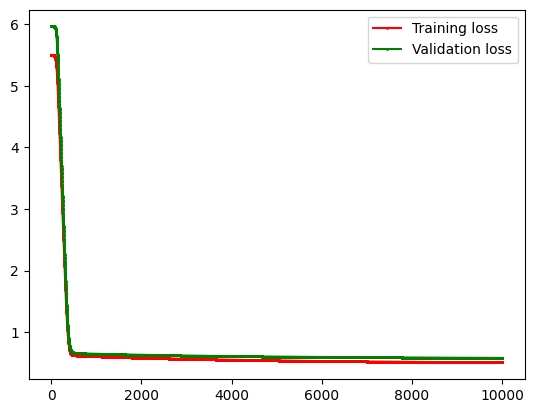

50. Training loss: 5.4460124058415245, Val loss:5.139704404034276
100. Training loss: 5.376473013035801, Val loss:5.0688183983958695
150. Training loss: 4.887459900636521, Val loss:4.521322856855206
200. Training loss: 3.9645932919559876, Val loss:3.6606534222930116
250. Training loss: 2.9988103847146403, Val loss:2.7494074786797347
300. Training loss: 2.0538423983531042, Val loss:1.8592448051920285
350. Training loss: 1.2260247307999932, Val loss:1.0884485930552181
400. Training loss: 0.7672320341984797, Val loss:0.6826005904648385
450. Training loss: 0.6543627195242855, Val loss:0.5973565051437765
500. Training loss: 0.6374943147180645, Val loss:0.5903945719318049
550. Training loss: 0.6343406026667991, Val loss:0.5908226326403538
600. Training loss: 0.6328241569451676, Val loss:0.5908223064557202
650. Training loss: 0.631508155755226, Val loss:0.5903408056842541
700. Training loss: 0.6302294450083201, Val loss:0.5896686391897215
750. Training loss: 0.628969618552853, Val loss:0.5889

7000. Training loss: 0.5455635328460995, Val loss:0.550694634569994
7050. Training loss: 0.5452232917249298, Val loss:0.5506146751603146
7100. Training loss: 0.5448858634527726, Val loss:0.5505362887366321
7150. Training loss: 0.5445512168714532, Val loss:0.5504594508957465
7200. Training loss: 0.5442193212648723, Val loss:0.5503841376345977
7250. Training loss: 0.543890146351391, Val loss:0.5503103253429897
7300. Training loss: 0.5435636622763701, Val loss:0.550237990796463
7350. Training loss: 0.5432398396048546, Val loss:0.550167111149309
7400. Training loss: 0.5429186493144073, Val loss:0.5500976639277271
7450. Training loss: 0.542600062788083, Val loss:0.5500296270231179
7500. Training loss: 0.5422840518075425, Val loss:0.5499629786855108
7550. Training loss: 0.5419705885463021, Val loss:0.5498976975171255
7600. Training loss: 0.5416596455631166, Val loss:0.5498337624660581
7650. Training loss: 0.5413511957954927, Val loss:0.5497711528200969
7700. Training loss: 0.5410452125533293

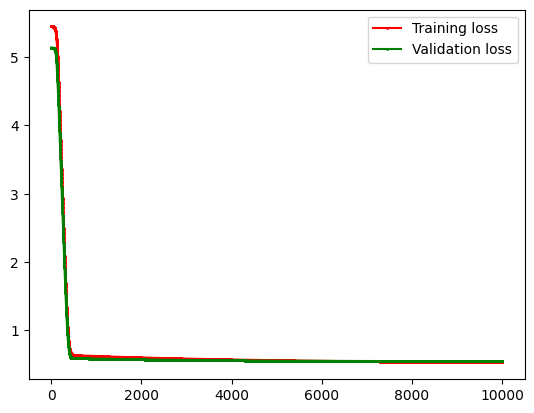


================ learning_rate = 0.01 ================
50. Training loss: 5.299147712630601, Val loss:6.127275524294197
100. Training loss: 3.974607428324405, Val loss:4.678345773291793
150. Training loss: 2.1289457971750148, Val loss:2.5106434392104537
200. Training loss: 0.7907199254622143, Val loss:0.9248332476519108
250. Training loss: 0.6253291500072974, Val loss:0.6885694079270481
300. Training loss: 0.6197460103382938, Val loss:0.6741833652514472
350. Training loss: 0.6168787712722311, Val loss:0.6713854873532382
400. Training loss: 0.6141170561128383, Val loss:0.6696721914082835
450. Training loss: 0.6114276973633174, Val loss:0.6681203797005466
500. Training loss: 0.6088080159904653, Val loss:0.6666304058770748
550. Training loss: 0.6062556912988573, Val loss:0.6651898461489536
600. Training loss: 0.603768485230489, Val loss:0.6637958464125646
650. Training loss: 0.6013442450812997, Val loss:0.6624466591792793
700. Training loss: 0.5989809011447875, Val loss:0.661140713541721

6500. Training loss: 0.4960505153943676, Val loss:0.6212194161646096
6550. Training loss: 0.49575444160301024, Val loss:0.6211890022083194
6600. Training loss: 0.49546224099786745, Val loss:0.6211597568716234
6650. Training loss: 0.495173850017619, Val loss:0.6211316461582379
6700. Training loss: 0.4948892064071301, Val loss:0.6211046370038306
6750. Training loss: 0.49460824918477414, Val loss:0.6210786972496997
6800. Training loss: 0.4943309186107164, Val loss:0.6210537956172519
6850. Training loss: 0.4940571561561265, Val loss:0.6210299016832508
6900. Training loss: 0.4937869044732892, Val loss:0.6210069858558115
6950. Training loss: 0.49352010736658297, Val loss:0.6209850193511183
7000. Training loss: 0.49325670976429653, Val loss:0.6209639741708385
7050. Training loss: 0.49299665769125867, Val loss:0.6209438230802115
7100. Training loss: 0.49273989824225023, Val loss:0.6209245395867926
7150. Training loss: 0.49248637955617675, Val loss:0.6209060979198269
7200. Training loss: 0.4922

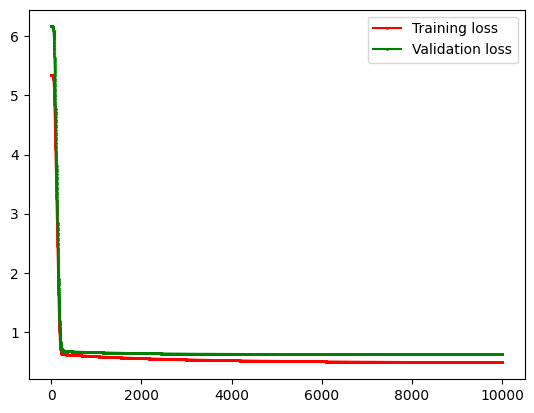

50. Training loss: 5.331089283193235, Val loss:5.284143019441189
100. Training loss: 3.979394392628396, Val loss:3.9728290572741725
150. Training loss: 2.1171841930513, Val loss:2.0974880518049663
200. Training loss: 0.7935995298385411, Val loss:0.7897369741229091
250. Training loss: 0.6360053182720894, Val loss:0.6468100486090709
300. Training loss: 0.6303394670630055, Val loss:0.6429701743347428
350. Training loss: 0.6273481827441947, Val loss:0.6409041576969433
400. Training loss: 0.6244686324353242, Val loss:0.6388523416028798
450. Training loss: 0.6216659231098589, Val loss:0.6368506594581975
500. Training loss: 0.6189369786596552, Val loss:0.6349041019200451
550. Training loss: 0.6162791523255944, Val loss:0.6330116291911521
600. Training loss: 0.6136899058772858, Val loss:0.6311715902358046
650. Training loss: 0.6111668095835304, Val loss:0.629382326009589
700. Training loss: 0.6087075382681195, Val loss:0.6276422309781459
750. Training loss: 0.6063098665937084, Val loss:0.62594

7200. Training loss: 0.4947287407738569, Val loss:0.5625835357892303
7250. Training loss: 0.4944447894417041, Val loss:0.5625092286369265
7300. Training loss: 0.4941641685901575, Val loss:0.5624366520603343
7350. Training loss: 0.49388682903048214, Val loss:0.5623657691854024
7400. Training loss: 0.4936127224944698, Val loss:0.5622965439682679
7450. Training loss: 0.4933418016131425, Val loss:0.5622289411747126
7500. Training loss: 0.49307401989604344, Val loss:0.5621629263601787
7550. Training loss: 0.4928093317110965, Val loss:0.5620984658503299
7600. Training loss: 0.49254769226501605, Val loss:0.5620355267221371
7650. Training loss: 0.4922890575842504, Val loss:0.5619740767854802
7700. Training loss: 0.49203338449644063, Val loss:0.5619140845652418
7750. Training loss: 0.4917806306123799, Val loss:0.5618555192838863
7800. Training loss: 0.49153075430845766, Val loss:0.5617983508445057
7850. Training loss: 0.4912837147095728, Val loss:0.5617425498143186
7900. Training loss: 0.491039

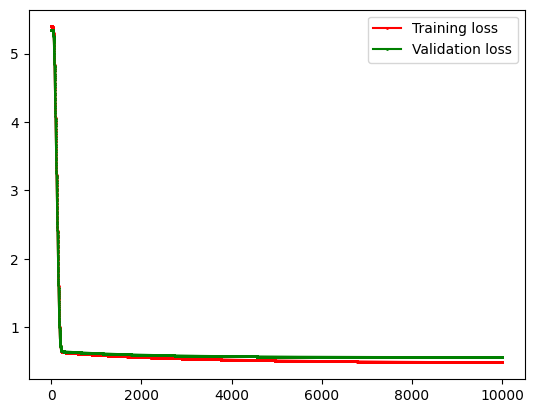

50. Training loss: 5.147128316772911, Val loss:6.31869732831597
100. Training loss: 3.9809463501494227, Val loss:4.863631293395935
150. Training loss: 2.215629103228081, Val loss:2.685120960235083
200. Training loss: 0.8546944018239814, Val loss:0.9973362065706597
250. Training loss: 0.6456110072687979, Val loss:0.6875703854363568
300. Training loss: 0.6391852616190927, Val loss:0.6671728284045635
350. Training loss: 0.6365415403803192, Val loss:0.6635069593071455
400. Training loss: 0.6340138138502986, Val loss:0.6614012270819211
450. Training loss: 0.6315563596201714, Val loss:0.6595085505694536
500. Training loss: 0.6291661859966562, Val loss:0.6576846776503639
550. Training loss: 0.6268407828167943, Val loss:0.6559122879613764
600. Training loss: 0.6245777430515477, Val loss:0.6541878945911253
650. Training loss: 0.6223747664969689, Val loss:0.6525095912977853
700. Training loss: 0.6202296560278968, Val loss:0.6508757143193444
750. Training loss: 0.6181403126879271, Val loss:0.6492

7100. Training loss: 0.5233968712295446, Val loss:0.5821813618620416
7150. Training loss: 0.5231521337558116, Val loss:0.582056956441493
7200. Training loss: 0.5229102828765425, Val loss:0.5819347513681664
7250. Training loss: 0.5226712751916083, Val loss:0.5818147080723731
7300. Training loss: 0.5224350681294254, Val loss:0.5816967887141462
7350. Training loss: 0.5222016199274024, Val loss:0.5815809561674837
7400. Training loss: 0.5219708896129372, Val loss:0.5814671740050003
7450. Training loss: 0.5217428369849509, Val loss:0.5813554064829661
7500. Training loss: 0.5215174225959373, Val loss:0.5812456185267304
7550. Training loss: 0.521294607734514, Val loss:0.5811377757165078
7600. Training loss: 0.5210743544084568, Val loss:0.5810318442735259
7650. Training loss: 0.5208566253282028, Val loss:0.5809277910465164
7700. Training loss: 0.5206413838908054, Val loss:0.5808255834985422
7750. Training loss: 0.5204285941643297, Val loss:0.580725189694151
7800. Training loss: 0.52021822087267

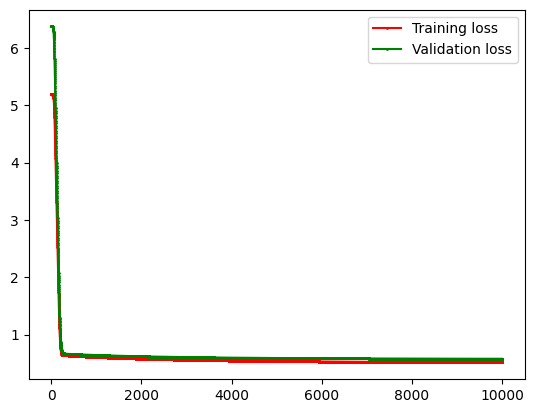

50. Training loss: 5.429193137004309, Val loss:5.921400467199935
100. Training loss: 3.97902340643492, Val loss:4.36206711925595
150. Training loss: 2.037939701024492, Val loss:2.2233169249890166
200. Training loss: 0.7473273807575648, Val loss:0.812224397614869
250. Training loss: 0.6250212422062563, Val loss:0.6646778265823762
300. Training loss: 0.6200233155174174, Val loss:0.6567366373949168
350. Training loss: 0.6168607782192304, Val loss:0.6541187991643301
400. Training loss: 0.6138177719598222, Val loss:0.6519920601762241
450. Training loss: 0.6108702877400106, Val loss:0.6499761736252107
500. Training loss: 0.6080141977051368, Val loss:0.6480288235888935
550. Training loss: 0.6052457405969948, Val loss:0.6461430335701646
600. Training loss: 0.6025613334872507, Val loss:0.6443158044132343
650. Training loss: 0.5999575660931631, Val loss:0.6425446854404692
700. Training loss: 0.5974311925474698, Val loss:0.6408273909584083
750. Training loss: 0.5949791229844915, Val loss:0.639161

7200. Training loss: 0.49396330366125646, Val loss:0.5731818822203218
7250. Training loss: 0.49374367252370216, Val loss:0.5730558151406496
7300. Training loss: 0.49352687717732385, Val loss:0.5729316236717477
7350. Training loss: 0.49331287221651643, Val loss:0.5728092762726621
7400. Training loss: 0.4931016131446696, Val loss:0.5726887420359953
7450. Training loss: 0.4928930563517161, Val loss:0.5725699906723347
7500. Training loss: 0.492687159092348, Val loss:0.5724529924951448
7550. Training loss: 0.4924838794648752, Val loss:0.5723377184061051
7600. Training loss: 0.49228317639070523, Val loss:0.5722241398808778
7650. Training loss: 0.4920850095944231, Val loss:0.5721122289552925
7700. Training loss: 0.4918893395844505, Val loss:0.5720019582119322
7750. Training loss: 0.4916961276342648, Val loss:0.5718933007671071
7800. Training loss: 0.4915053357641583, Val loss:0.5717862302582049
7850. Training loss: 0.49131692672352095, Val loss:0.5716807208314
7900. Training loss: 0.491130863

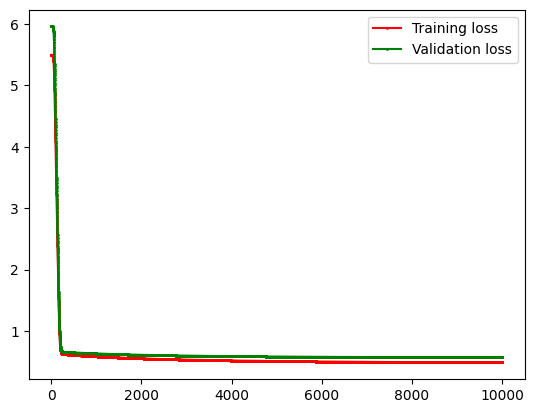

50. Training loss: 5.3804782630183015, Val loss:5.068807785015303
100. Training loss: 3.9838823830050467, Val loss:3.6605671475434605
150. Training loss: 2.0718402282428294, Val loss:1.8588982597052233
200. Training loss: 0.7703263870819106, Val loss:0.6811687820364473
250. Training loss: 0.6374855400368136, Val loss:0.5904091178179861
300. Training loss: 0.6328451746444751, Val loss:0.5908423533459511
350. Training loss: 0.6302512823540168, Val loss:0.589668579827669
400. Training loss: 0.6277475624379554, Val loss:0.5881919473531125
450. Training loss: 0.6253086754749121, Val loss:0.5867281854226317
500. Training loss: 0.6229322302245717, Val loss:0.5853119466888701
550. Training loss: 0.6206161278471082, Val loss:0.5839452928280574
600. Training loss: 0.6183583481252016, Val loss:0.5826267813698163
650. Training loss: 0.6161569502089668, Val loss:0.5813546559421275
700. Training loss: 0.6140100700001033, Val loss:0.5801271918926295
750. Training loss: 0.6119159169611851, Val loss:0.

7200. Training loss: 0.5149586370632855, Val loss:0.5480373827286636
7250. Training loss: 0.5147181189818039, Val loss:0.5480619153666312
7300. Training loss: 0.5144804813621161, Val loss:0.548087045165584
7350. Training loss: 0.5142456806986385, Val loss:0.5481127511403299
7400. Training loss: 0.5140136743128095, Val loss:0.5481390128800616
7450. Training loss: 0.5137844203338104, Val loss:0.5481658105321742
7500. Training loss: 0.5135578776798192, Val loss:0.5481931247865759
7550. Training loss: 0.5133340060397784, Val loss:0.5482209368604769
7600. Training loss: 0.5131127658556639, Val loss:0.5482492284836397
7650. Training loss: 0.5128941183052355, Val loss:0.5482779818840736
7700. Training loss: 0.5126780252852574, Val loss:0.5483071797741653
7750. Training loss: 0.5124644493951712, Val loss:0.5483368053372207
7800. Training loss: 0.5122533539212089, Val loss:0.5483668422144161
7850. Training loss: 0.512044702820932, Val loss:0.5483972744921367
7900. Training loss: 0.5118384607081

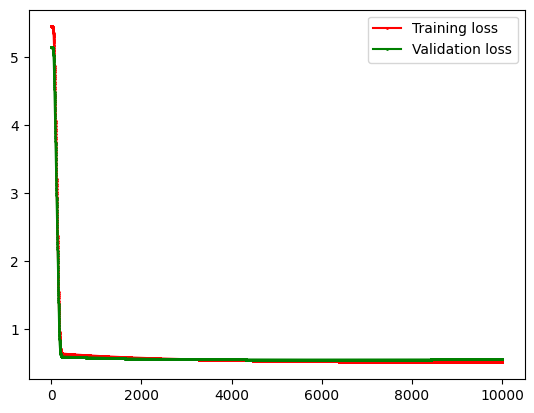


================ learning_rate = 0.1 ================
50. Training loss: 0.6092049289648279, Val loss:0.6666021064008399
100. Training loss: 0.5862575114573082, Val loss:0.6541010594795245
150. Training loss: 0.5682417254074082, Val loss:0.6450290632462633
200. Training loss: 0.5538426712998972, Val loss:0.6384000239675256
250. Training loss: 0.5421519172984726, Val loss:0.6335318646107467
300. Training loss: 0.5325293497091516, Val loss:0.6299459833586215
350. Training loss: 0.5245145666814778, Val loss:0.6273019163541854
400. Training loss: 0.517769780731377, Val loss:0.6253544238403379
450. Training loss: 0.5120425308620752, Val loss:0.6239248948893072
500. Training loss: 0.5071409030545577, Val loss:0.622881993022766
550. Training loss: 0.5029167485007802, Val loss:0.6221283515715993
600. Training loss: 0.49925410079064403, Val loss:0.6215912918963423
650. Training loss: 0.4960610345940023, Val loss:0.6212162589199296
700. Training loss: 0.4932638447433737, Val loss:0.620962120054

7250. Training loss: 0.46839032690741444, Val loss:0.6207676833780958
7300. Training loss: 0.46839014172792653, Val loss:0.6207674876483489
7350. Training loss: 0.4683899669849234, Val loss:0.620767302069099
7400. Training loss: 0.4683898020780188, Val loss:0.6207671261173672
7450. Training loss: 0.4683896464421327, Val loss:0.6207669592966629
7500. Training loss: 0.46838949954536485, Val loss:0.6207668011356874
7550. Training loss: 0.4683893608869991, Val loss:0.6207666511870962
7600. Training loss: 0.46838922999563143, Val loss:0.6207665090263201
7650. Training loss: 0.46838910642741294, Val loss:0.6207663742504385
7700. Training loss: 0.4683889897644017, Val loss:0.6207662464771071
7750. Training loss: 0.46838887961301545, Val loss:0.6207661253435355
7800. Training loss: 0.4683887756025783, Val loss:0.6207660105055116
7850. Training loss: 0.46838867738395795, Val loss:0.6207659016364749
7900. Training loss: 0.468388584628285, Val loss:0.6207657984266316
7950. Training loss: 0.468388

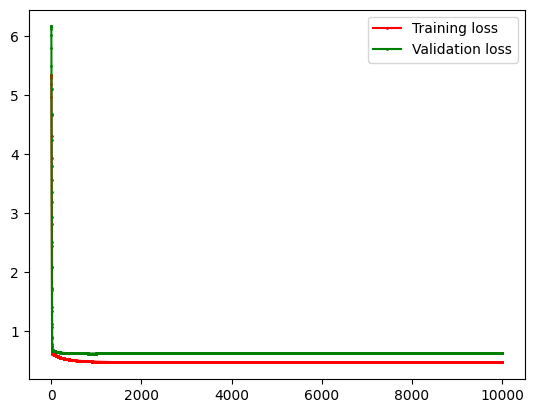

50. Training loss: 0.6193515513699838, Val loss:0.6348539055982609
100. Training loss: 0.5954717835989626, Val loss:0.6180935519836914
150. Training loss: 0.5766990134851697, Val loss:0.6053195152101539
200. Training loss: 0.561621731180462, Val loss:0.5954887642172572
250. Training loss: 0.5492942345172591, Val loss:0.5878614960022495
300. Training loss: 0.5390640263829457, Val loss:0.5819037876085772
350. Training loss: 0.5304678688839163, Val loss:0.5772242550073943
400. Training loss: 0.5231682353247503, Val loss:0.5735320938409062
450. Training loss: 0.5169134979184317, Val loss:0.570608688888691
500. Training loss: 0.511512283123212, Val loss:0.5682880051424531
550. Training loss: 0.506816487467366, Val loss:0.5664427932312555
600. Training loss: 0.5027097318398975, Val loss:0.5649747304510362
650. Training loss: 0.49909932492056786, Val loss:0.5638072787216711
700. Training loss: 0.4959105500219144, Val loss:0.5628804501999445
750. Training loss: 0.49308252709860795, Val loss:0.

7200. Training loss: 0.4652990953507517, Val loss:0.5615419210327504
7250. Training loss: 0.46529881348815394, Val loss:0.5615420176061343
7300. Training loss: 0.46529854798785264, Val loss:0.5615421090797323
7350. Training loss: 0.46529829788636096, Val loss:0.561542195740197
7400. Training loss: 0.46529806227779336, Val loss:0.5615422778570228
7450. Training loss: 0.46529784031036364, Val loss:0.5615423556836304
7500. Training loss: 0.46529763118310125, Val loss:0.5615424294583805
7550. Training loss: 0.4652974341427689, Val loss:0.5615424994055195
7600. Training loss: 0.4652972484809725, Val loss:0.5615425657360643
7650. Training loss: 0.4652970735314476, Val loss:0.561542628648629
7700. Training loss: 0.46529690866751466, Val loss:0.5615426883301973
7750. Training loss: 0.46529675329968906, Val loss:0.5615427449568448
7800. Training loss: 0.4652966068734391, Val loss:0.5615427986944148
7850. Training loss: 0.4652964688670817, Val loss:0.561542849699149
7900. Training loss: 0.465296

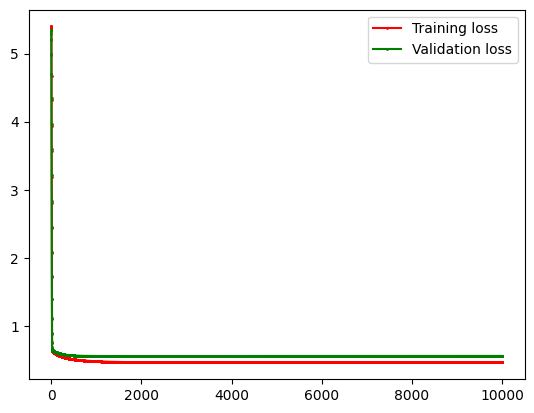

50. Training loss: 0.6295275477051353, Val loss:0.6576466224569464
100. Training loss: 0.6087201129047026, Val loss:0.6418788206420347
150. Training loss: 0.5925030899075111, Val loss:0.6296382653124816
200. Training loss: 0.5795661065033807, Val loss:0.6199544739770178
250. Training loss: 0.569043367402483, Val loss:0.6121812422913468
300. Training loss: 0.5603451846976254, Val loss:0.6058720950783422
350. Training loss: 0.5530579207869589, Val loss:0.6007079306976977
400. Training loss: 0.5468834252480719, Val loss:0.5964538011192203
450. Training loss: 0.5416014735878224, Val loss:0.5929322863394118
500. Training loss: 0.5370458486630186, Val loss:0.5900065571911508
550. Training loss: 0.53308869873263, Val loss:0.5875692500932038
600. Training loss: 0.5296300411729351, Val loss:0.5855349286137272
650. Training loss: 0.5265905461042636, Val loss:0.5838348236571311
700. Training loss: 0.5239064625817111, Val loss:0.5824130637494743
750. Training loss: 0.5215259776962438, Val loss:0.5

7150. Training loss: 0.49766893783713023, Val loss:0.5766008543085841
7200. Training loss: 0.4976685771644546, Val loss:0.5766009933763776
7250. Training loss: 0.49766823622818357, Val loss:0.5766011248270754
7300. Training loss: 0.49766791392660065, Val loss:0.576601249080379
7350. Training loss: 0.4976676092208087, Val loss:0.5766013665325387
7400. Training loss: 0.4976673211310639, Val loss:0.5766014775576915
7450. Training loss: 0.49766704873333073, Val loss:0.5766015825091199
7500. Training loss: 0.4976667911560421, Val loss:0.5766016817204372
7550. Training loss: 0.49766654757705175, Val loss:0.5766017755067051
7600. Training loss: 0.49766631722076976, Val loss:0.5766018641654859
7650. Training loss: 0.49766609935546663, Val loss:0.5766019479778313
7700. Training loss: 0.49766589329073796, Val loss:0.5766020272092182
7750. Training loss: 0.4976656983751194, Val loss:0.5766021021104264
7800. Training loss: 0.497665513993842, Val loss:0.576602172918368
7850. Training loss: 0.497665

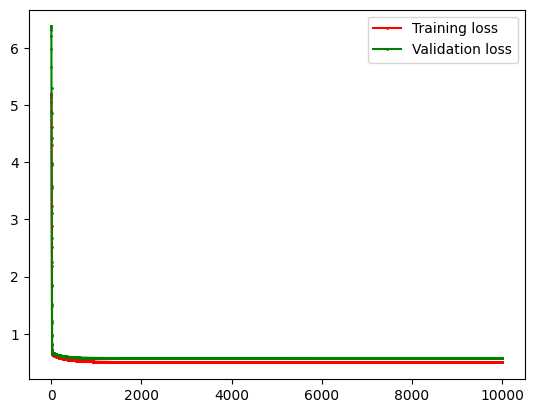

50. Training loss: 0.6084329711108939, Val loss:0.6479730696501703
100. Training loss: 0.5840172969516045, Val loss:0.6314812364807924
150. Training loss: 0.5656028772119039, Val loss:0.6191251769963204
200. Training loss: 0.5513292315607111, Val loss:0.6096186816019313
250. Training loss: 0.540008751039362, Val loss:0.6021425112811108
300. Training loss: 0.5308579472298095, Val loss:0.5961563648396749
350. Training loss: 0.5233431128018785, Val loss:0.5912920361299063
400. Training loss: 0.5170897840750314, Val loss:0.5872910149448821
450. Training loss: 0.5118281342800944, Val loss:0.58396690326361
500. Training loss: 0.5073590641470683, Val loss:0.5811820767971968
550. Training loss: 0.5035325398058796, Val loss:0.5788327687775003
600. Training loss: 0.5002333801877651, Val loss:0.5768392783475454
650. Training loss: 0.49737169797935576, Val loss:0.575139382527099
700. Training loss: 0.4948763216003297, Val loss:0.5736838017747413
750. Training loss: 0.49269017219483213, Val loss:0.

6900. Training loss: 0.47345133014425944, Val loss:0.5642864689684405
6950. Training loss: 0.47345111712911747, Val loss:0.564286568361864
7000. Training loss: 0.47345091580882975, Val loss:0.5642866625751719
7050. Training loss: 0.47345072551728695, Val loss:0.5642867518708243
7100. Training loss: 0.47345054562787453, Val loss:0.5642868364985046
7150. Training loss: 0.4734503755510279, Val loss:0.5642869166956975
7200. Training loss: 0.473450214731946, Val loss:0.5642869926882464
7250. Training loss: 0.4734500626484518, Val loss:0.5642870646908895
7300. Training loss: 0.4734499188089917, Val loss:0.5642871329077731
7350. Training loss: 0.47344978275076227, Val loss:0.5642871975329452
7400. Training loss: 0.4734496540379571, Val loss:0.5642872587508277
7450. Training loss: 0.4734495322601257, Val loss:0.5642873167366708
7500. Training loss: 0.4734494170306355, Val loss:0.5642873716569847
7550. Training loss: 0.4734493079852336, Val loss:0.5642874236699575
7600. Training loss: 0.4734492

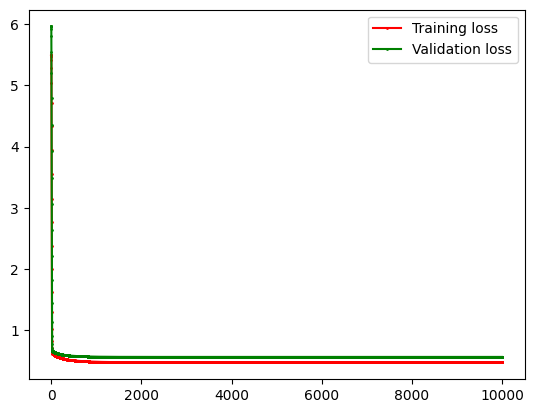

50. Training loss: 0.6232875749355091, Val loss:0.5852324109106313
100. Training loss: 0.6024345904544324, Val loss:0.57353735909993
150. Training loss: 0.5859936821565839, Val loss:0.5653269819426143
200. Training loss: 0.5727898250209068, Val loss:0.5595423911759323
250. Training loss: 0.5620140471607326, Val loss:0.5554705710785929
300. Training loss: 0.5530970759314265, Val loss:0.5526230402265921
350. Training loss: 0.5456294682526529, Val loss:0.5506596227158813
400. Training loss: 0.5393105762961036, Val loss:0.5493398619153383
450. Training loss: 0.5339153821505525, Val loss:0.5484915102343321
500. Training loss: 0.5292725205292149, Val loss:0.5479897236157584
550. Training loss: 0.5252494192125892, Val loss:0.5477430836020174
600. Training loss: 0.5217420523025329, Val loss:0.5476840523549756
650. Training loss: 0.5186677411132877, Val loss:0.5477623561881698
700. Training loss: 0.5159600073318401, Val loss:0.5479403356767133
750. Training loss: 0.5135648336354862, Val loss:0.

7350. Training loss: 0.4902798908305278, Val loss:0.55794010335393
7400. Training loss: 0.4902796558546392, Val loss:0.5579404342500472
7450. Training loss: 0.4902794339412078, Val loss:0.5579407476973919
7500. Training loss: 0.49027922434987736, Val loss:0.5579410446315928
7550. Training loss: 0.490279026383092, Val loss:0.5579413259372171
7600. Training loss: 0.4902788393835699, Val loss:0.5579415924506091
7650. Training loss: 0.49027866273192977, Val loss:0.5579418449625684
7700. Training loss: 0.4902784958444597, Val loss:0.5579420842208767
7750. Training loss: 0.49027833817102134, Val loss:0.5579423109326803
7800. Training loss: 0.4902781891930791, Val loss:0.5579425257667409
7850. Training loss: 0.4902780484218479, Val loss:0.5579427293555551
7900. Training loss: 0.4902779153965518, Val loss:0.5579429222973589
7950. Training loss: 0.4902777896827867, Val loss:0.5579431051580164
8000. Training loss: 0.4902776708709811, Val loss:0.557943278472803
8050. Training loss: 0.490277558574

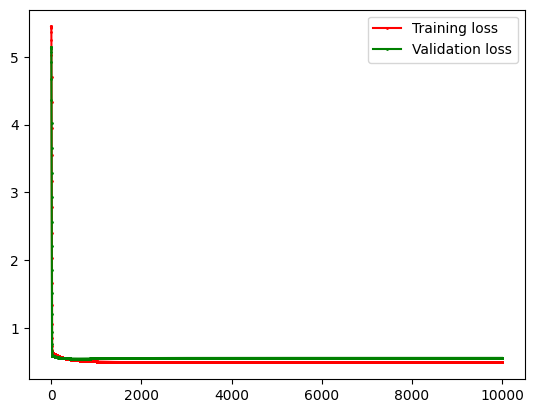


================ learning_rate = 0.5 ================
50. Training loss: 0.5795856019767915, Val loss:0.7272640503743908
100. Training loss: 0.5064787197487236, Val loss:0.6325716017212991
150. Training loss: 0.48987486327944557, Val loss:0.6210402970757338
200. Training loss: 0.481594716815417, Val loss:0.6207295834993596
250. Training loss: 0.47679440535803286, Val loss:0.6209183667824726
300. Training loss: 0.4738785819060857, Val loss:0.6210884995108071
350. Training loss: 0.47204762638384096, Val loss:0.6211764357270706
400. Training loss: 0.4708681393167029, Val loss:0.6211963440431345
450. Training loss: 0.4700923797380723, Val loss:0.6211738598688221
500. Training loss: 0.46957317497281104, Val loss:0.62112974337928
550. Training loss: 0.4692204548413396, Val loss:0.6210777064931096
600. Training loss: 0.46897773427743017, Val loss:0.6210257908154965
650. Training loss: 0.46880884242433574, Val loss:0.6209781809890129
700. Training loss: 0.468690188136172, Val loss:0.620936663

6200. Training loss: 0.4683869761024226, Val loss:0.6207639054064735
6250. Training loss: 0.4683869761024226, Val loss:0.6207639054064732
6300. Training loss: 0.4683869761024225, Val loss:0.620763905406473
6350. Training loss: 0.4683869761024225, Val loss:0.6207639054064729
6400. Training loss: 0.46838697610242247, Val loss:0.6207639054064727
6450. Training loss: 0.46838697610242236, Val loss:0.6207639054064726
6500. Training loss: 0.46838697610242236, Val loss:0.6207639054064725
6550. Training loss: 0.46838697610242236, Val loss:0.6207639054064725
6600. Training loss: 0.4683869761024223, Val loss:0.6207639054064724
6650. Training loss: 0.46838697610242247, Val loss:0.6207639054064724
6700. Training loss: 0.46838697610242236, Val loss:0.6207639054064725
6750. Training loss: 0.46838697610242247, Val loss:0.6207639054064725
6800. Training loss: 0.46838697610242247, Val loss:0.6207639054064725
6850. Training loss: 0.46838697610242236, Val loss:0.6207639054064725
6900. Training loss: 0.468

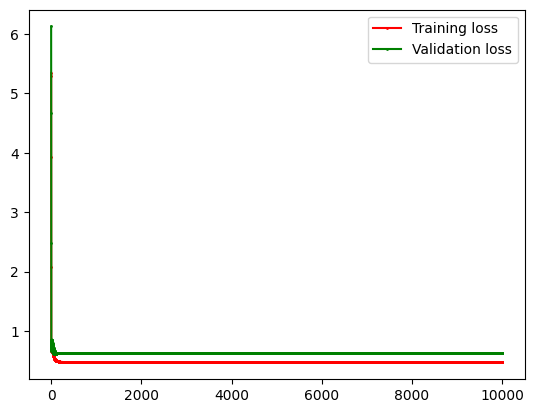

50. Training loss: 0.5772904951139104, Val loss:0.6222196059352166
100. Training loss: 0.5107867839937169, Val loss:0.5689329722108888
150. Training loss: 0.4924936140997435, Val loss:0.5617511027535468
200. Training loss: 0.4825418780017577, Val loss:0.5600952935744348
250. Training loss: 0.4765828810745643, Val loss:0.5598192758478506
300. Training loss: 0.47285234186502223, Val loss:0.559998039702877
350. Training loss: 0.470442671192052, Val loss:0.5602932985328388
400. Training loss: 0.4688492468294676, Val loss:0.5605815446721468
450. Training loss: 0.4677760369760046, Val loss:0.5608237266219067
500. Training loss: 0.46704243089565284, Val loss:0.5610137909149083
550. Training loss: 0.4665348536472474, Val loss:0.5611575270854028
600. Training loss: 0.46618012684210336, Val loss:0.5612638655585197
650. Training loss: 0.46593014229067087, Val loss:0.5613414805423715
700. Training loss: 0.4657527339496168, Val loss:0.5613976640710687
750. Training loss: 0.4656260848959853, Val los

6450. Training loss: 0.46529417217306185, Val loss:0.561543850625168
6500. Training loss: 0.4652941721730618, Val loss:0.561543850625168
6550. Training loss: 0.4652941721730618, Val loss:0.5615438506251681
6600. Training loss: 0.4652941721730618, Val loss:0.5615438506251681
6650. Training loss: 0.4652941721730618, Val loss:0.5615438506251681
6700. Training loss: 0.46529417217306196, Val loss:0.5615438506251681
6750. Training loss: 0.46529417217306185, Val loss:0.5615438506251682
6800. Training loss: 0.4652941721730618, Val loss:0.5615438506251683
6850. Training loss: 0.46529417217306174, Val loss:0.5615438506251683
6900. Training loss: 0.46529417217306174, Val loss:0.5615438506251683
6950. Training loss: 0.46529417217306174, Val loss:0.5615438506251682
7000. Training loss: 0.46529417217306174, Val loss:0.5615438506251682
7050. Training loss: 0.46529417217306174, Val loss:0.5615438506251682
7100. Training loss: 0.4652941721730617, Val loss:0.5615438506251682
7150. Training loss: 0.46529

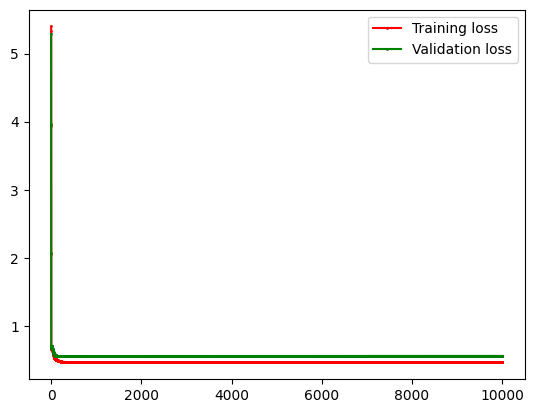

50. Training loss: 0.6149916421189685, Val loss:0.7346678244936394
100. Training loss: 0.5419354986612823, Val loss:0.6213061823785814
150. Training loss: 0.520745970416015, Val loss:0.5841222797478353
200. Training loss: 0.5124523418755486, Val loss:0.5773447091305546
250. Training loss: 0.5074993860958992, Val loss:0.5759879331149188
300. Training loss: 0.5043565929559323, Val loss:0.5756483440291357
350. Training loss: 0.502297356011354, Val loss:0.575658069615254
400. Training loss: 0.5009150923033147, Val loss:0.5757884627146723
450. Training loss: 0.499969658492054, Val loss:0.5759443583922589
500. Training loss: 0.49931330968212934, Val loss:0.5760885241827897
550. Training loss: 0.4988521652769909, Val loss:0.57620915552929
600. Training loss: 0.49852499303294184, Val loss:0.5763051361280344
650. Training loss: 0.49829099310032354, Val loss:0.5763793630368242
700. Training loss: 0.498122498560941, Val loss:0.5764358040652159
750. Training loss: 0.4980004744581561, Val loss:0.57

6850. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
6900. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
6950. Training loss: 0.4976622208919784, Val loss:0.5766033865480373
7000. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7050. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7100. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7150. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7200. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7250. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7300. Training loss: 0.4976622208919785, Val loss:0.5766033865480372
7350. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7400. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7450. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7500. Training loss: 0.4976622208919784, Val loss:0.5766033865480372
7550. Training loss: 0.49766222089

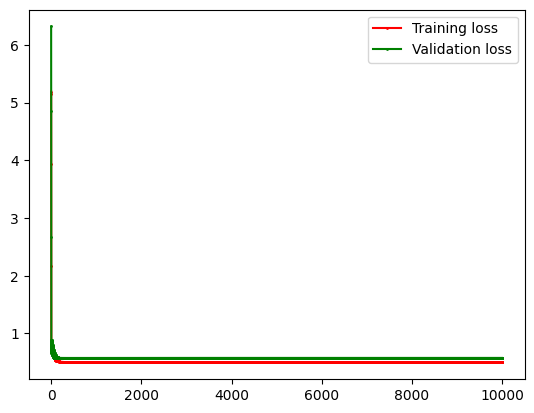

50. Training loss: 0.5690752554466223, Val loss:0.6596183658539629
100. Training loss: 0.5062658568235353, Val loss:0.5826888580890595
150. Training loss: 0.49211317144535355, Val loss:0.572065425177781
200. Training loss: 0.4847357744681936, Val loss:0.5680911655866973
250. Training loss: 0.48053063702703386, Val loss:0.5661300309362237
300. Training loss: 0.47801223292252093, Val loss:0.5651418214712098
350. Training loss: 0.4764504425863792, Val loss:0.5646440265093575
400. Training loss: 0.47545624867497943, Val loss:0.5643980751389062
450. Training loss: 0.4748102207289325, Val loss:0.5642821563918137
500. Training loss: 0.4743832874326426, Val loss:0.5642329137583254
550. Training loss: 0.47409707148358515, Val loss:0.564217105402155
600. Training loss: 0.47390277656976926, Val loss:0.564217289417799
650. Training loss: 0.4737694032651992, Val loss:0.5642244024311486
700. Training loss: 0.4736769230318175, Val loss:0.5642338427284789
750. Training loss: 0.4736122062286205, Val lo

6250. Training loss: 0.4734473194310494, Val loss:0.5642883297298898
6300. Training loss: 0.47344731943104934, Val loss:0.5642883297298897
6350. Training loss: 0.4734473194310492, Val loss:0.5642883297298897
6400. Training loss: 0.4734473194310492, Val loss:0.5642883297298896
6450. Training loss: 0.47344731943104906, Val loss:0.5642883297298897
6500. Training loss: 0.4734473194310492, Val loss:0.5642883297298895
6550. Training loss: 0.473447319431049, Val loss:0.5642883297298896
6600. Training loss: 0.473447319431049, Val loss:0.5642883297298894
6650. Training loss: 0.473447319431049, Val loss:0.5642883297298895
6700. Training loss: 0.47344731943104906, Val loss:0.5642883297298895
6750. Training loss: 0.473447319431049, Val loss:0.5642883297298894
6800. Training loss: 0.473447319431049, Val loss:0.5642883297298896
6850. Training loss: 0.473447319431049, Val loss:0.5642883297298894
6900. Training loss: 0.473447319431049, Val loss:0.5642883297298894
6950. Training loss: 0.473447319431049

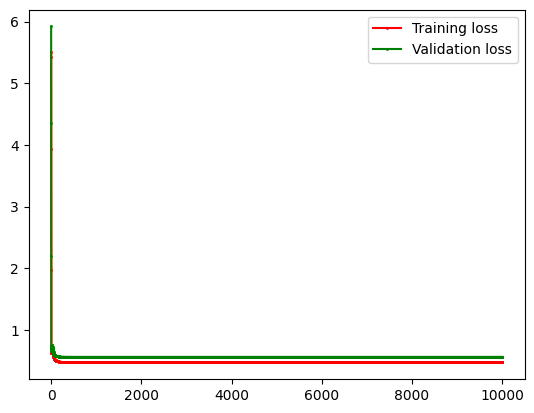

50. Training loss: 0.6065034367438142, Val loss:0.5830175231683883
100. Training loss: 0.5314385026572368, Val loss:0.5455453179717719
150. Training loss: 0.5127167707549989, Val loss:0.5473831667084339
200. Training loss: 0.504518917061322, Val loss:0.549714720161921
250. Training loss: 0.4996281400760042, Val loss:0.5516241955056475
300. Training loss: 0.4965660033144979, Val loss:0.5531711314370698
350. Training loss: 0.4945843395353914, Val loss:0.5543708370807658
400. Training loss: 0.49326946455957466, Val loss:0.5552809120336998
450. Training loss: 0.49237982036044275, Val loss:0.5559632583334935
500. Training loss: 0.4917684250770025, Val loss:0.5564716665429181
550. Training loss: 0.49134289750177274, Val loss:0.556849280210851
600. Training loss: 0.4910436325869269, Val loss:0.557129391332942
650. Training loss: 0.4908313354074859, Val loss:0.5573371593145096
700. Training loss: 0.4906796330219209, Val loss:0.5574913740659525
750. Training loss: 0.49057055840921926, Val loss:

6900. Training loss: 0.49027558136284016, Val loss:0.5579464790630186
6950. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7000. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7050. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7100. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7150. Training loss: 0.49027558136284016, Val loss:0.5579464790630186
7200. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7250. Training loss: 0.49027558136284016, Val loss:0.5579464790630186
7300. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7350. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7400. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7450. Training loss: 0.4902755813628401, Val loss:0.5579464790630186
7500. Training loss: 0.49027558136284016, Val loss:0.5579464790630186
7550. Training loss: 0.49027558136284016, Val loss:0.5579464790630186
7600. Training loss: 0.490275

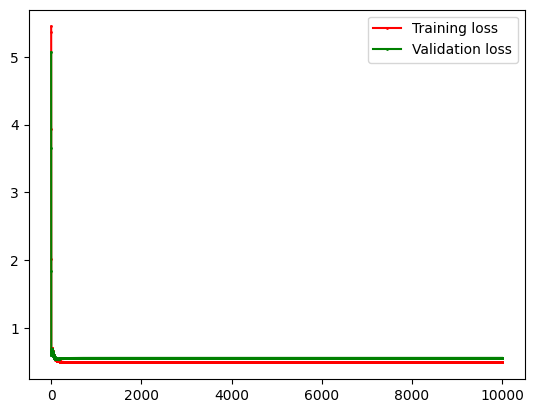


================ reg_lambda = 2.0 ================

================ learning_rate = 0.005 ================
50. Training loss: 5.345292180193646, Val loss:6.167643284831131
100. Training loss: 5.29164085795469, Val loss:6.1232188464590775
150. Training loss: 4.805338662958893, Val loss:5.628745917335393
200. Training loss: 3.904791138889112, Val loss:4.617586012014066
250. Training loss: 2.9670508912747864, Val loss:3.516112450880839
300. Training loss: 2.049746955630011, Val loss:2.437643373356539
350. Training loss: 1.23718310172023, Val loss:1.4765980983071691
400. Training loss: 0.7665485975089997, Val loss:0.9000203545020936
450. Training loss: 0.6441491899819398, Val loss:0.7257459928218388
500. Training loss: 0.6255542390969768, Val loss:0.6874036587685828
550. Training loss: 0.6221550978304308, Val loss:0.6774537632242633
600. Training loss: 0.6205635874164939, Val loss:0.6739966590457609
650. Training loss: 0.6191911379594127, Val loss:0.6723449926121857
700. Training loss: 0

6650. Training loss: 0.5399119735204931, Val loss:0.6294727789178408
6700. Training loss: 0.539619349593609, Val loss:0.6293535158840559
6750. Training loss: 0.539329847032189, Val loss:0.6292359712868368
6800. Training loss: 0.5390434261445309, Val loss:0.629120117868378
6850. Training loss: 0.5387600478461724, Val loss:0.6290059288412702
6900. Training loss: 0.5384796736488932, Val loss:0.6288933778796615
6950. Training loss: 0.5382022656499473, Val loss:0.6287824391105981
7000. Training loss: 0.537927786521518, Val loss:0.6286730871055426
7050. Training loss: 0.5376561995003912, Val loss:0.6285652968720657
7100. Training loss: 0.5373874683778425, Val loss:0.6284590438457048
7150. Training loss: 0.5371215574897322, Val loss:0.6283543038819902
7200. Training loss: 0.5368584317068048, Val loss:0.628251053248632
7250. Training loss: 0.5365980564251857, Val loss:0.6281492686178662
7300. Training loss: 0.5363403975570744, Val loss:0.6280489270589535
7350. Training loss: 0.5360854215216265

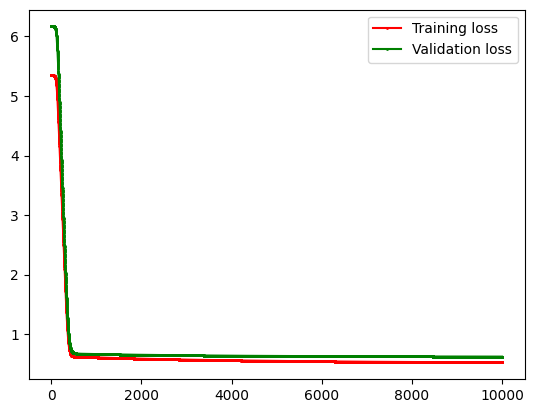

50. Training loss: 5.394578453302622, Val loss:5.345292180193648
100. Training loss: 5.32227207168348, Val loss:5.279108828517443
150. Training loss: 4.816845109894539, Val loss:4.8231114066024885
200. Training loss: 3.909191267489656, Val loss:3.9209003749645577
250. Training loss: 2.962368304087215, Val loss:2.9668485495990544
300. Training loss: 2.038005311392469, Val loss:2.0357818478149166
350. Training loss: 1.2275733337010735, Val loss:1.2227691265277691
400. Training loss: 0.7705953943812304, Val loss:0.7727140470074291
450. Training loss: 0.6540076883108309, Val loss:0.6624005806292576
500. Training loss: 0.6360061428659278, Val loss:0.6467886452746077
550. Training loss: 0.6325523497026343, Val loss:0.6443352296263237
600. Training loss: 0.6308729978882229, Val loss:0.6432423214275376
650. Training loss: 0.6294162291128534, Val loss:0.6422407213458874
700. Training loss: 0.6280033998488527, Val loss:0.6412377153014969
750. Training loss: 0.6266142240199379, Val loss:0.6402403

6700. Training loss: 0.5445075803633007, Val loss:0.5856568327353278
6750. Training loss: 0.5441903625787093, Val loss:0.5854858000967426
6800. Training loss: 0.5438763726666328, Val loss:0.5853171031766522
6850. Training loss: 0.5435655705760902, Val loss:0.585150708337703
6900. Training loss: 0.5432579168684205, Val loss:0.5849865824710333
6950. Training loss: 0.5429533727059414, Val loss:0.5848246929871003
7000. Training loss: 0.5426518998408557, Val loss:0.5846650078066824
7050. Training loss: 0.5423534606043984, Val loss:0.5845074953520543
7100. Training loss: 0.542058017896219, Val loss:0.5843521245383305
7150. Training loss: 0.5417655351739927, Val loss:0.5841988647649732
7200. Training loss: 0.5414759764432547, Val loss:0.5840476859074643
7250. Training loss: 0.5411893062474542, Val loss:0.5838985583091317
7300. Training loss: 0.540905489658218, Val loss:0.583751452773134
7350. Training loss: 0.5406244922658253, Val loss:0.5836063405545949
7400. Training loss: 0.540346280169881

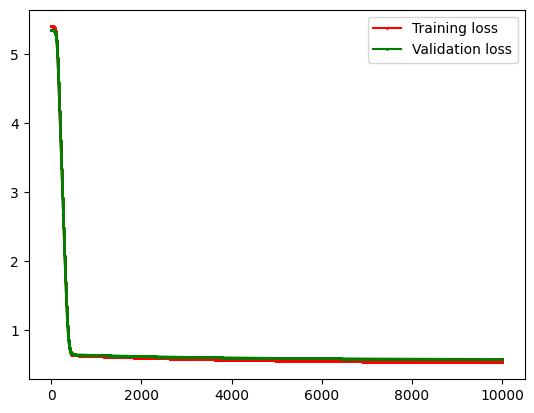

50. Training loss: 5.1892002397519255, Val loss:6.373231060990504
100. Training loss: 5.140230508354251, Val loss:6.312594337420153
150. Training loss: 4.747920476952625, Val loss:5.794083173950112
200. Training loss: 3.912647230186603, Val loss:4.801163389092778
250. Training loss: 3.01664038160643, Val loss:3.6952927707926695
300. Training loss: 2.136904335716943, Val loss:2.609079090876063
350. Training loss: 1.33681802673882, Val loss:1.6180100122473344
400. Training loss: 0.8240895063825527, Val loss:0.9654639306980515
450. Training loss: 0.6699624966308646, Val loss:0.7395157103969218
500. Training loss: 0.6451861050951894, Val loss:0.6860524566544922
550. Training loss: 0.6410781160064687, Val loss:0.671968830287726
600. Training loss: 0.6394754727414771, Val loss:0.6671838236040502
650. Training loss: 0.6381697249404924, Val loss:0.6650114657585738
700. Training loss: 0.6369133419243467, Val loss:0.6636606848304368
750. Training loss: 0.6356793716081656, Val loss:0.662586316828

6300. Training loss: 0.566114065413877, Val loss:0.610514394598983
6350. Training loss: 0.5658170001265433, Val loss:0.6103095812890328
6400. Training loss: 0.5655230579360448, Val loss:0.6101072879129544
6450. Training loss: 0.5652321984352072, Val loss:0.6099074811934188
6500. Training loss: 0.5649443818630288, Val loss:0.609710128356481
6550. Training loss: 0.5646595690921296, Val loss:0.6095151971224123
6600. Training loss: 0.5643777216164872, Val loss:0.6093226556967323
6650. Training loss: 0.5640988015394527, Val loss:0.6091324727614428
6700. Training loss: 0.5638227715620389, Val loss:0.60894461746645
6750. Training loss: 0.5635495949714749, Val loss:0.6087590594211777
6800. Training loss: 0.5632792356300191, Val loss:0.6085757686863627
6850. Training loss: 0.5630116579640229, Val loss:0.6083947157660258
6900. Training loss: 0.5627468269532422, Val loss:0.6082158715996199
6950. Training loss: 0.562484708120386, Val loss:0.608039207554345
7000. Training loss: 0.5622252675209, Val

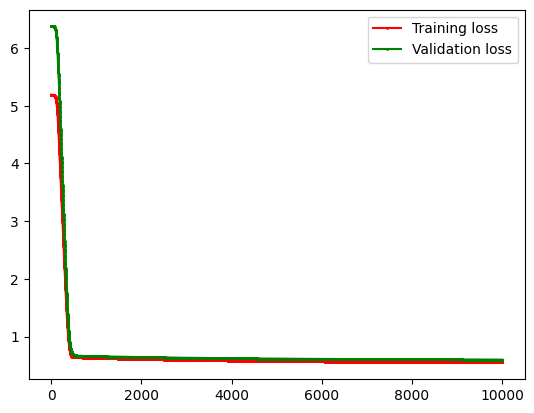

50. Training loss: 5.497180944255738, Val loss:5.962055508671761
100. Training loss: 5.418670273847794, Val loss:5.915542023779646
150. Training loss: 4.869368176944457, Val loss:5.343022735654656
200. Training loss: 3.907264273989806, Val loss:4.304304345799548
250. Training loss: 2.919118219743002, Val loss:3.2149346448304024
300. Training loss: 1.9583508739122486, Val loss:2.1557335773831987
350. Training loss: 1.1416768701278066, Val loss:1.255766863306045
400. Training loss: 0.7295648713501613, Val loss:0.7964317157465721
450. Training loss: 0.6387015450391945, Val loss:0.6852273686443853
500. Training loss: 0.625410558432676, Val loss:0.6643084470425423
550. Training loss: 0.6225147396895292, Val loss:0.6590150246669689
600. Training loss: 0.6208346478536101, Val loss:0.6568147405150873
650. Training loss: 0.6193124510090928, Val loss:0.6554084950935248
700. Training loss: 0.6178307296480536, Val loss:0.6542513514367524
750. Training loss: 0.616376331674814, Val loss:0.6531862988

6850. Training loss: 0.5365200952782062, Val loss:0.5970060517997569
6900. Training loss: 0.5362547121147759, Val loss:0.5968228760658169
6950. Training loss: 0.5359922961322638, Val loss:0.5966418160316952
7000. Training loss: 0.5357328072510471, Val loss:0.5964628430193447
7050. Training loss: 0.5354762060550865, Val loss:0.5962859288218151
7100. Training loss: 0.5352224537786052, Val loss:0.5961110456938552
7150. Training loss: 0.5349715122930843, Val loss:0.5959381663427364
7200. Training loss: 0.5347233440945621, Val loss:0.5957672639192911
7250. Training loss: 0.5344779122912334, Val loss:0.5955983120091614
7300. Training loss: 0.5342351805913376, Val loss:0.595431284624251
7350. Training loss: 0.533995113291329, Val loss:0.5952661561943776
7400. Training loss: 0.5337576752643229, Val loss:0.5951029015591159
7450. Training loss: 0.5335228319488083, Val loss:0.5949414959598318
7500. Training loss: 0.5332905493376215, Val loss:0.5947819150318979
7550. Training loss: 0.5330607939671

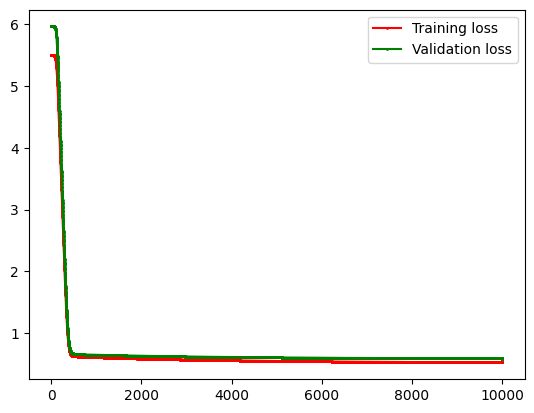

50. Training loss: 5.445896531018412, Val loss:5.139704404034276
100. Training loss: 5.370099619542005, Val loss:5.061446625027612
150. Training loss: 4.852879647745922, Val loss:4.489172481491557
200. Training loss: 3.9126544345385574, Val loss:3.612030612338095
250. Training loss: 2.9397103256822277, Val loss:2.6942324466416108
300. Training loss: 1.9923413271065917, Val loss:1.8022151534474264
350. Training loss: 1.1779926880300875, Val loss:1.045417633605542
400. Training loss: 0.7507364007038545, Val loss:0.6699034560151933
450. Training loss: 0.6520145909055383, Val loss:0.5969264952465093
500. Training loss: 0.6375855315328958, Val loss:0.5916455824709919
550. Training loss: 0.634789256614118, Val loss:0.5922080474143291
600. Training loss: 0.6333617999673289, Val loss:0.5922567317037074
650. Training loss: 0.632102879876373, Val loss:0.5918539476970309
700. Training loss: 0.6308782988607273, Val loss:0.5912777822083308
750. Training loss: 0.6296732223190122, Val loss:0.59064934

7050. Training loss: 0.5559376936986654, Val loss:0.5606376116128264
7100. Training loss: 0.5556800841441605, Val loss:0.5605912412126949
7150. Training loss: 0.5554250963889503, Val loss:0.5605460302576856
7200. Training loss: 0.5551726983953871, Val loss:0.5605019579207013
7250. Training loss: 0.5549228585982428, Val loss:0.5604590037472941
7300. Training loss: 0.5546755458964338, Val loss:0.5604171476484853
7350. Training loss: 0.5544307296449136, Val loss:0.5603763698937375
7400. Training loss: 0.5541883796467274, Val loss:0.5603366511040748
7450. Training loss: 0.5539484661452299, Val loss:0.5602979722453468
7500. Training loss: 0.5537109598164556, Val loss:0.5602603146216371
7550. Training loss: 0.5534758317616457, Val loss:0.5602236598688066
7600. Training loss: 0.5532430534999218, Val loss:0.5601879899481749
7650. Training loss: 0.5530125969611065, Val loss:0.5601532871403314
7700. Training loss: 0.5527844344786876, Val loss:0.5601195340390775
7750. Training loss: 0.55255853878

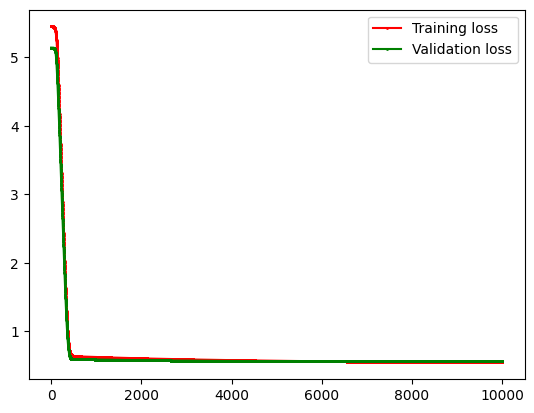


================ learning_rate = 0.01 ================
50. Training loss: 5.294680360059602, Val loss:6.123207003605377
100. Training loss: 3.923454797817583, Val loss:4.6173834360839905
150. Training loss: 2.067155785726173, Val loss:2.437110517006954
200. Training loss: 0.7699369021037221, Val loss:0.8977175587704337
250. Training loss: 0.6255457886803636, Val loss:0.6869627477068979
300. Training loss: 0.6205853933476851, Val loss:0.6739287847958567
350. Training loss: 0.6178826167969349, Val loss:0.6712502029633668
400. Training loss: 0.6152831631524318, Val loss:0.6695542187313548
450. Training loss: 0.6127604378502696, Val loss:0.6680109882656851
500. Training loss: 0.6103116034316718, Val loss:0.666531218578232
550. Training loss: 0.6079340356242976, Val loss:0.6651034931029569
600. Training loss: 0.605625201069607, Val loss:0.663724866137116
650. Training loss: 0.6033826682665214, Val loss:0.6623933794189953
700. Training loss: 0.601204105063993, Val loss:0.661107248747032
750

7250. Training loss: 0.5165373975236924, Val loss:0.6217082807821802
7300. Training loss: 0.5164058812544584, Val loss:0.6216770467452617
7350. Training loss: 0.516276603743376, Val loss:0.6216465070716072
7400. Training loss: 0.5161495228673321, Val loss:0.6216166436599254
7450. Training loss: 0.5160245973981635, Val loss:0.621587438920473
7500. Training loss: 0.5159017869807774, Val loss:0.6215588757596706
7550. Training loss: 0.5157810521118878, Val loss:0.6215309375652124
7600. Training loss: 0.5156623541193545, Val loss:0.621503608191649
7650. Training loss: 0.5155456551420989, Val loss:0.6214768719464338
7700. Training loss: 0.515430918110583, Val loss:0.6214507135764106
7750. Training loss: 0.5153181067278302, Val loss:0.6214251182547327
7800. Training loss: 0.515207185450973, Val loss:0.6214000715681944
7850. Training loss: 0.5150981194733093, Val loss:0.6213755595049649
7900. Training loss: 0.5149908747068519, Val loss:0.6213515684427086
7950. Training loss: 0.5148854177653558

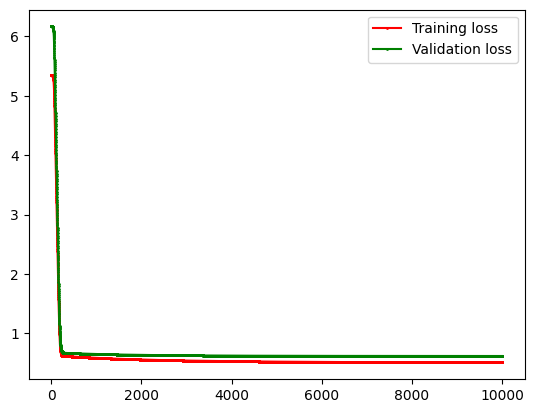

50. Training loss: 5.3259286107850325, Val loss:5.279093805838068
100. Training loss: 3.928039738967189, Val loss:3.9207242384599974
150. Training loss: 2.055479150355396, Val loss:2.0353004460113526
200. Training loss: 0.7737605057005352, Val loss:0.7710240725678329
250. Training loss: 0.6359992923475881, Val loss:0.6466849322285073
300. Training loss: 0.6308962932824793, Val loss:0.6432413988382092
350. Training loss: 0.6280273830075244, Val loss:0.6412355891398825
400. Training loss: 0.6252692414754517, Val loss:0.6392521192743337
450. Training loss: 0.6225935837004152, Val loss:0.6373248970422392
500. Training loss: 0.619997147067418, Val loss:0.6354577610232122
550. Training loss: 0.6174769528076401, Val loss:0.6336492364274846
600. Training loss: 0.6150301403933119, Val loss:0.6318973443771289
650. Training loss: 0.6126539754848979, Val loss:0.6302001242699183
700. Training loss: 0.6103458456986847, Val loss:0.6285556850795361
750. Training loss: 0.6081032548722793, Val loss:0.62

6950. Training loss: 0.5194480874773365, Val loss:0.5747274530161441
7000. Training loss: 0.5192760795124854, Val loss:0.5746784363212256
7050. Training loss: 0.5191068564780797, Val loss:0.5746307367631899
7100. Training loss: 0.5189403676210992, Val loss:0.5745843208418661
7150. Training loss: 0.5187765632549444, Val loss:0.5745391559265247
7200. Training loss: 0.5186153947331598, Val loss:0.574495210231891
7250. Training loss: 0.5184568144239143, Val loss:0.5744524527948791
7300. Training loss: 0.5183007756852177, Val loss:0.5744108534520189
7350. Training loss: 0.5181472328408463, Val loss:0.5743703828175557
7400. Training loss: 0.5179961411569552, Val loss:0.5743310122622001
7450. Training loss: 0.5178474568193547, Val loss:0.574292713892507
7500. Training loss: 0.517701136911428, Val loss:0.5742554605308638
7550. Training loss: 0.5175571393926716, Val loss:0.5742192256960665
7600. Training loss: 0.517415423077834, Val loss:0.5741839835844683
7650. Training loss: 0.517275947616639

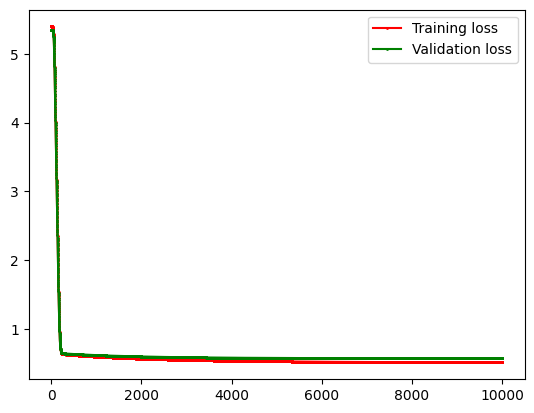

50. Training loss: 5.14322156607313, Val loss:6.312576749612158
100. Training loss: 3.930474500700684, Val loss:4.800960796174855
150. Training loss: 2.1537377363500516, Val loss:2.608594960249044
200. Training loss: 0.8285010310171143, Val loss:0.9630916086265625
250. Training loss: 0.6451764995092251, Val loss:0.6854658096537467
300. Training loss: 0.6394954947234213, Val loss:0.6670889567022681
350. Training loss: 0.6369345884307295, Val loss:0.6636441072481869
400. Training loss: 0.6344851727384034, Val loss:0.6616084494464093
450. Training loss: 0.632111153733839, Val loss:0.6597728962468837
500. Training loss: 0.6298094625236427, Val loss:0.6580085475674882
550. Training loss: 0.627577296442808, Val loss:0.6562996970141282
600. Training loss: 0.6254119600132645, Val loss:0.6546428633543723
650. Training loss: 0.6233108806644702, Val loss:0.6530359640254623
700. Training loss: 0.62127160508069, Val loss:0.6514771453876059
750. Training loss: 0.6192917933212916, Val loss:0.64996465

6650. Training loss: 0.5432896224443264, Val loss:0.5966262770278679
6700. Training loss: 0.5431276537121333, Val loss:0.596550804359202
6750. Training loss: 0.5429683427107685, Val loss:0.5964771297204138
6800. Training loss: 0.5428116395381849, Val loss:0.5964052116671855
6850. Training loss: 0.5426574953836028, Val loss:0.596335009730096
6900. Training loss: 0.5425058624995265, Val loss:0.5962664843902361
6950. Training loss: 0.5423566941745991, Val loss:0.5961995970554995
7000. Training loss: 0.5422099447072631, Val loss:0.5961343100375245
7050. Training loss: 0.542065569380204, Val loss:0.5960705865292685
7100. Training loss: 0.5419235244355453, Val loss:0.596008390583196
7150. Training loss: 0.5417837670507729, Val loss:0.5959476870900579
7200. Training loss: 0.5416462553153638, Val loss:0.5958884417582475
7250. Training loss: 0.5415109482080931, Val loss:0.5958306210937125
7300. Training loss: 0.541377805574999, Val loss:0.5957741923804086
7350. Training loss: 0.5412467881079838

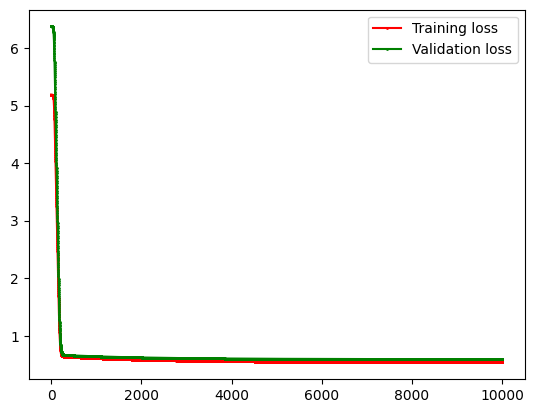

50. Training loss: 5.423125106430372, Val loss:5.915523015186301
100. Training loss: 3.9269416024527053, Val loss:4.304102618587511
150. Training loss: 1.9763410913942514, Val loss:2.155129004026483
200. Training loss: 0.7319015685085911, Val loss:0.7944935163466225
250. Training loss: 0.6254079409715768, Val loss:0.6640761350558153
300. Training loss: 0.6208591164695431, Val loss:0.6567826574787127
350. Training loss: 0.617855160875701, Val loss:0.6542438918629347
400. Training loss: 0.6149707117638786, Val loss:0.6521596443498197
450. Training loss: 0.6121856866985645, Val loss:0.6501857504556635
500. Training loss: 0.6094956920182485, Val loss:0.6482836152831715
550. Training loss: 0.606896628077597, Val loss:0.6464464748340902
600. Training loss: 0.6043845941868747, Val loss:0.6446711410421392
650. Training loss: 0.6019558864610762, Val loss:0.642954940935865
700. Training loss: 0.5996069881355343, Val loss:0.6412953763166535
750. Training loss: 0.5973345593690806, Val loss:0.63969

7250. Training loss: 0.5160421115474414, Val loss:0.5832623108071476
7300. Training loss: 0.515924913426773, Val loss:0.5831883070651785
7350. Training loss: 0.5158097697978568, Val loss:0.5831157112516397
7400. Training loss: 0.5156966405263407, Val loss:0.5830444945317768
7450. Training loss: 0.5155854863669591, Val loss:0.5829746287179539
7500. Training loss: 0.5154762689408895, Val loss:0.5829060862533364
7550. Training loss: 0.5153689507137756, Val loss:0.5828388401960447
7600. Training loss: 0.5152634949743969, Val loss:0.5827728642037678
7650. Training loss: 0.5151598658139603, Val loss:0.5827081325188193
7700. Training loss: 0.5150580281059927, Val loss:0.5826446199536182
7750. Training loss: 0.5149579474868176, Val loss:0.5825823018765862
7800. Training loss: 0.514859590336592, Val loss:0.5825211541984432
7850. Training loss: 0.5147629237608885, Val loss:0.582461153358888
7900. Training loss: 0.5146679155728012, Val loss:0.5824022763136556
7950. Training loss: 0.51457453427556

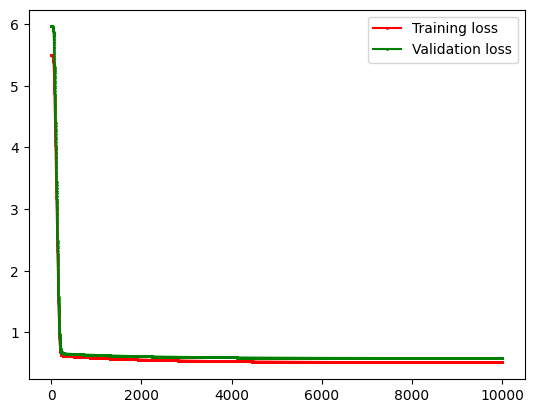

50. Training loss: 5.374422466097291, Val loss:5.061422003371076
100. Training loss: 3.932026926182632, Val loss:3.6118607744440854
150. Training loss: 2.0101416934001715, Val loss:1.8017241772376178
200. Training loss: 0.7533329726038082, Val loss:0.6685157555302286
250. Training loss: 0.6375768839179903, Val loss:0.5916682200275583
300. Training loss: 0.633381778402198, Val loss:0.59227505689427
350. Training loss: 0.6308987571029672, Val loss:0.5912772456926862
400. Training loss: 0.6285055250427002, Val loss:0.5900080287989323
450. Training loss: 0.626181520224432, Val loss:0.5887537812321997
500. Training loss: 0.6239242026946049, Val loss:0.5875451245664058
550. Training loss: 0.6217312200160984, Val loss:0.5863835766666315
600. Training loss: 0.6196003051369839, Val loss:0.5852675829659594
650. Training loss: 0.6175292830335992, Val loss:0.5841953332765681
700. Training loss: 0.6155160679642938, Val loss:0.5831650620147854
750. Training loss: 0.6135586596143165, Val loss:0.58217

7250. Training loss: 0.5352985866935556, Val loss:0.5599085486825078
7300. Training loss: 0.5351656709235196, Val loss:0.5599320114712227
7350. Training loss: 0.535034912877796, Val loss:0.5599556396476387
7400. Training loss: 0.5349062730873977, Val loss:0.5599794206518327
7450. Training loss: 0.5347797129094468, Val loss:0.5600033423573186
7500. Training loss: 0.5346551945071842, Val loss:0.5600273930574173
7550. Training loss: 0.5345326808305384, Val loss:0.5600515614520644
7600. Training loss: 0.5344121355972369, Val loss:0.5600758366350459
7650. Training loss: 0.5342935232744412, Val loss:0.5601002080816463
7700. Training loss: 0.5341768090608899, Val loss:0.5601246656366928
7750. Training loss: 0.5340619588695342, Val loss:0.5601491995029835
7800. Training loss: 0.5339489393106479, Val loss:0.5601738002300861
7850. Training loss: 0.5338377176754003, Val loss:0.5601984587034952
7900. Training loss: 0.533728261919875, Val loss:0.5602231661341336
7950. Training loss: 0.5336205406495

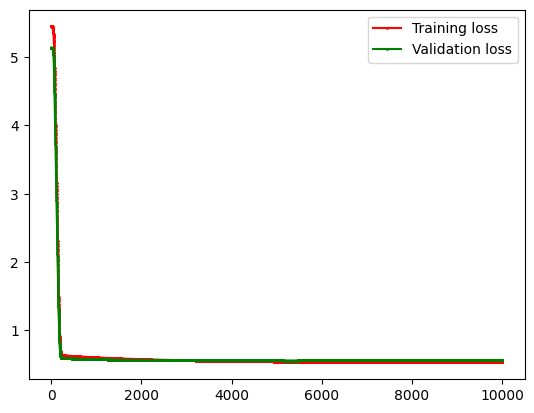


================ learning_rate = 0.1 ================
50. Training loss: 0.6106704072584968, Val loss:0.6664968963416361
100. Training loss: 0.5895966680284742, Val loss:0.6542120539331405
150. Training loss: 0.5736301905212592, Val loss:0.6454581036769085
200. Training loss: 0.5613241546389105, Val loss:0.6391469714420701
250. Training loss: 0.5516973859273645, Val loss:0.6345475553307219
300. Training loss: 0.544069886436833, Val loss:0.6311619413804451
350. Training loss: 0.5379601089038383, Val loss:0.6286464968935868
400. Training loss: 0.5330200547516856, Val loss:0.626761094714731
450. Training loss: 0.5289935283011349, Val loss:0.6253360095685176
500. Training loss: 0.5256887359386473, Val loss:0.6242500267421943
550. Training loss: 0.5229599279336032, Val loss:0.6234157599381703
600. Training loss: 0.5206948526098438, Val loss:0.6227696716496859
650. Training loss: 0.5188060209705714, Val loss:0.6222652052320824
700. Training loss: 0.5172245175488058, Val loss:0.6218680043190

7150. Training loss: 0.5081376421837728, Val loss:0.6198105782154855
7200. Training loss: 0.508137641934586, Val loss:0.6198105775812078
7250. Training loss: 0.5081376417107792, Val loss:0.6198105770071913
7300. Training loss: 0.508137641509767, Val loss:0.6198105764877132
7350. Training loss: 0.5081376413292276, Val loss:0.6198105760175936
7400. Training loss: 0.5081376411670757, Val loss:0.6198105755921431
7450. Training loss: 0.5081376410214388, Val loss:0.6198105752071186
7500. Training loss: 0.5081376408906352, Val loss:0.6198105748586781
7550. Training loss: 0.5081376407731547, Val loss:0.6198105745433453
7600. Training loss: 0.5081376406676409, Val loss:0.6198105742579736
7650. Training loss: 0.5081376405728752, Val loss:0.6198105739997156
7700. Training loss: 0.5081376404877639, Val loss:0.6198105737659938
7750. Training loss: 0.5081376404113239, Val loss:0.6198105735544761
7800. Training loss: 0.5081376403426728, Val loss:0.6198105733630515
7850. Training loss: 0.5081376402810

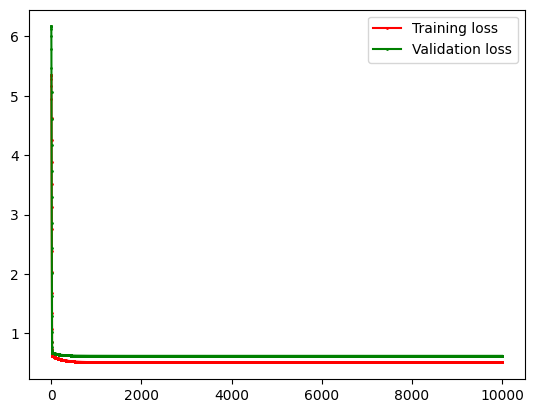

50. Training loss: 0.6203795421038871, Val loss:0.635401451900398
100. Training loss: 0.5980501980187978, Val loss:0.6196351818572935
150. Training loss: 0.5811028666651618, Val loss:0.608063203435251
200. Training loss: 0.5679754525439085, Val loss:0.5994880802734462
250. Training loss: 0.5576334471476704, Val loss:0.5930817510036245
300. Training loss: 0.5493707376871089, Val loss:0.5882629011820936
350. Training loss: 0.5426915813074498, Val loss:0.5846177095850962
400. Training loss: 0.5372390988346838, Val loss:0.5818478668125364
450. Training loss: 0.5327506953129119, Val loss:0.5797358991755611
500. Training loss: 0.5290294394512898, Val loss:0.5781216550000768
550. Training loss: 0.5259251741374289, Val loss:0.576886119821576
600. Training loss: 0.5233217331789879, Val loss:0.5759401247471695
650. Training loss: 0.5211280941795946, Val loss:0.5752163715373225
700. Training loss: 0.519272131419449, Val loss:0.5746637365269001
750. Training loss: 0.5176961242287171, Val loss:0.57

7200. Training loss: 0.507762302720646, Val loss:0.5733226090342782
7250. Training loss: 0.5077623023935339, Val loss:0.5733226092234671
7300. Training loss: 0.5077623021008745, Val loss:0.5733226093967261
7350. Training loss: 0.5077623018390519, Val loss:0.5733226095554113
7400. Training loss: 0.5077623016048289, Val loss:0.5733226097007618
7450. Training loss: 0.5077623013953076, Val loss:0.573322609833909
7500. Training loss: 0.5077623012078936, Val loss:0.5733226099558871
7550. Training loss: 0.5077623010402641, Val loss:0.5733226100676408
7600. Training loss: 0.5077623008903397, Val loss:0.573322610170034
7650. Training loss: 0.5077623007562592, Val loss:0.5733226102638568
7700. Training loss: 0.5077623006363561, Val loss:0.5733226103498309
7750. Training loss: 0.5077623005291388, Val loss:0.5733226104286171
7800. Training loss: 0.5077623004332724, Val loss:0.5733226105008199
7850. Training loss: 0.5077623003475614, Val loss:0.573322610566992
7900. Training loss: 0.507762300270936

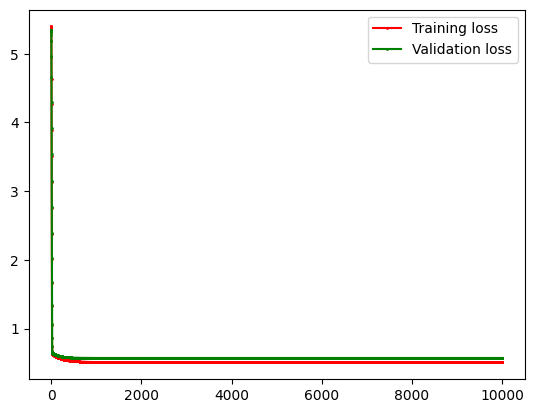

50. Training loss: 0.6301473771819344, Val loss:0.6579635353160624
100. Training loss: 0.6104354180885899, Val loss:0.6429879329818217
150. Training loss: 0.5955785635518929, Val loss:0.6317987553137916
200. Training loss: 0.584134559735403, Val loss:0.6233086081295209
250. Training loss: 0.575159785095846, Val loss:0.6167919344764722
300. Training loss: 0.5680164827371355, Val loss:0.6117474637437645
350. Training loss: 0.5622604966391703, Val loss:0.6078184224282851
400. Training loss: 0.5575741785906757, Val loss:0.6047446057755437
450. Training loss: 0.5537250636267318, Val loss:0.6023324942793102
500. Training loss: 0.550539621847051, Val loss:0.6004359246151686
550. Training loss: 0.5478860891022775, Val loss:0.5989431532167175
600. Training loss: 0.5456629287087721, Val loss:0.5977679312371932
650. Training loss: 0.5437908867277857, Val loss:0.5968431839329555
700. Training loss: 0.542207402272933, Val loss:0.5961164350382739
750. Training loss: 0.5408625989371757, Val loss:0.59

7250. Training loss: 0.5322540173516687, Val loss:0.593874353841936
7300. Training loss: 0.5322540168809874, Val loss:0.5938743538305228
7350. Training loss: 0.5322540164560181, Val loss:0.5938743538181065
7400. Training loss: 0.5322540160722976, Val loss:0.5938743538049742
7450. Training loss: 0.532254015725801, Val loss:0.5938743537913683
7500. Training loss: 0.5322540154128982, Val loss:0.5938743537774914
7550. Training loss: 0.532254015130315, Val loss:0.5938743537635116
7600. Training loss: 0.5322540148750982, Val loss:0.5938743537495688
7650. Training loss: 0.5322540146445837, Val loss:0.5938743537357762
7700. Training loss: 0.5322540144363683, Val loss:0.5938743537222262
7750. Training loss: 0.5322540142482838, Val loss:0.5938743537089922
7800. Training loss: 0.5322540140783738, Val loss:0.5938743536961316
7850. Training loss: 0.5322540139248731, Val loss:0.5938743536836888
7900. Training loss: 0.5322540137861893, Val loss:0.5938743536716957
7950. Training loss: 0.53225401366088

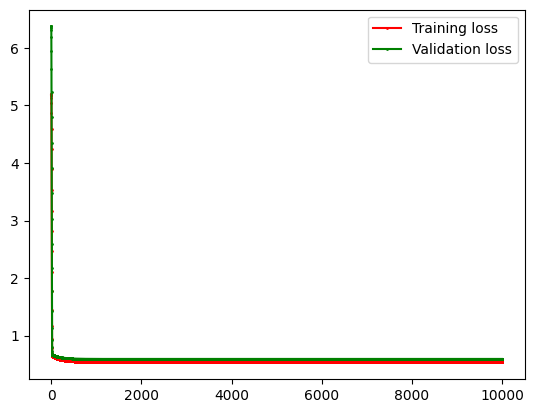

50. Training loss: 0.609876984355575, Val loss:0.6482217882396958
100. Training loss: 0.5872536737689644, Val loss:0.6323366043402733
150. Training loss: 0.5707481508171008, Val loss:0.6207630562150337
200. Training loss: 0.5583876022297032, Val loss:0.6121171918912716
250. Training loss: 0.5489314509638017, Val loss:0.6055270760803617
300. Training loss: 0.5415705394095754, Val loss:0.6004222678492882
350. Training loss: 0.5357587536665137, Val loss:0.5964164742405803
400. Training loss: 0.5311161055153665, Val loss:0.5932400084949526
450. Training loss: 0.5273710832429739, Val loss:0.5906995561084297
500. Training loss: 0.5243252004745329, Val loss:0.5886533860995818
550. Training loss: 0.5218304907585269, Val loss:0.5869955820922756
600. Training loss: 0.5197747913740193, Val loss:0.5856457077123945
650. Training loss: 0.5180718563874707, Val loss:0.5845418449869655
700. Training loss: 0.5166545495044299, Val loss:0.5836357860611664
750. Training loss: 0.5154700532613588, Val loss:0

7250. Training loss: 0.5087239485465396, Val loss:0.5791097513750257
7300. Training loss: 0.5087239484009336, Val loss:0.5791097512576188
7350. Training loss: 0.508723948269649, Val loss:0.5791097511504688
7400. Training loss: 0.5087239481512643, Val loss:0.5791097510526696
7450. Training loss: 0.5087239480445008, Val loss:0.5791097509633969
7500. Training loss: 0.5087239479482076, Val loss:0.5791097508818991
7550. Training loss: 0.5087239478613487, Val loss:0.5791097508074924
7600. Training loss: 0.5087239477829919, Val loss:0.5791097507395538
7650. Training loss: 0.5087239477122975, Val loss:0.5791097506775155
7700. Training loss: 0.50872394764851, Val loss:0.5791097506208602
7750. Training loss: 0.5087239475909489, Val loss:0.5791097505691166
7800. Training loss: 0.5087239475390011, Val loss:0.5791097505218546
7850. Training loss: 0.5087239474921148, Val loss:0.5791097504786834
7900. Training loss: 0.5087239474497927, Val loss:0.5791097504392452
7950. Training loss: 0.50872394741158

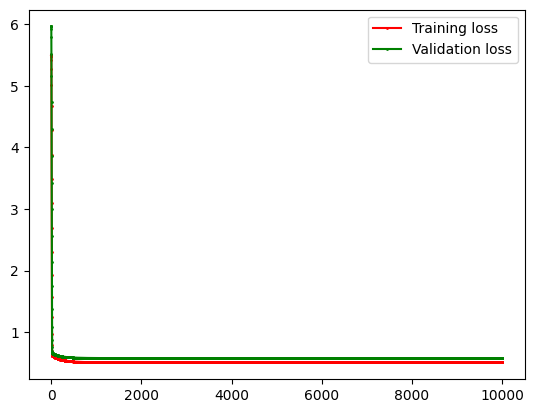

50. Training loss: 0.6242511208963603, Val loss:0.5874643268199063
100. Training loss: 0.6047652102092013, Val loss:0.577700847182516
150. Training loss: 0.5899060225994798, Val loss:0.5711436894292475
200. Training loss: 0.5783787915854591, Val loss:0.5667422367371966
250. Training loss: 0.5693029339105223, Val loss:0.5638080968923553
300. Training loss: 0.5620657413500989, Val loss:0.5618825383877281
350. Training loss: 0.5562314142253798, Val loss:0.5606550493516289
400. Training loss: 0.551483611927171, Val loss:0.5599125144724677
450. Training loss: 0.5475884340754075, Val loss:0.5595069231074585
500. Training loss: 0.5443700506565782, Val loss:0.5593344729906458
550. Training loss: 0.5416943170271058, Val loss:0.5593218080209788
600. Training loss: 0.5394575342296621, Val loss:0.5594168040433434
650. Training loss: 0.5375785928954687, Val loss:0.5595823053723932
700. Training loss: 0.5359933858145159, Val loss:0.559791807820334
750. Training loss: 0.534650769651295, Val loss:0.56

6750. Training loss: 0.5262318504119595, Val loss:0.5636861551876129
6800. Training loss: 0.5262318492054056, Val loss:0.5636861572226194
6850. Training loss: 0.5262318481169961, Val loss:0.5636861590684978
6900. Training loss: 0.5262318471350981, Val loss:0.5636861607429416
6950. Training loss: 0.5262318462492307, Val loss:0.5636861622619772
7000. Training loss: 0.52623184544995, Val loss:0.5636861636401218
7050. Training loss: 0.5262318447287465, Val loss:0.5636861648905274
7100. Training loss: 0.5262318440779516, Val loss:0.5636861660251092
7150. Training loss: 0.526231843490654, Val loss:0.5636861670546641
7200. Training loss: 0.5262318429606245, Val loss:0.563686167988975
7250. Training loss: 0.5262318424822489, Val loss:0.5636861688369074
7300. Training loss: 0.5262318420504659, Val loss:0.5636861696064962
7350. Training loss: 0.5262318416607132, Val loss:0.5636861703050241
7400. Training loss: 0.5262318413088777, Val loss:0.563686170939092
7450. Training loss: 0.5262318409912508

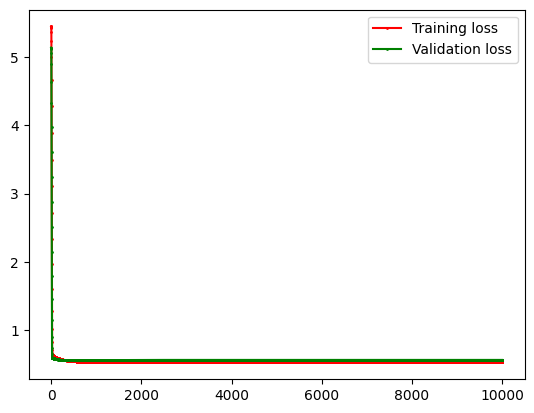


================ learning_rate = 0.5 ================
50. Training loss: 0.6145467995870154, Val loss:0.7754974756208767
100. Training loss: 0.5492616620299325, Val loss:0.6955826909588403
150. Training loss: 0.5258745793718639, Val loss:0.6630574677821807
200. Training loss: 0.5169468035974042, Val loss:0.648539081800721
250. Training loss: 0.5131669022421077, Val loss:0.6412153498694687
300. Training loss: 0.5113950497307272, Val loss:0.6371118965259314
350. Training loss: 0.5104848537444594, Val loss:0.6346141990444455
400. Training loss: 0.5099779248007873, Val loss:0.6329932433977687
450. Training loss: 0.5096748717042164, Val loss:0.6318873945338747
500. Training loss: 0.5094822146047031, Val loss:0.6311024831918287
550. Training loss: 0.5093531116332073, Val loss:0.6305272632880661
600. Training loss: 0.5092626543861016, Val loss:0.6300945309043021
650. Training loss: 0.5091968730511663, Val loss:0.6297618733321881
700. Training loss: 0.5091475472022329, Val loss:0.629501518148

6650. Training loss: 0.5089399525573266, Val loss:0.6283030015754866
6700. Training loss: 0.5089399525571124, Val loss:0.6283030015741795
6750. Training loss: 0.5089399525569291, Val loss:0.6283030015730606
6800. Training loss: 0.5089399525567722, Val loss:0.6283030015721026
6850. Training loss: 0.5089399525566378, Val loss:0.6283030015712825
6900. Training loss: 0.5089399525565227, Val loss:0.6283030015705803
6950. Training loss: 0.5089399525564242, Val loss:0.6283030015699792
7000. Training loss: 0.5089399525563398, Val loss:0.6283030015694644
7050. Training loss: 0.5089399525562677, Val loss:0.628303001569024
7100. Training loss: 0.5089399525562059, Val loss:0.6283030015686467
7150. Training loss: 0.508939952556153, Val loss:0.6283030015683239
7200. Training loss: 0.5089399525561077, Val loss:0.6283030015680475
7250. Training loss: 0.5089399525560688, Val loss:0.6283030015678107
7300. Training loss: 0.5089399525560357, Val loss:0.6283030015676082
7350. Training loss: 0.5089399525560

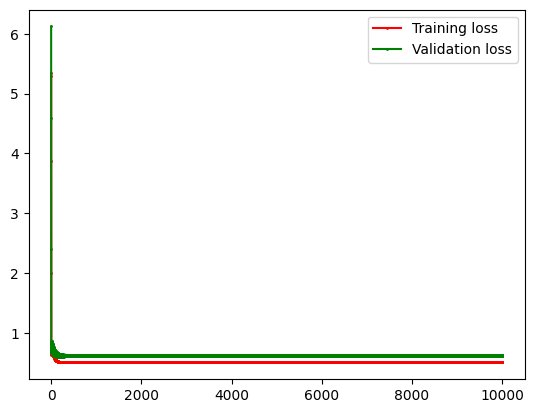

50. Training loss: 0.6087109165528669, Val loss:0.6569894219199863
100. Training loss: 0.5444391089130404, Val loss:0.6025867238161512
150. Training loss: 0.5215194545377329, Val loss:0.5836343400600601
200. Training loss: 0.5132442921596165, Val loss:0.5768914729841558
250. Training loss: 0.510186289706002, Val loss:0.5745124828169319
300. Training loss: 0.508956665258352, Val loss:0.5736929012736992
350. Training loss: 0.5083930548619132, Val loss:0.5734190072081893
400. Training loss: 0.5081068423136618, Val loss:0.5733340058175419
450. Training loss: 0.5079535185321633, Val loss:0.5733125188645799
500. Training loss: 0.5078693475943534, Val loss:0.5733105905353549
550. Training loss: 0.5078225675730698, Val loss:0.5733134095331184
600. Training loss: 0.5077963730426865, Val loss:0.5733164824732716
650. Training loss: 0.5077816271462021, Val loss:0.5733187752979603
700. Training loss: 0.5077732919473809, Val loss:0.5733202812587287
750. Training loss: 0.5077685648868239, Val loss:0.

7150. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7200. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7250. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7300. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7350. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7400. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7450. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7500. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7550. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7600. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7650. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7700. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7750. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7800. Training loss: 0.5077622996312534, Val loss:0.5733226112942285
7850. Training loss: 0.50776229963

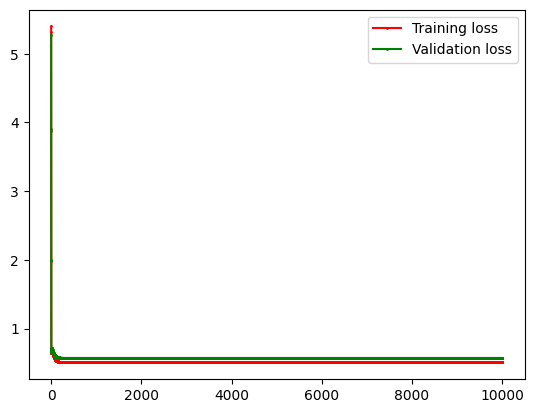

50. Training loss: 0.6443029799673302, Val loss:0.787253911720601
100. Training loss: 0.587928855251455, Val loss:0.7113314018695717
150. Training loss: 0.5670470882331026, Val loss:0.6830517478301628
200. Training loss: 0.5587024407465778, Val loss:0.6724712638562318
250. Training loss: 0.5550979135996549, Val loss:0.6684302160662347
300. Training loss: 0.5534383156087895, Val loss:0.666851523857401
350. Training loss: 0.5526319511386546, Val loss:0.6662145971996648
400. Training loss: 0.55222261079502, Val loss:0.6659468413591709
450. Training loss: 0.5520076966788305, Val loss:0.6658290458995256
500. Training loss: 0.5518919882112107, Val loss:0.6657747639763755
550. Training loss: 0.5518285148373738, Val loss:0.6657485966597007
600. Training loss: 0.551793202402673, Val loss:0.6657354421933738
650. Training loss: 0.5517733443203633, Val loss:0.6657285781871908
700. Training loss: 0.5517620826491842, Val loss:0.6657248807906715
750. Training loss: 0.5517556527720128, Val loss:0.6657

7350. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7400. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7450. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7500. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7550. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7600. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7650. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7700. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7750. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7800. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7850. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7900. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
7950. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
8000. Training loss: 0.5517468691349334, Val loss:0.6657200656707809
8050. Training loss: 0.55174686913

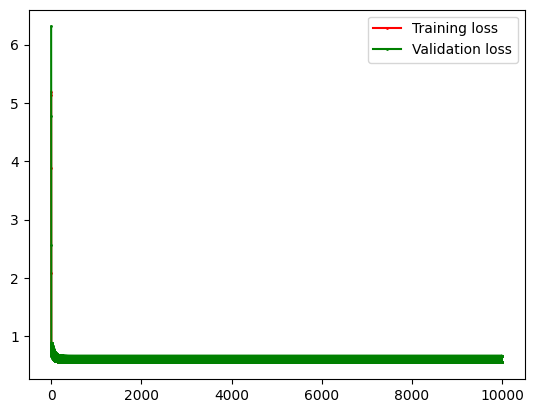

50. Training loss: 0.6082055732316586, Val loss:0.7100085922546207
100. Training loss: 0.5386291979648488, Val loss:0.6269132841622544
150. Training loss: 0.5181055444449819, Val loss:0.5975067937750543
200. Training loss: 0.5120599670791179, Val loss:0.5865980573336884
250. Training loss: 0.510103115096176, Val loss:0.5822141117413425
300. Training loss: 0.5093707609272985, Val loss:0.5804022103805982
350. Training loss: 0.5090501303943993, Val loss:0.5796501551259051
400. Training loss: 0.5088943554180086, Val loss:0.5793380255169319
450. Training loss: 0.5088146719883276, Val loss:0.579207949176083
500. Training loss: 0.5087728716724313, Val loss:0.5791531294059334
550. Training loss: 0.5087506080546748, Val loss:0.5791295795507928
600. Training loss: 0.5087386115128958, Val loss:0.5791191856210769
650. Training loss: 0.5087320817881041, Val loss:0.5791144383071386
700. Training loss: 0.5087284949514963, Val loss:0.5791121818563109
750. Training loss: 0.5087265079981471, Val loss:0.

6100. Training loss: 0.508723947053577, Val loss:0.579109750019347
6150. Training loss: 0.508723947053577, Val loss:0.579109750019347
6200. Training loss: 0.508723947053577, Val loss:0.579109750019347
6250. Training loss: 0.508723947053577, Val loss:0.579109750019347
6300. Training loss: 0.508723947053577, Val loss:0.579109750019347
6350. Training loss: 0.508723947053577, Val loss:0.579109750019347
6400. Training loss: 0.508723947053577, Val loss:0.579109750019347
6450. Training loss: 0.508723947053577, Val loss:0.579109750019347
6500. Training loss: 0.508723947053577, Val loss:0.579109750019347
6550. Training loss: 0.508723947053577, Val loss:0.579109750019347
6600. Training loss: 0.508723947053577, Val loss:0.579109750019347
6650. Training loss: 0.508723947053577, Val loss:0.579109750019347
6700. Training loss: 0.508723947053577, Val loss:0.579109750019347
6750. Training loss: 0.508723947053577, Val loss:0.579109750019347
6800. Training loss: 0.508723947053577, Val loss:0.57910975001

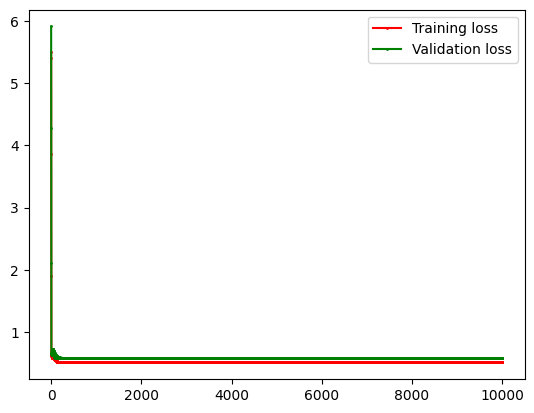

50. Training loss: 0.6406387212859094, Val loss:0.6195183485790523
100. Training loss: 0.5780800644678376, Val loss:0.5825959853834037
150. Training loss: 0.5550290345311778, Val loss:0.5730026218501102
200. Training loss: 0.5460039037116193, Val loss:0.5708397691122464
250. Training loss: 0.5422111562770923, Val loss:0.57058920743933
300. Training loss: 0.5405242442204264, Val loss:0.5707741336859724
350. Training loss: 0.539732135380554, Val loss:0.5709953288456716
400. Training loss: 0.5393392076242336, Val loss:0.5711625732434555
450. Training loss: 0.5391348851544372, Val loss:0.5712730150410869
500. Training loss: 0.5390250127507382, Val loss:0.571342131444199
550. Training loss: 0.5389646393780959, Val loss:0.5713844332158833
600. Training loss: 0.5389309897729665, Val loss:0.5714100820110586
650. Training loss: 0.5389120405293577, Val loss:0.5714255706977135
700. Training loss: 0.5389012824349216, Val loss:0.5714349085244609
750. Training loss: 0.5388951337979015, Val loss:0.57

6500. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6550. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6600. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6650. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6700. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6750. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6800. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6850. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6900. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
6950. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
7000. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
7050. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
7100. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
7150. Training loss: 0.5388867158527443, Val loss:0.5714491250196903
7200. Training loss: 0.53888671585

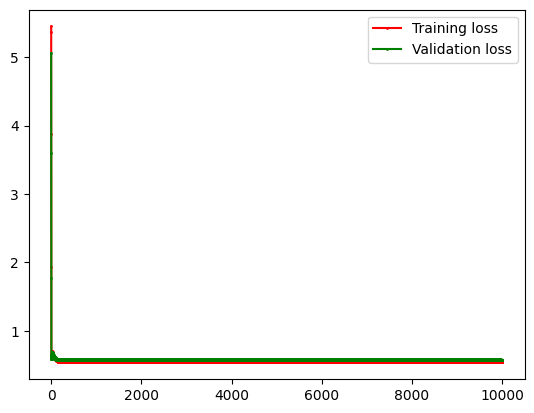


================ reg_lambda = 4.0 ================

================ learning_rate = 0.005 ================
50. Training loss: 5.345211818672327, Val loss:6.167643284831131
100. Training loss: 5.280625750508084, Val loss:6.112180911486277
150. Training loss: 4.73623559202074, Val loss:5.56039578857827
200. Training loss: 3.8038173666177153, Val loss:4.4976567678508195
250. Training loss: 2.8523830714957836, Val loss:3.3799252694319
300. Training loss: 1.9304746066402454, Val loss:2.2956006830004374
350. Training loss: 1.1431424952325844, Val loss:1.3623795669543637
400. Training loss: 0.7335760137181744, Val loss:0.8546130609917826
450. Training loss: 0.639793741026029, Val loss:0.7151758292827581
500. Training loss: 0.6262503778777516, Val loss:0.6847482217337174
550. Training loss: 0.623631028565751, Val loss:0.6765859568667018
600. Training loss: 0.6222722648114966, Val loss:0.6736303399155261
650. Training loss: 0.6210686141114171, Val loss:0.6721487693137137
700. Training loss: 0

6600. Training loss: 0.5631381547608567, Val loss:0.6362014488100011
6650. Training loss: 0.5629825272513618, Val loss:0.6361252231786805
6700. Training loss: 0.5628292401210258, Val loss:0.6360503504589446
6750. Training loss: 0.5626782551008984, Val loss:0.6359768046896861
6800. Training loss: 0.5625295346160007, Val loss:0.6359045604452047
6850. Training loss: 0.5623830417711967, Val loss:0.6358335928233679
6900. Training loss: 0.5622387403373871, Val loss:0.6357638774340525
6950. Training loss: 0.5620965947380178, Val loss:0.6356953903878549
7000. Training loss: 0.5619565700358944, Val loss:0.6356281082850721
7050. Training loss: 0.5618186319202952, Val loss:0.6355620082049371
7100. Training loss: 0.5616827466943753, Val loss:0.6354970676951106
7150. Training loss: 0.5615488812628554, Val loss:0.6354332647614174
7200. Training loss: 0.5614170031199852, Val loss:0.6353705778578228
7250. Training loss: 0.56128708033778, Val loss:0.6353089858766439
7300. Training loss: 0.5611590815545

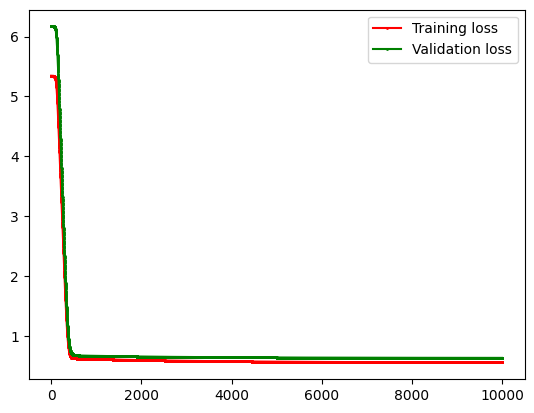

50. Training loss: 5.3942326913353025, Val loss:5.345292180193648
100. Training loss: 5.309508877219182, Val loss:5.269095472360334
150. Training loss: 4.747657360719056, Val loss:4.760922366491424
200. Training loss: 3.8078235615388487, Val loss:3.818403188862681
250. Training loss: 2.847395099574737, Val loss:2.8507354256705892
300. Training loss: 1.919015069350236, Val loss:1.9158635604714358
350. Training loss: 1.1356312637163606, Val loss:1.1311296213785675
400. Training loss: 0.7390769222494052, Val loss:0.7421887887299027
450. Training loss: 0.6495157480197081, Val loss:0.6580477604249629
500. Training loss: 0.636262470257571, Val loss:0.646751309170785
550. Training loss: 0.6335278179734131, Val loss:0.6448476479205401
600. Training loss: 0.6320412546507422, Val loss:0.643861043042043
650. Training loss: 0.630714964338709, Val loss:0.6429299738126514
700. Training loss: 0.6294276985851616, Val loss:0.6420014302522693
750. Training loss: 0.6281662422344013, Val loss:0.6410836437

7150. Training loss: 0.5644976221172212, Val loss:0.5995407761074899
7200. Training loss: 0.5643443896594711, Val loss:0.5994692652436957
7250. Training loss: 0.5641933260697194, Val loss:0.5993991017160815
7300. Training loss: 0.5640443975673742, Val loss:0.5993302598037632
7350. Training loss: 0.5638975709633379, Val loss:0.5992627142952072
7400. Training loss: 0.5637528136482091, Val loss:0.599196440477605
7450. Training loss: 0.5636100935807514, Val loss:0.5991314141264823
7500. Training loss: 0.5634693792766237, Val loss:0.5990676114955372
7550. Training loss: 0.5633306397973642, Val loss:0.599005009306705
7600. Training loss: 0.5631938447396233, Val loss:0.5989435847404404
7650. Training loss: 0.5630589642246371, Val loss:0.5988833154262139
7700. Training loss: 0.5629259688879366, Val loss:0.5988241794332162
7750. Training loss: 0.562794829869287, Val loss:0.5987661552612701
7800. Training loss: 0.5626655188028508, Val loss:0.5987092218319366
7850. Training loss: 0.56253800780756

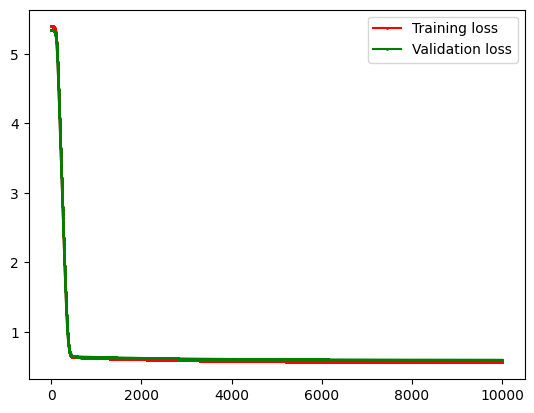

50. Training loss: 5.188968634160746, Val loss:6.373231060990504
100. Training loss: 5.130785059381679, Val loss:6.300203816173459
150. Training loss: 4.685135705271707, Val loss:5.723320251259381
200. Training loss: 3.8129996481169246, Val loss:4.6778628709029535
250. Training loss: 2.903017005103384, Val loss:3.5548485577889792
300. Training loss: 2.017116761377533, Val loss:2.4609738086962993
350. Training loss: 1.2356764287134838, Val loss:1.4916658761767512
400. Training loss: 0.7817460079417428, Val loss:0.907557599139781
450. Training loss: 0.6626504789445391, Val loss:0.7250107913493936
500. Training loss: 0.6447242859841327, Val loss:0.6826410214696751
550. Training loss: 0.6415812097825722, Val loss:0.6711866220085364
600. Training loss: 0.6401643901622025, Val loss:0.6671743107523047
650. Training loss: 0.6389528219339103, Val loss:0.6652882595965551
700. Training loss: 0.6377822569894998, Val loss:0.6640764056188209
750. Training loss: 0.6366357842381182, Val loss:0.6630942

8900. Training loss: 0.5757736299616647, Val loss:0.6207734696567876
8950. Training loss: 0.5756913673203056, Val loss:0.6207363479967432
9000. Training loss: 0.575610226134686, Val loss:0.6206999317023084
9050. Training loss: 0.5755301897221174, Val loss:0.6206642078373041
9100. Training loss: 0.5754512416751235, Val loss:0.6206291637041689
9150. Training loss: 0.5753733658563532, Val loss:0.6205947868394073
9200. Training loss: 0.5752965463936002, Val loss:0.6205610650091299
9250. Training loss: 0.5752207676749233, Val loss:0.6205279862046841
9300. Training loss: 0.5751460143438692, Val loss:0.6204955386383706
9350. Training loss: 0.5750722712947949, Val loss:0.620463710739249
9400. Training loss: 0.574999523668282, Val loss:0.6204324911490237
9450. Training loss: 0.5749277568466492, Val loss:0.6204018687180156
9500. Training loss: 0.574856956449555, Val loss:0.6203718325012113
9550. Training loss: 0.5747871083296893, Val loss:0.6203423717543944
9600. Training loss: 0.574718198568553

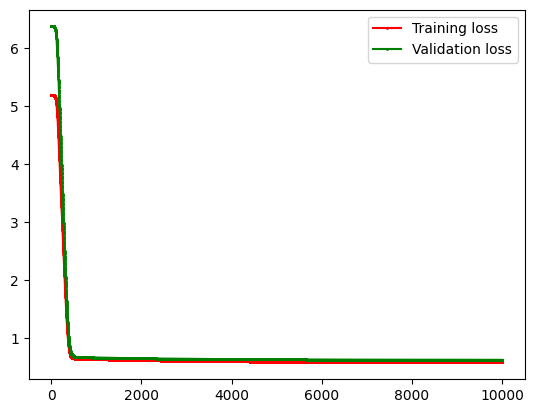

50. Training loss: 5.496642646171202, Val loss:5.962055508671761
100. Training loss: 5.40449731796224, Val loss:5.903136528043219
150. Training loss: 4.7973329126012985, Val loss:5.268935574890315
200. Training loss: 3.804477778102201, Val loss:4.190291293354671
250. Training loss: 2.802985334103809, Val loss:3.08621997451174
300. Training loss: 1.8399191717260404, Val loss:2.0245216685240734
350. Training loss: 1.0571644970364298, Val loss:1.1617448541449324
400. Training loss: 0.7054730361530924, Val loss:0.7672538843855718
450. Training loss: 0.6362183274989652, Val loss:0.6798973898502982
500. Training loss: 0.6263532193804233, Val loss:0.6633870779072067
550. Training loss: 0.6240135750425351, Val loss:0.6589659181058719
600. Training loss: 0.622536455571698, Val loss:0.6570123456960902
650. Training loss: 0.6211771871066306, Val loss:0.655713370552438
700. Training loss: 0.6198555630754169, Val loss:0.6546259131800626
750. Training loss: 0.6185628422361721, Val loss:0.65362040493

6700. Training loss: 0.5594236697818855, Val loss:0.6093906974332299
6750. Training loss: 0.5592771272999008, Val loss:0.6092843983471784
6800. Training loss: 0.5591328874908051, Val loss:0.6091798160787377
6850. Training loss: 0.55899091068375, Val loss:0.6090769203894545
6900. Training loss: 0.5588511579700588, Val loss:0.6089756816287124
6950. Training loss: 0.5587135911866729, Val loss:0.6088760707209673
7000. Training loss: 0.5585781729000044, Val loss:0.6087780591532935
7050. Training loss: 0.5584448663901883, Val loss:0.6086816189632352
7100. Training loss: 0.5583136356357205, Val loss:0.608586722726952
7150. Training loss: 0.5581844452984706, Val loss:0.6084933435476509
7200. Training loss: 0.5580572607090615, Val loss:0.6084014550442995
7250. Training loss: 0.5579320478526034, Val loss:0.6083110313406087
7300. Training loss: 0.5578087733547731, Val loss:0.6082220470542817
7350. Training loss: 0.5576874044682298, Val loss:0.6081344772865191
7400. Training loss: 0.55756790905935

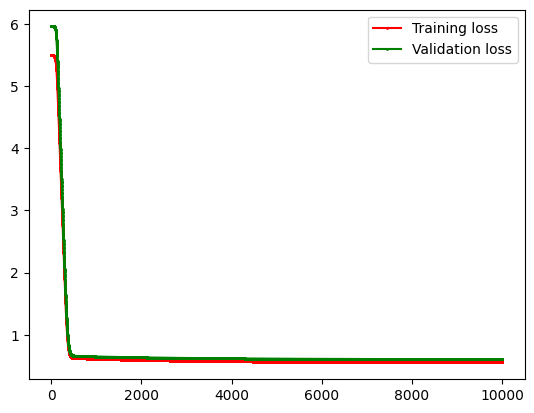

50. Training loss: 5.445447919742903, Val loss:5.139704404034276
100. Training loss: 5.3568905193230165, Val loss:5.0446395689921815
150. Training loss: 4.782159127412046, Val loss:4.424031665767683
200. Training loss: 3.8103083039184873, Val loss:3.5162297507412617
250. Training loss: 2.8239039365230476, Val loss:2.5861448204733555
300. Training loss: 1.8735846701847996, Val loss:1.6922386180190336
350. Training loss: 1.0906780442784776, Val loss:0.9677729920304395
400. Training loss: 0.723992370883004, Val loss:0.6500027507762313
450. Training loss: 0.648615755182974, Val loss:0.5969638600233411
500. Training loss: 0.6379792929817291, Val loss:0.5941891503040815
550. Training loss: 0.6357523495668813, Val loss:0.5949547765510551
600. Training loss: 0.6344904211116764, Val loss:0.5951130948711274
650. Training loss: 0.6333507427634819, Val loss:0.594876882266177
700. Training loss: 0.6322420956095455, Val loss:0.5944970306559344
750. Training loss: 0.6311548159362076, Val loss:0.59407

6650. Training loss: 0.5771176580145332, Val loss:0.5798090620820581
6700. Training loss: 0.5769633691888816, Val loss:0.5798115371993904
6750. Training loss: 0.5768113161082032, Val loss:0.5798145096553868
6800. Training loss: 0.5766614631027286, Val loss:0.5798179639127498
6850. Training loss: 0.5765137751382249, Val loss:0.5798218848157681
6900. Training loss: 0.5763682178032739, Val loss:0.5798262575813349
6950. Training loss: 0.5762247572968356, Val loss:0.5798310677901798
7000. Training loss: 0.5760833604160877, Val loss:0.579836301378314
7050. Training loss: 0.5759439945445369, Val loss:0.5798419446286803
7100. Training loss: 0.5758066276403938, Val loss:0.5798479841630018
7150. Training loss: 0.5756712282252054, Val loss:0.579854406933829
7200. Training loss: 0.5755377653727389, Val loss:0.5798612002167748
7250. Training loss: 0.5754062086981112, Val loss:0.5798683516029355
7300. Training loss: 0.5752765283471565, Val loss:0.5798758489914941
7350. Training loss: 0.5751486949860

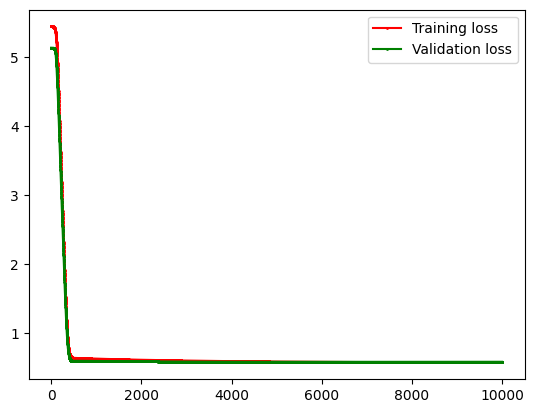


================ learning_rate = 0.01 ================
50. Training loss: 5.2846718485302455, Val loss:6.11214377372938
100. Training loss: 3.8226360267400303, Val loss:4.497248537023023
150. Training loss: 1.947507725570322, Val loss:2.294718869658039
200. Training loss: 0.735973051674664, Val loss:0.8523261559491175
250. Training loss: 0.6262411977911702, Val loss:0.6843682115098674
300. Training loss: 0.6222909952292737, Val loss:0.6735719088548696
350. Training loss: 0.6199194398211226, Val loss:0.6711256364186815
400. Training loss: 0.6176507567372267, Val loss:0.6694974261512957
450. Training loss: 0.6154673780589596, Val loss:0.6680122297563678
500. Training loss: 0.6133658302393552, Val loss:0.6665974385657493
550. Training loss: 0.6113426807787877, Val loss:0.6652428965696223
600. Training loss: 0.609394627746222, Val loss:0.6639451574603351
650. Training loss: 0.6075185199444884, Val loss:0.6627015964763021
700. Training loss: 0.6057113525028194, Val loss:0.6615097821301882


6050. Training loss: 0.5545672697471444, Val loss:0.6323993280482882
6100. Training loss: 0.5545032260573296, Val loss:0.6323749005620923
6150. Training loss: 0.5544409077643273, Val loss:0.6323512075952734
6200. Training loss: 0.5543802662505787, Val loss:0.6323282249873307
6250. Training loss: 0.5543212543476106, Val loss:0.6323059294289163
6300. Training loss: 0.5542638262896488, Val loss:0.6322842984300004
6350. Training loss: 0.5542079376688528, Val loss:0.6322633102893029
6400. Training loss: 0.5541535453921083, Val loss:0.6322429440649314
6450. Training loss: 0.5541006076393191, Val loss:0.6322231795461812
6500. Training loss: 0.5540490838231392, Val loss:0.6322039972264457
6550. Training loss: 0.5539989345500916, Val loss:0.6321853782771891
6600. Training loss: 0.5539501215830204, Val loss:0.6321673045229405
6650. Training loss: 0.5539026078048261, Val loss:0.6321497584172635
6700. Training loss: 0.553856357183437, Val loss:0.6321327230196648
6750. Training loss: 0.553811334737

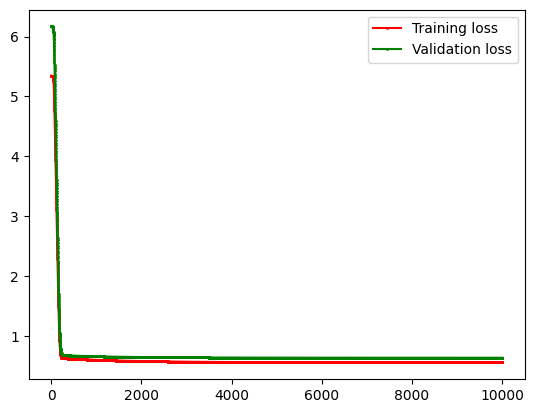

50. Training loss: 5.314086842238926, Val loss:5.269064686149155
100. Training loss: 3.8268250844541885, Val loss:3.8180488762625964
150. Training loss: 1.9360848721388062, Val loss:1.915079371017496
200. Training loss: 0.7413100026953725, Val loss:0.740580248193341
250. Training loss: 0.6362557177565452, Val loss:0.6466747518482138
300. Training loss: 0.6320621600941101, Val loss:0.6438597792436115
350. Training loss: 0.6294485842846067, Val loss:0.6419987066129597
400. Training loss: 0.6269486894177655, Val loss:0.6401785308477661
450. Training loss: 0.6245432231725755, Val loss:0.6384281902412547
500. Training loss: 0.6222281525691604, Val loss:0.6367491892338909
550. Training loss: 0.6199995595269157, Val loss:0.6351389236122591
600. Training loss: 0.6178536906618068, Val loss:0.633594484373193
650. Training loss: 0.6157869739621283, Val loss:0.6321130506611882
700. Training loss: 0.6137960122443253, Val loss:0.6306919237742546
750. Training loss: 0.6118775742709582, Val loss:0.629

6850. Training loss: 0.5550874172186078, Val loss:0.5960606364488837
6900. Training loss: 0.5550339067440182, Val loss:0.5960492981981699
6950. Training loss: 0.5549817214204397, Val loss:0.596038410389853
7000. Training loss: 0.5549308267787625, Val loss:0.5960279564009098
7050. Training loss: 0.554881189302387, Val loss:0.5960179202084002
7100. Training loss: 0.5548327763988631, Val loss:0.5960082863676447
7150. Training loss: 0.5547855563724525, Val loss:0.5959990399912184
7200. Training loss: 0.5547394983975822, Val loss:0.5959901667287288
7250. Training loss: 0.5546945724931558, Val loss:0.5959816527473472
7300. Training loss: 0.5546507494976946, Val loss:0.5959734847130651
7350. Training loss: 0.5546080010452749, Val loss:0.5959656497726463
7400. Training loss: 0.5545662995422375, Val loss:0.5959581355362485
7450. Training loss: 0.5545256181446381, Val loss:0.5959509300606879
7500. Training loss: 0.5544859307364158, Val loss:0.5959440218333236
7550. Training loss: 0.5544472119082

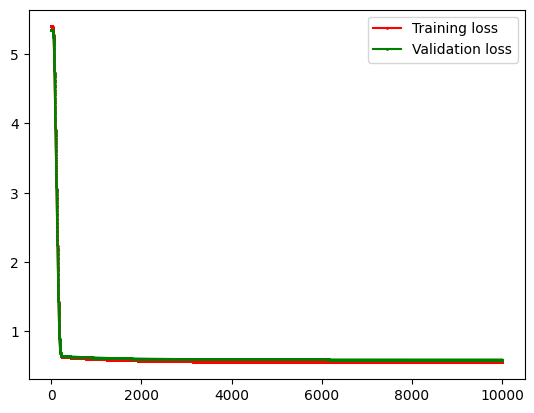

50. Training loss: 5.133885233469227, Val loss:6.300161362466314
100. Training loss: 3.830991109630889, Val loss:4.677453761636792
150. Training loss: 2.0336573866918752, Val loss:2.460148251377009
200. Training loss: 0.7849710324349627, Val loss:0.9051033212996025
250. Training loss: 0.6447126856071185, Val loss:0.6821322984999608
300. Training loss: 0.6401830372957361, Val loss:0.6670927085539206
350. Training loss: 0.6378012533275541, Val loss:0.6640617442602904
400. Training loss: 0.6355295375841603, Val loss:0.6621946604037893
450. Training loss: 0.6333450066391888, Val loss:0.6605108838156143
500. Training loss: 0.631243991476748, Val loss:0.658906307102224
550. Training loss: 0.6292228248847735, Val loss:0.6573673883761335
600. Training loss: 0.6272779827712073, Val loss:0.6558902251130106
650. Training loss: 0.6254061139322076, Val loss:0.6544720470965404
700. Training loss: 0.6236040347473589, Val loss:0.6531103147919275
750. Training loss: 0.6218687204076611, Val loss:0.65180

6700. Training loss: 0.5714321554749101, Val loss:0.6191923084034833
6750. Training loss: 0.5713818066183874, Val loss:0.6191804997174863
6800. Training loss: 0.5713327048032057, Val loss:0.6191692061868027
6850. Training loss: 0.5712848173033739, Val loss:0.6191584084220734
6900. Training loss: 0.5712381123151313, Val loss:0.6191480877272821
6950. Training loss: 0.5711925589286644, Val loss:0.6191382260751729
7000. Training loss: 0.5711481271007766, Val loss:0.6191288060835561
7050. Training loss: 0.5711047876284778, Val loss:0.6191198109924684
7100. Training loss: 0.5710625121234573, Val loss:0.6191112246421518
7150. Training loss: 0.5710212729874072, Val loss:0.6191030314518279
7200. Training loss: 0.5709810433881672, Val loss:0.6190952163992297
7250. Training loss: 0.5709417972366589, Val loss:0.6190877650008705
7300. Training loss: 0.5709035091645814, Val loss:0.6190806632930165
7350. Training loss: 0.5708661545028403, Val loss:0.6190738978133403
7400. Training loss: 0.57082970926

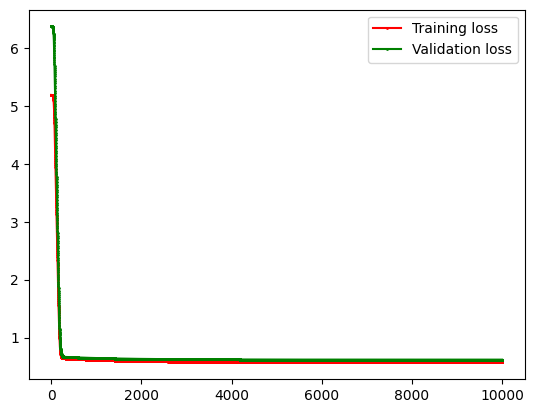

50. Training loss: 5.409715919541848, Val loss:5.9030975964552495
100. Training loss: 3.82429962299261, Val loss:4.189886206184307
150. Training loss: 1.8574128998214121, Val loss:2.0235625021247707
200. Training loss: 0.7070648402696705, Val loss:0.7654239910647658
250. Training loss: 0.6263511348398824, Val loss:0.6631892489615874
300. Training loss: 0.6225576767668325, Val loss:0.6569839546660902
350. Training loss: 0.619876255902774, Val loss:0.6546186410016939
400. Training loss: 0.6173170930600618, Val loss:0.6526512964813589
450. Training loss: 0.614865390635479, Val loss:0.6507977420304009
500. Training loss: 0.6125159721280695, Val loss:0.6490251865119819
550. Training loss: 0.6102638839569947, Val loss:0.647326826624453
600. Training loss: 0.6081044294013649, Val loss:0.6456987973832928
650. Training loss: 0.6060331690539612, Val loss:0.6441377178547156
700. Training loss: 0.6040459071374459, Val loss:0.6426404195644085
750. Training loss: 0.6021386770377298, Val loss:0.64120

6750. Training loss: 0.5509057359665724, Val loss:0.6033317430263284
6800. Training loss: 0.5508659008498283, Val loss:0.6033043707038258
6850. Training loss: 0.5508271425227416, Val loss:0.6032777540853814
6900. Training loss: 0.5507894303838188, Val loss:0.6032518710828079
6950. Training loss: 0.5507527347544727, Val loss:0.6032267002939717
7000. Training loss: 0.5507170268492056, Val loss:0.6032022209800532
7050. Training loss: 0.5506822787468317, Val loss:0.603178413043611
7100. Training loss: 0.5506484633627036, Val loss:0.6031552570074277
7150. Training loss: 0.5506155544219002, Val loss:0.6031327339941007
7200. Training loss: 0.5505835264333432, Val loss:0.6031108257063555
7250. Training loss: 0.5505523546648049, Val loss:0.6030895144080464
7300. Training loss: 0.5505220151187754, Val loss:0.603068782905828
7350. Training loss: 0.5504924845091571, Val loss:0.6030486145314644
7400. Training loss: 0.5504637402387542, Val loss:0.6030289931247556
7450. Training loss: 0.5504357603775

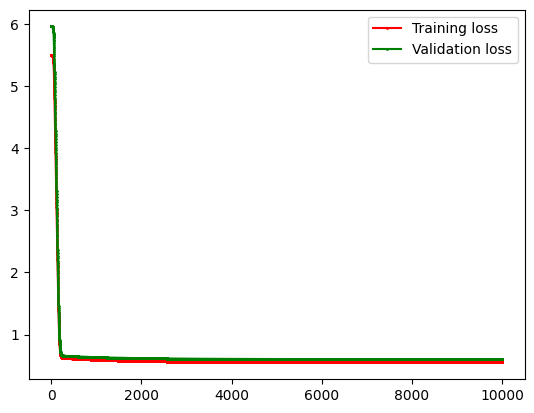

50. Training loss: 5.361577278788, Val loss:5.044582712331439
100. Training loss: 3.8298288285499473, Val loss:3.515888626745018
150. Training loss: 1.8909229432550714, Val loss:1.6914539525581982
200. Training loss: 0.7257817243767217, Val loss:0.6487404938178555
250. Training loss: 0.6379719158002196, Val loss:0.5942232134592194
300. Training loss: 0.6345081497983556, Val loss:0.5951284634889547
350. Training loss: 0.6322597454409715, Val loss:0.5944958642091545
400. Training loss: 0.6301044169732296, Val loss:0.5936445888343386
450. Training loss: 0.6280280810774581, Val loss:0.5928107406330307
500. Training loss: 0.6260275566834121, Val loss:0.5920181970798993
550. Training loss: 0.6240997305883994, Val loss:0.5912675146443913
600. Training loss: 0.6222416105496039, Val loss:0.5905568854626789
650. Training loss: 0.6204503384443336, Val loss:0.5898843468476304
700. Training loss: 0.6187231859649904, Val loss:0.5892480087865313
750. Training loss: 0.617057548581369, Val loss:0.58864

6300. Training loss: 0.5681130032866626, Val loss:0.5812594840700976
6350. Training loss: 0.5680522310234174, Val loss:0.5812835829641266
6400. Training loss: 0.567992995751603, Val loss:0.5813074074221909
6450. Training loss: 0.5679352562788934, Val loss:0.5813309555011532
6500. Training loss: 0.5678789725955362, Val loss:0.5813542255727174
6550. Training loss: 0.5678241058375583, Val loss:0.5813772163064714
6600. Training loss: 0.5677706182512244, Val loss:0.5813999266537001
6650. Training loss: 0.5677184731587042, Val loss:0.5814223558319345
6700. Training loss: 0.5676676349249001, Val loss:0.5814445033102045
6750. Training loss: 0.5676180689253941, Val loss:0.5814663687949648
6800. Training loss: 0.5675697415154702, Val loss:0.5814879522166646
6850. Training loss: 0.5675226200001755, Val loss:0.5815092537169322
6900. Training loss: 0.5674766726053789, Val loss:0.5815302736363496
6950. Training loss: 0.5674318684497929, Val loss:0.5815510125027883
7000. Training loss: 0.567388177517

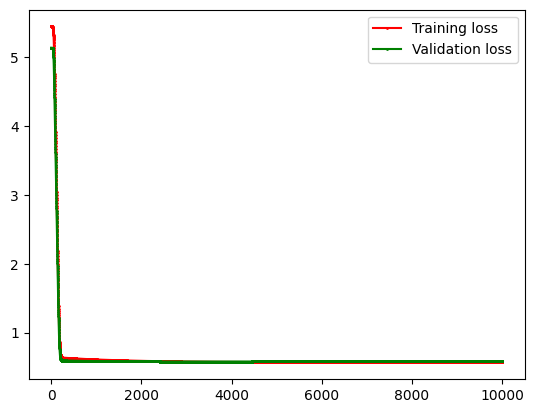


================ learning_rate = 0.1 ================
50. Training loss: 0.613651792620938, Val loss:0.6665524989735244
100. Training loss: 0.5963263995648701, Val loss:0.6552715827416409
150. Training loss: 0.5842785483113472, Val loss:0.6478359397198202
200. Training loss: 0.5757591075610071, Val loss:0.6428676978838441
250. Training loss: 0.5696475432304787, Val loss:0.6395045077398442
300. Training loss: 0.5652098176621417, Val loss:0.6371997202239255
350. Training loss: 0.5619545577126231, Val loss:0.635601999324353
400. Training loss: 0.5595462402627498, Val loss:0.6344824193204978
450. Training loss: 0.5577516856974439, Val loss:0.6336898459673427
500. Training loss: 0.5564063309314096, Val loss:0.6331232697771342
550. Training loss: 0.5553924912477336, Val loss:0.6327144109316052
600. Training loss: 0.5546250493863678, Val loss:0.6324166294687678
650. Training loss: 0.5540418476736496, Val loss:0.6321977596847572
700. Training loss: 0.5535971217959009, Val loss:0.6320354208737

6300. Training loss: 0.5520988546817117, Val loss:0.6314853242074018
6350. Training loss: 0.5520988546817016, Val loss:0.6314853242073303
6400. Training loss: 0.5520988546816934, Val loss:0.6314853242072712
6450. Training loss: 0.552098854681687, Val loss:0.6314853242072225
6500. Training loss: 0.5520988546816816, Val loss:0.6314853242071822
6550. Training loss: 0.5520988546816773, Val loss:0.6314853242071488
6600. Training loss: 0.552098854681674, Val loss:0.6314853242071211
6650. Training loss: 0.5520988546816711, Val loss:0.6314853242070984
6700. Training loss: 0.5520988546816689, Val loss:0.6314853242070795
6750. Training loss: 0.5520988546816671, Val loss:0.631485324207064
6800. Training loss: 0.5520988546816658, Val loss:0.6314853242070512
6850. Training loss: 0.5520988546816646, Val loss:0.6314853242070405
6900. Training loss: 0.5520988546816636, Val loss:0.6314853242070317
6950. Training loss: 0.552098854681663, Val loss:0.6314853242070245
7000. Training loss: 0.552098854681662

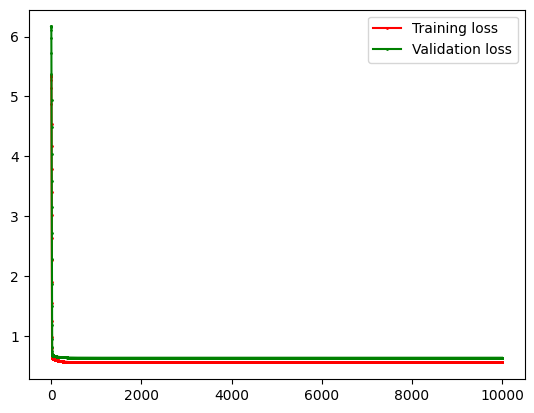

50. Training loss: 0.6225469186316849, Val loss:0.6366833773264672
100. Training loss: 0.6034531298183164, Val loss:0.6232222613053043
150. Training loss: 0.5901267748940368, Val loss:0.6142950583795164
200. Training loss: 0.5806370756174312, Val loss:0.6083255569083809
250. Training loss: 0.5737652156662078, Val loss:0.60430528809111
300. Training loss: 0.5687194779208087, Val loss:0.6015820197431692
350. Training loss: 0.5649717448820957, Val loss:0.5997291765447658
400. Training loss: 0.5621613464454521, Val loss:0.5984647808833056
450. Training loss: 0.5600368838651345, Val loss:0.5976006184069976
500. Training loss: 0.5584200208705511, Val loss:0.5970099750321782
550. Training loss: 0.5571823389686266, Val loss:0.5966069067909683
600. Training loss: 0.5562301768201549, Val loss:0.596332759007839
650. Training loss: 0.5554944766491056, Val loss:0.5961472997440964
700. Training loss: 0.5549238472885772, Val loss:0.5960228267509967
750. Training loss: 0.5544797402199992, Val loss:0.5

6950. Training loss: 0.5528377658569472, Val loss:0.5958289177915977
7000. Training loss: 0.5528377658569461, Val loss:0.5958289177916002
7050. Training loss: 0.5528377658569452, Val loss:0.5958289177916021
7100. Training loss: 0.5528377658569446, Val loss:0.5958289177916037
7150. Training loss: 0.552837765856944, Val loss:0.5958289177916052
7200. Training loss: 0.5528377658569436, Val loss:0.5958289177916064
7250. Training loss: 0.5528377658569432, Val loss:0.5958289177916074
7300. Training loss: 0.5528377658569429, Val loss:0.5958289177916082
7350. Training loss: 0.5528377658569427, Val loss:0.595828917791609
7400. Training loss: 0.5528377658569426, Val loss:0.5958289177916095
7450. Training loss: 0.5528377658569424, Val loss:0.59582891779161
7500. Training loss: 0.5528377658569423, Val loss:0.5958289177916105
7550. Training loss: 0.5528377658569422, Val loss:0.5958289177916107
7600. Training loss: 0.5528377658569422, Val loss:0.595828917791611
7650. Training loss: 0.5528377658569421

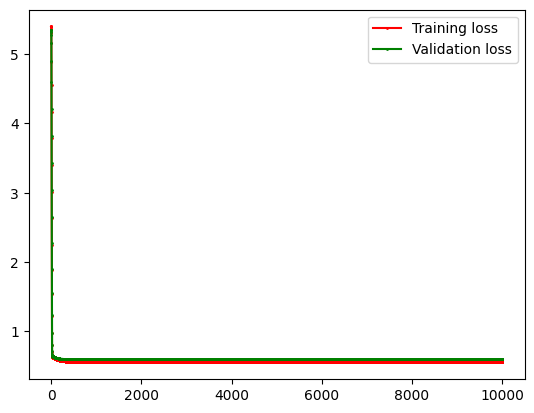

50. Training loss: 0.6315333884380095, Val loss:0.6588500351043464
100. Training loss: 0.6142628173150991, Val loss:0.6459334555015224
150. Training loss: 0.6022834936045864, Val loss:0.6372719844298916
200. Training loss: 0.5938023819285994, Val loss:0.6314117698877038
250. Training loss: 0.5876940069718393, Val loss:0.6274221963206185
300. Training loss: 0.583230818078244, Val loss:0.6246956520454946
350. Training loss: 0.5799299344849003, Val loss:0.6228289608709126
400. Training loss: 0.5774634164176525, Val loss:0.6215511590922037
450. Training loss: 0.575604079952878, Val loss:0.6206783159916681
500. Training loss: 0.5741918109965775, Val loss:0.6200846156360337
550. Training loss: 0.5731120669494586, Val loss:0.6196834922149047
600. Training loss: 0.5722818327865452, Val loss:0.6194151316584952
650. Training loss: 0.5716402547560726, Val loss:0.6192380859582374
700. Training loss: 0.5711422773401111, Val loss:0.6191235885054603
750. Training loss: 0.5707542485035169, Val loss:0.

6550. Training loss: 0.5693030420595646, Val loss:0.6190393060988271
6600. Training loss: 0.5693030420595487, Val loss:0.6190393060988205
6650. Training loss: 0.5693030420595359, Val loss:0.6190393060988149
6700. Training loss: 0.5693030420595252, Val loss:0.6190393060988101
6750. Training loss: 0.5693030420595164, Val loss:0.619039306098806
6800. Training loss: 0.5693030420595092, Val loss:0.6190393060988028
6850. Training loss: 0.5693030420595031, Val loss:0.6190393060987996
6900. Training loss: 0.5693030420594983, Val loss:0.6190393060987971
6950. Training loss: 0.5693030420594942, Val loss:0.6190393060987951
7000. Training loss: 0.5693030420594909, Val loss:0.6190393060987933
7050. Training loss: 0.5693030420594882, Val loss:0.6190393060987918
7100. Training loss: 0.5693030420594859, Val loss:0.6190393060987905
7150. Training loss: 0.5693030420594841, Val loss:0.6190393060987895
7200. Training loss: 0.5693030420594826, Val loss:0.6190393060987887
7250. Training loss: 0.569303042059

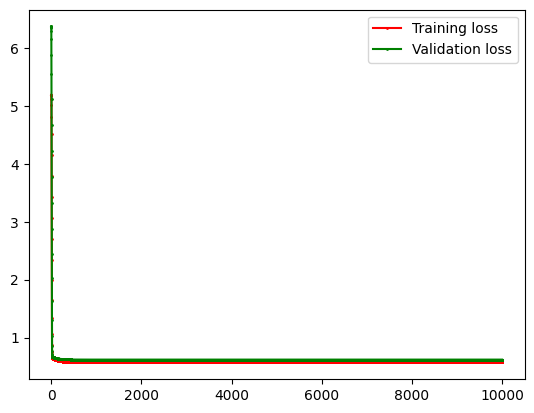

50. Training loss: 0.6128250126746891, Val loss:0.6489532181948208
100. Training loss: 0.5938430484722987, Val loss:0.6347631752820752
150. Training loss: 0.5810837046028509, Val loss:0.6252634045698908
200. Training loss: 0.5723002923877508, Val loss:0.6187623839567322
250. Training loss: 0.5661366901900095, Val loss:0.6142332079645995
300. Training loss: 0.5617439451630469, Val loss:0.6110312024997615
350. Training loss: 0.5585733937924643, Val loss:0.6087397247006574
400. Training loss: 0.5562608287719073, Val loss:0.6070828631664489
450. Training loss: 0.5545590737739954, Val loss:0.6058741726018365
500. Training loss: 0.5532972790998394, Val loss:0.6049855320032596
550. Training loss: 0.5523555396742515, Val loss:0.6043276529306688
600. Training loss: 0.5516486186255269, Val loss:0.6038375621503379
650. Training loss: 0.5511152583581899, Val loss:0.6034703862733838
700. Training loss: 0.5507110179008508, Val loss:0.6031938598898646
750. Training loss: 0.5504033902371803, Val loss:

7100. Training loss: 0.54936956222702, Val loss:0.6022855467521392
7150. Training loss: 0.54936956222702, Val loss:0.6022855467521377
7200. Training loss: 0.5493695622270199, Val loss:0.6022855467521363
7250. Training loss: 0.5493695622270199, Val loss:0.6022855467521353
7300. Training loss: 0.5493695622270199, Val loss:0.6022855467521343
7350. Training loss: 0.5493695622270199, Val loss:0.6022855467521335
7400. Training loss: 0.5493695622270199, Val loss:0.6022855467521329
7450. Training loss: 0.5493695622270198, Val loss:0.6022855467521325
7500. Training loss: 0.5493695622270198, Val loss:0.602285546752132
7550. Training loss: 0.5493695622270198, Val loss:0.6022855467521316
7600. Training loss: 0.5493695622270198, Val loss:0.6022855467521312
7650. Training loss: 0.5493695622270198, Val loss:0.602285546752131
7700. Training loss: 0.5493695622270198, Val loss:0.6022855467521308
7750. Training loss: 0.5493695622270199, Val loss:0.6022855467521308
7800. Training loss: 0.5493695622270198,

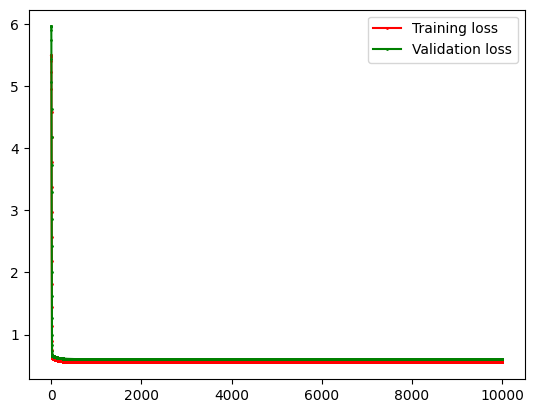

50. Training loss: 0.6262976352566525, Val loss:0.5919400269763255
100. Training loss: 0.6097246374704712, Val loss:0.586030428307352
150. Training loss: 0.5980879819158222, Val loss:0.5827118070142943
200. Training loss: 0.5897811238895725, Val loss:0.5809467883835513
250. Training loss: 0.5837650297477086, Val loss:0.5801075536649279
300. Training loss: 0.5793534408452893, Val loss:0.5798115399889939
350. Training loss: 0.5760837206988955, Val loss:0.5798248573364242
400. Training loss: 0.573638008707075, Val loss:0.5800047433883918
450. Training loss: 0.5717941436608035, Val loss:0.5802647657914937
500. Training loss: 0.5703944746651792, Val loss:0.5805534882589277
550. Training loss: 0.5693256253274303, Val loss:0.580841238714381
600. Training loss: 0.5685051021846955, Val loss:0.5811118293128265
650. Training loss: 0.5678722674009536, Val loss:0.5813573445390977
700. Training loss: 0.5673821495407381, Val loss:0.5815748518894325
750. Training loss: 0.5670011345807524, Val loss:0.5

7150. Training loss: 0.5655901540898417, Val loss:0.5827653230281805
7200. Training loss: 0.56559015408984, Val loss:0.5827653230281847
7250. Training loss: 0.5655901540898387, Val loss:0.5827653230281881
7300. Training loss: 0.5655901540898375, Val loss:0.582765323028191
7350. Training loss: 0.5655901540898365, Val loss:0.5827653230281932
7400. Training loss: 0.5655901540898357, Val loss:0.5827653230281952
7450. Training loss: 0.5655901540898352, Val loss:0.582765323028197
7500. Training loss: 0.5655901540898346, Val loss:0.5827653230281983
7550. Training loss: 0.5655901540898342, Val loss:0.5827653230281993
7600. Training loss: 0.5655901540898338, Val loss:0.5827653230282002
7650. Training loss: 0.5655901540898335, Val loss:0.582765323028201
7700. Training loss: 0.5655901540898333, Val loss:0.5827653230282016
7750. Training loss: 0.5655901540898329, Val loss:0.5827653230282023
7800. Training loss: 0.5655901540898328, Val loss:0.5827653230282026
7850. Training loss: 0.5655901540898327

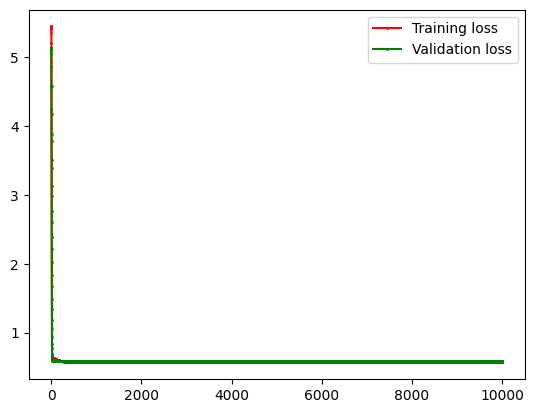


================ learning_rate = 0.5 ================
50. Training loss: 0.6763769366529954, Val loss:0.8568404174405669
100. Training loss: 0.6437426352102477, Val loss:0.8214041659987991
150. Training loss: 0.6362069296159706, Val loss:0.813275978572828
200. Training loss: 0.6344543362079591, Val loss:0.811482671118984
250. Training loss: 0.634022324535797, Val loss:0.8110660506758997
300. Training loss: 0.6339087373955522, Val loss:0.8109610974339647
350. Training loss: 0.633877033919992, Val loss:0.8109320627011221
400. Training loss: 0.6338677003414936, Val loss:0.8109232171512575
450. Training loss: 0.6338648216739696, Val loss:0.8109202772195528
500. Training loss: 0.6338638983345525, Val loss:0.8109192314418691
550. Training loss: 0.6338635926322527, Val loss:0.8109188418399446
600. Training loss: 0.6338634889000458, Val loss:0.8109186925719726
650. Training loss: 0.6338634530492776, Val loss:0.8109186345058398
700. Training loss: 0.633863440494064, Val loss:0.8109186117538029

7250. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7300. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7350. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7400. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7450. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7500. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7550. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7600. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7650. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7700. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7750. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7800. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7850. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7900. Training loss: 0.6338634336026882, Val loss:0.8109185970382997
7950. Training loss: 0.63386343360

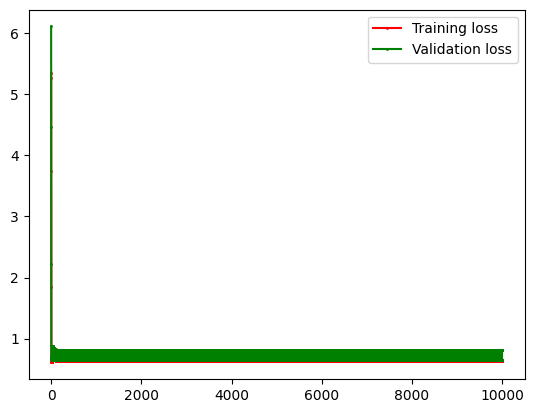

50. Training loss: 0.6829372230065857, Val loss:0.6941274662382433
100. Training loss: 0.6435494933633087, Val loss:0.6637100719260177
150. Training loss: 0.6341864462699959, Val loss:0.6569739072909832
200. Training loss: 0.6318583583690602, Val loss:0.6554368809667352
250. Training loss: 0.6312266675787997, Val loss:0.6550586042736647
300. Training loss: 0.6310414171571816, Val loss:0.6549582215722342
350. Training loss: 0.6309836902727772, Val loss:0.6549297351121174
400. Training loss: 0.630964867075042, Val loss:0.654921178732627
450. Training loss: 0.6309585245673074, Val loss:0.6549184900901608
500. Training loss: 0.630956337464738, Val loss:0.65491761685324
550. Training loss: 0.6309555711260207, Val loss:0.6549173269453153
600. Training loss: 0.6309552996511313, Val loss:0.6549172294913426
650. Training loss: 0.6309552027582388, Val loss:0.6549171965813328
700. Training loss: 0.630955167997988, Val loss:0.6549171854922252
750. Training loss: 0.6309551554838757, Val loss:0.6549

6850. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
6900. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
6950. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7000. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7050. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7100. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7150. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7200. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7250. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7300. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7350. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7400. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7450. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7500. Training loss: 0.6309551484104265, Val loss:0.6549171800151611
7550. Training loss: 0.63095514841

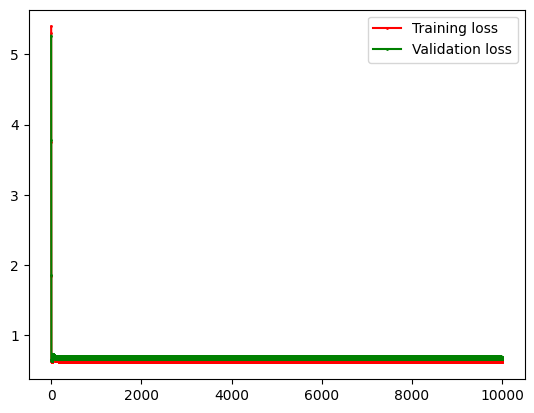

50. Training loss: 0.6932249518998949, Val loss:0.8713422126389817
100. Training loss: 0.6661076404040457, Val loss:0.8424592671421934
150. Training loss: 0.6594498157985349, Val loss:0.8363535992546772
200. Training loss: 0.6577066991272129, Val loss:0.8351675513692314
250. Training loss: 0.657211737903661, Val loss:0.8349531324754415
300. Training loss: 0.6570616353108084, Val loss:0.83492144049094
350. Training loss: 0.6570138146457589, Val loss:0.8349200771817247
400. Training loss: 0.6569980077562152, Val loss:0.8349218396065093
450. Training loss: 0.6569926357104892, Val loss:0.8349229756873805
500. Training loss: 0.656990771157368, Val loss:0.8349234917149967
550. Training loss: 0.6569901135532613, Val loss:0.8349236978356563
600. Training loss: 0.6569898787662763, Val loss:0.8349237746871998
650. Training loss: 0.6569897941431195, Val loss:0.8349238020496206
700. Training loss: 0.656989763416574, Val loss:0.8349238114352637
750. Training loss: 0.6569897521941475, Val loss:0.834

6200. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6250. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6300. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6350. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6400. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6450. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6500. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6550. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6600. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6650. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6700. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6750. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6800. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6850. Training loss: 0.6569897456669048, Val loss:0.8349238159217739
6900. Training loss: 0.65698974566

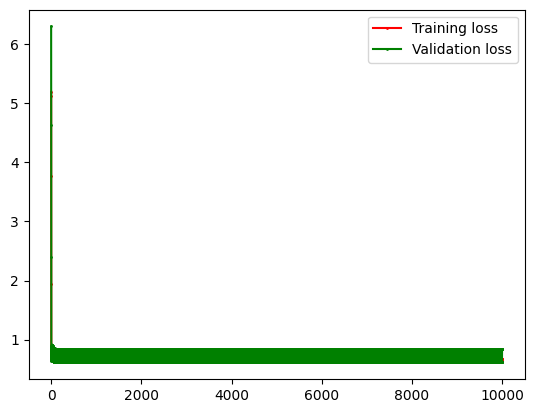

50. Training loss: 0.6771183191360011, Val loss:0.6661021257091252
100. Training loss: 0.6413735050665123, Val loss:0.6391087480470719
150. Training loss: 0.634155324171225, Val loss:0.6331148842645964
200. Training loss: 0.6325973233377076, Val loss:0.6316158357878123
250. Training loss: 0.6322158606156132, Val loss:0.6311885600796125
300. Training loss: 0.6321124110413382, Val loss:0.6310553394222858
350. Training loss: 0.6320823943397659, Val loss:0.6310114364091879
400. Training loss: 0.6320732964439281, Val loss:0.6309964531103578
450. Training loss: 0.6320704560496319, Val loss:0.6309912183191206
500. Training loss: 0.6320695500632416, Val loss:0.6309893588159774
550. Training loss: 0.632069256350357, Val loss:0.6309886901541907
600. Training loss: 0.6320691599177666, Val loss:0.6309884474639872
650. Training loss: 0.6320691279386917, Val loss:0.6309883587394979
700. Training loss: 0.6320691172493144, Val loss:0.6309883261148965
750. Training loss: 0.6320691136537194, Val loss:0.

6750. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
6800. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
6850. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
6900. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
6950. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7000. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7050. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7100. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7150. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7200. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7250. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7300. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7350. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7400. Training loss: 0.6320691118127926, Val loss:0.6309883069343462
7450. Training loss: 0.63206911181

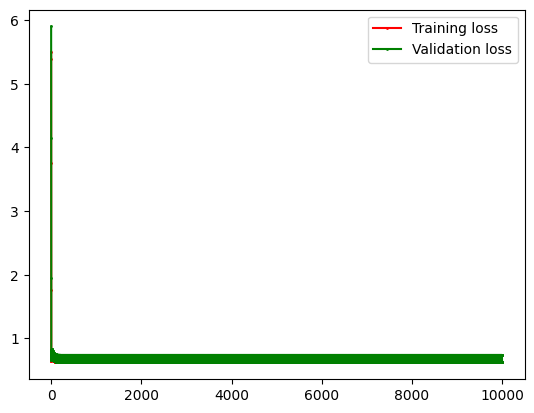

50. Training loss: 0.7119474571420794, Val loss:0.7127678814949358
100. Training loss: 0.6796323726096697, Val loss:0.6939485539422388
150. Training loss: 0.6715851154757431, Val loss:0.6903428432244724
200. Training loss: 0.6695325450615931, Val loss:0.6897325038188056
250. Training loss: 0.6689681352525546, Val loss:0.689645212435497
300. Training loss: 0.6688008698106567, Val loss:0.6896393439848142
350. Training loss: 0.6687481962379812, Val loss:0.6896423556841196
400. Training loss: 0.6687308335270993, Val loss:0.6896445192521854
450. Training loss: 0.6687249162827579, Val loss:0.6896455390766322
500. Training loss: 0.6687228504071902, Val loss:0.6896459642047775
550. Training loss: 0.6687221163657001, Val loss:0.6896461327207818
600. Training loss: 0.6687218521423642, Val loss:0.689646198079943
650. Training loss: 0.6687217561001982, Val loss:0.689646223233213
700. Training loss: 0.6687217209267023, Val loss:0.689646232912355
750. Training loss: 0.6687217079686752, Val loss:0.68

6500. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6550. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6600. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6650. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6700. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6750. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6800. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6850. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6900. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
6950. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
7000. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
7050. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
7100. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
7150. Training loss: 0.6687217003272148, Val loss:0.6896462390545606
7200. Training loss: 0.66872170032

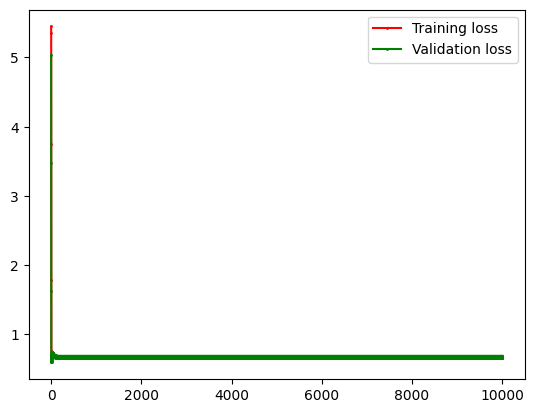


================ reg_lambda = 8.0 ================

================ learning_rate = 0.005 ================
50. Training loss: 5.344396220994237, Val loss:6.167643284831131
100. Training loss: 5.253021599085689, Val loss:6.082582988501678
150. Training loss: 4.592241715395213, Val loss:5.412086047333427
200. Training loss: 3.6077731796743966, Val loss:4.264838142965268
250. Training loss: 2.632259508051684, Val loss:3.1184799406106642
300. Training loss: 1.7083520968943344, Val loss:2.030724798236476
350. Training loss: 0.9881988129362185, Val loss:1.1720916564575974
400. Training loss: 0.6902576502914904, Val loss:0.7910771321658102
450. Training loss: 0.6356362720958428, Val loss:0.7011021319292043
500. Training loss: 0.6282977163154901, Val loss:0.6812588491570752
550. Training loss: 0.6267078727879607, Val loss:0.6755926309578383
600. Training loss: 0.6257504236186155, Val loss:0.6733969957840967
650. Training loss: 0.6248782751774754, Val loss:0.6722156682658839
700. Training los

7150. Training loss: 0.5959606200156564, Val loss:0.6506983819147781
7200. Training loss: 0.5959340925237822, Val loss:0.6506858591418382
7250. Training loss: 0.595908186564723, Val loss:0.6506736757186299
7300. Training loss: 0.5958828870271865, Val loss:0.6506618219001349
7350. Training loss: 0.5958581791876328, Val loss:0.6506502882370183
7400. Training loss: 0.5958340486995674, Val loss:0.650639065566164
7450. Training loss: 0.5958104815831609, Val loss:0.6506281450015267
7500. Training loss: 0.5957874642151771, Val loss:0.650617517925294
7550. Training loss: 0.5957649833192074, Val loss:0.650607175979344
7600. Training loss: 0.5957430259561918, Val loss:0.6505971110569906
7650. Training loss: 0.5957215795152273, Val loss:0.6505873152950034
7700. Training loss: 0.5957006317046465, Val loss:0.6505777810658957
7750. Training loss: 0.5956801705433612, Val loss:0.6505685009704695
7800. Training loss: 0.5956601843524616, Val loss:0.6505594678306078
7850. Training loss: 0.595640661747063

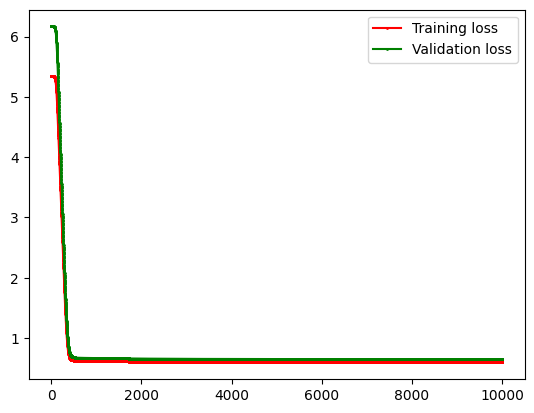

50. Training loss: 5.3929162045614705, Val loss:5.345292180193648
100. Training loss: 5.279390552716923, Val loss:5.244574562937713
150. Training loss: 4.60620229587928, Val loss:4.624461617516893
200. Training loss: 3.6110250009607117, Val loss:3.6194454228402173
250. Training loss: 2.626753766924878, Val loss:2.6279612843590607
300. Training loss: 1.697821522573221, Val loss:1.693174609498168
350. Training loss: 0.9848650635717972, Val loss:0.9815614740420179
400. Training loss: 0.6974591543284865, Val loss:0.7020812392514925
450. Training loss: 0.6448674636896387, Val loss:0.6534024757035672
500. Training loss: 0.637473410602481, Val loss:0.6473359961361153
550. Training loss: 0.6356835599483033, Val loss:0.6461288741305145
600. Training loss: 0.6345333642463254, Val loss:0.6453465425715442
650. Training loss: 0.6334762919272965, Val loss:0.6445899589198747
700. Training loss: 0.6324555712588522, Val loss:0.6438460755775927
750. Training loss: 0.6314653860426154, Val loss:0.64312249

7250. Training loss: 0.5972363036207086, Val loss:0.6229564847254189
7300. Training loss: 0.597200602146645, Val loss:0.6229482935785668
7350. Training loss: 0.5971656877015435, Val loss:0.6229403771519574
7400. Training loss: 0.5971315421627157, Val loss:0.6229327265320831
7450. Training loss: 0.5970981478517228, Val loss:0.6229253330955709
7500. Training loss: 0.5970654875225296, Val loss:0.622918188499513
7550. Training loss: 0.5970335443500068, Val loss:0.6229112846721325
7600. Training loss: 0.5970023019187707, Val loss:0.622904613803769
7650. Training loss: 0.5969717442123511, Val loss:0.6228981683381741
7700. Training loss: 0.5969418556026757, Val loss:0.6228919409641068
7750. Training loss: 0.5969126208398589, Val loss:0.6228859246072155
7800. Training loss: 0.5968840250422893, Val loss:0.6228801124221995
7850. Training loss: 0.5968560536870025, Val loss:0.6228744977852383
7900. Training loss: 0.5968286926003307, Val loss:0.622869074286678
7950. Training loss: 0.596801927948823

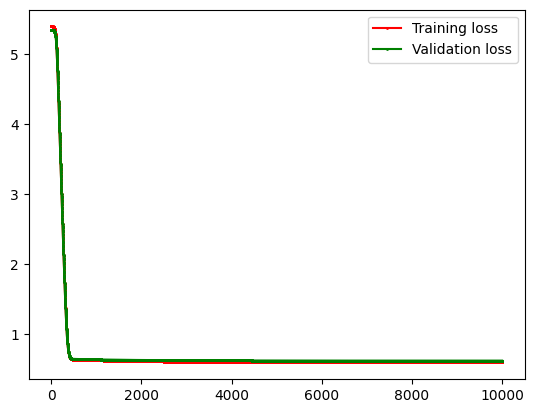

50. Training loss: 5.188329241362757, Val loss:6.373231060990504
100. Training loss: 5.107552953269216, Val loss:6.266156024005537
150. Training loss: 4.552940284456128, Val loss:5.577413301256492
200. Training loss: 3.619502690341283, Val loss:4.438474412504878
250. Training loss: 2.6847439476340256, Val loss:3.2850783582139966
300. Training loss: 1.792896807270846, Val loss:2.1835761854505007
350. Training loss: 1.0650525492795129, Val loss:1.276797868919625
400. Training loss: 0.724482359599537, Val loss:0.8251714566645116
450. Training loss: 0.6544793465567637, Val loss:0.7058545299610895
500. Training loss: 0.6448364539818711, Val loss:0.6783538966946815
550. Training loss: 0.6428718757497324, Val loss:0.6705567507430743
600. Training loss: 0.6417531479784319, Val loss:0.6677022475562497
650. Training loss: 0.6407430791144769, Val loss:0.6663003026894957
700. Training loss: 0.6397686509383165, Val loss:0.6653680001242738
750. Training loss: 0.6388232843203054, Val loss:0.664602668

6600. Training loss: 0.6070152695766963, Val loss:0.6461512201552092
6650. Training loss: 0.6069714496046794, Val loss:0.6461444389069945
6700. Training loss: 0.6069286183797088, Val loss:0.646137995248192
6750. Training loss: 0.6068867522860408, Val loss:0.6461318764018632
6800. Training loss: 0.606845828316896, Val loss:0.6461260700390762
6850. Training loss: 0.6068058240572282, Val loss:0.6461205642634178
6900. Training loss: 0.6067667176670307, Val loss:0.6461153475960467
6950. Training loss: 0.6067284878651621, Val loss:0.6461104089612694
7000. Training loss: 0.606691113913674, Val loss:0.6461057376726196
7050. Training loss: 0.606654575602623, Val loss:0.6461013234194252
7100. Training loss: 0.6066188532353521, Val loss:0.6460971562538403
7150. Training loss: 0.6065839276142228, Val loss:0.6460932265783345
7200. Training loss: 0.6065497800267856, Val loss:0.6460895251336117
7250. Training loss: 0.6065163922323737, Val loss:0.6460860429869538
7300. Training loss: 0.606483746449103

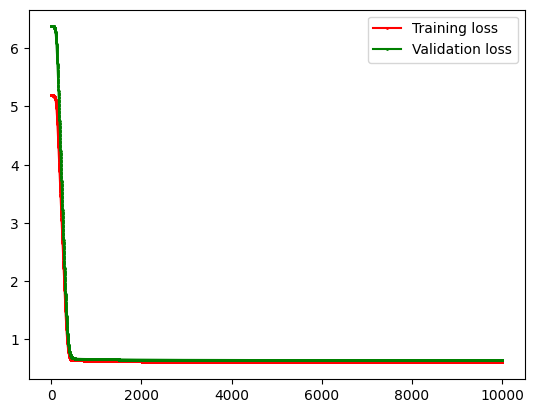

50. Training loss: 5.495224602439559, Val loss:5.962055508671761
100. Training loss: 5.370340363323662, Val loss:5.872295632221887
150. Training loss: 4.647989208460331, Val loss:5.114071113800256
200. Training loss: 3.6049497376571717, Val loss:3.96900398861492
250. Training loss: 2.580272575239953, Val loss:2.839413980289173
300. Training loss: 1.6210023274921637, Val loss:1.7819995580771908
350. Training loss: 0.921959053210876, Val loss:1.0105347400185258
400. Training loss: 0.6745500135172252, Val loss:0.727876213826024
450. Training loss: 0.6342590014859878, Val loss:0.6731844328660123
500. Training loss: 0.6286704872051347, Val loss:0.6624850658250575
550. Training loss: 0.6271115195993511, Val loss:0.6593064882016613
600. Training loss: 0.6260039520866353, Val loss:0.6577676954800589
650. Training loss: 0.6249703720848208, Val loss:0.6566927451082554
700. Training loss: 0.6239726485230994, Val loss:0.6557786448935801
750. Training loss: 0.6230066364394542, Val loss:0.6549346813

6900. Training loss: 0.592142834469106, Val loss:0.6299359788950813
6950. Training loss: 0.5921120353459803, Val loss:0.6299136689361013
7000. Training loss: 0.5920819849791317, Val loss:0.629891908079328
7050. Training loss: 0.5920526642640406, Val loss:0.6298706817806163
7100. Training loss: 0.5920240546144007, Val loss:0.6298499759139821
7150. Training loss: 0.5919961379470119, Val loss:0.629829776758554
7200. Training loss: 0.5919688966671458, Val loss:0.6298100709859611
7250. Training loss: 0.5919423136543751, Val loss:0.6297908456481454
7300. Training loss: 0.5919163722488445, Val loss:0.6297720881655801
7350. Training loss: 0.591891056237972, Val loss:0.629753786315882
7400. Training loss: 0.5918663498435651, Val loss:0.6297359282228027
7450. Training loss: 0.5918422377093381, Val loss:0.6297185023455849
7500. Training loss: 0.5918187048888156, Val loss:0.629701497468673
7550. Training loss: 0.591795736833612, Val loss:0.6296849026917618
7600. Training loss: 0.5917733193820709, 

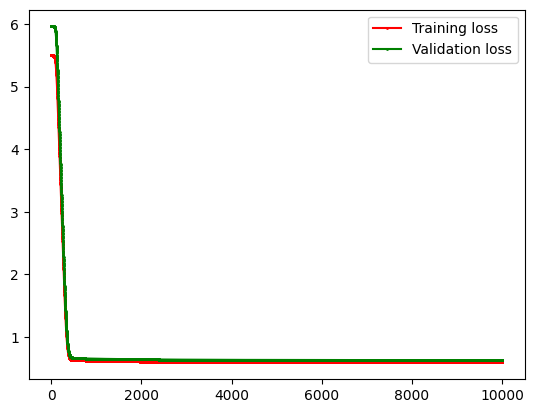

50. Training loss: 5.444509823440606, Val loss:5.139704404034276
100. Training loss: 5.327426507980566, Val loss:5.003019906119099
150. Training loss: 4.63601677077205, Val loss:4.290718203671797
200. Training loss: 3.611625667861842, Val loss:3.3302973749485685
250. Training loss: 2.601760047743182, Val loss:2.378930374030871
300. Training loss: 1.653602284954434, Val loss:1.4891955711271625
350. Training loss: 0.9496998020171443, Val loss:0.8445868485238034
400. Training loss: 0.6891751561416284, Val loss:0.6262616087508104
450. Training loss: 0.6452713125258194, Val loss:0.5992451618876373
500. Training loss: 0.6393276863268438, Val loss:0.5992975029552853
550. Training loss: 0.6378692273890378, Val loss:0.6003349094418814
600. Training loss: 0.6369080588082178, Val loss:0.6007485124826333
650. Training loss: 0.6360194502554484, Val loss:0.6008640299443561
700. Training loss: 0.6351605847053329, Val loss:0.6008784439290181
750. Training loss: 0.6343271740456488, Val loss:0.600864702

8000. Training loss: 0.6050091423484216, Val loss:0.6083360145260814
8050. Training loss: 0.6049872617383006, Val loss:0.6083564187244598
8100. Training loss: 0.604965853710412, Val loss:0.6083764651694831
8150. Training loss: 0.6049449076634554, Val loss:0.6083961596379284
8200. Training loss: 0.6049244132475576, Val loss:0.6084155078334561
8250. Training loss: 0.6049043603578296, Val loss:0.6084345153866358
8300. Training loss: 0.6048847391281044, Val loss:0.6084531878550264
8350. Training loss: 0.6048655399248519, Val loss:0.6084715307233005
8400. Training loss: 0.6048467533412645, Val loss:0.6084895494034169
8450. Training loss: 0.6048283701915069, Val loss:0.6085072492348363
8500. Training loss: 0.6048103815051276, Val loss:0.6085246354847748
8550. Training loss: 0.6047927785216248, Val loss:0.6085417133484968
8600. Training loss: 0.6047755526851641, Val loss:0.6085584879496446
8650. Training loss: 0.6047586956394396, Val loss:0.6085749643405967
8700. Training loss: 0.604742199222

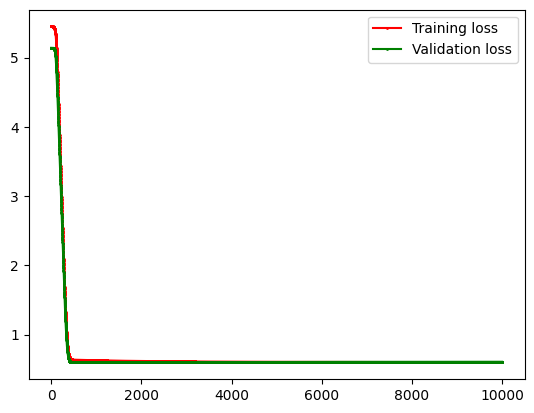


================ learning_rate = 0.01 ================
50. Training loss: 5.25871990783923, Val loss:6.082478136515766
100. Training loss: 3.626830922570286, Val loss:4.26399922880215
150. Training loss: 1.7243788291222717, Val loss:2.02912226477887
200. Training loss: 0.6913531182217112, Val loss:0.7890161476477546
250. Training loss: 0.6282903429237854, Val loss:0.6809725225137339
300. Training loss: 0.6257630454474806, Val loss:0.6733529179372252
350. Training loss: 0.6240487407823804, Val loss:0.6713568936470017
400. Training loss: 0.6224406360504943, Val loss:0.6699600069785774
450. Training loss: 0.6209287049493721, Val loss:0.6687033173771757
500. Training loss: 0.6195070243690763, Val loss:0.6675351920962608
550. Training loss: 0.6181697679063989, Val loss:0.6664452426290384
600. Training loss: 0.6169114739643208, Val loss:0.6654276278721103
650. Training loss: 0.6157270546834527, Val loss:0.6644773059827571
700. Training loss: 0.6146117729982813, Val loss:0.6635896307083095
7

8300. Training loss: 0.5948166649206318, Val loss:0.6502133843610992
8350. Training loss: 0.5948159424169953, Val loss:0.6502131010225242
8400. Training loss: 0.5948152511328616, Val loss:0.6502128288571114
8450. Training loss: 0.5948145897076594, Val loss:0.6502125673910621
8500. Training loss: 0.5948139568406214, Val loss:0.6502123161721436
8550. Training loss: 0.5948133512881315, Val loss:0.650212074768646
8600. Training loss: 0.5948127718611909, Val loss:0.6502118427683922
8650. Training loss: 0.5948122174229976, Val loss:0.6502116197777988
8700. Training loss: 0.594811686886634, Val loss:0.6502114054209829
8750. Training loss: 0.5948111792128589, Val loss:0.6502111993389154
8800. Training loss: 0.5948106934079972, Val loss:0.6502110011886156
8850. Training loss: 0.5948102285219246, Val loss:0.6502108106423881
8900. Training loss: 0.5948097836461425, Val loss:0.6502106273870953
8950. Training loss: 0.5948093579119386, Val loss:0.6502104511234689
9000. Training loss: 0.5948089504886

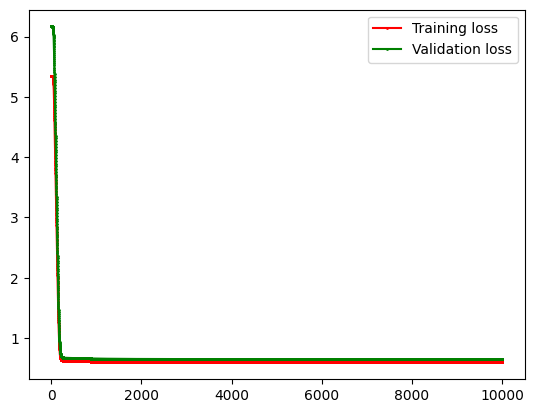

50. Training loss: 5.285500498687748, Val loss:5.244482750413497
100. Training loss: 3.6302611754306966, Val loss:3.61871831099997
150. Training loss: 1.7138214896911863, Val loss:1.6917705594324544
200. Training loss: 0.6984773651475914, Val loss:0.7007587645034954
250. Training loss: 0.637469485141419, Val loss:0.6472942685133339
300. Training loss: 0.6345491673988047, Val loss:0.6453446053295357
350. Training loss: 0.6324704505241786, Val loss:0.6438426386849374
400. Training loss: 0.6305181700725454, Val loss:0.6424184661483281
450. Training loss: 0.6286802388228584, Val loss:0.6410892327525427
500. Training loss: 0.6269495643091634, Val loss:0.639851079483533
550. Training loss: 0.6253192616474911, Val loss:0.6386979210815861
600. Training loss: 0.623782886513191, Val loss:0.6376238533810985
650. Training loss: 0.6223344376362364, Val loss:0.6366233614137953
700. Training loss: 0.620968328789638, Val loss:0.6356913138938627
750. Training loss: 0.61967935941612, Val loss:0.63482293

7000. Training loss: 0.5956655504274885, Val loss:0.6227302782868873
7050. Training loss: 0.5956616021727604, Val loss:0.622730369918277
7100. Training loss: 0.5956578146067558, Val loss:0.6227304675358755
7150. Training loss: 0.5956541811072532, Val loss:0.6227305704173025
7200. Training loss: 0.5956506953291443, Val loss:0.6227306778938809
7250. Training loss: 0.5956473511926099, Val loss:0.6227307893471666
7300. Training loss: 0.5956441428718122, Val loss:0.6227309042056913
7350. Training loss: 0.5956410647840823, Val loss:0.6227310219419063
7400. Training loss: 0.5956381115795794, Val loss:0.6227311420693112
7450. Training loss: 0.595635278131402, Val loss:0.6227312641397619
7500. Training loss: 0.5956325595261275, Val loss:0.6227313877409417
7550. Training loss: 0.5956299510547644, Val loss:0.6227315124939897
7600. Training loss: 0.5956274482040971, Val loss:0.6227316380512755
7650. Training loss: 0.5956250466484045, Val loss:0.6227317640943097
7700. Training loss: 0.5956227422415

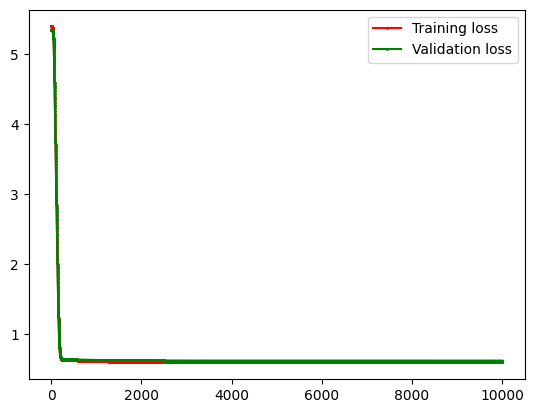

50. Training loss: 5.111909979711767, Val loss:6.266027485433754
100. Training loss: 3.637752756993083, Val loss:4.437632175254725
150. Training loss: 1.8086275219292889, Val loss:2.182043329854915
200. Training loss: 0.7260556943673827, Val loss:0.8228230279862012
250. Training loss: 0.6448282645449235, Val loss:0.6779670953913806
300. Training loss: 0.6417682927419385, Val loss:0.6676409868507704
350. Training loss: 0.6397829964185294, Val loss:0.6653562761349328
400. Training loss: 0.6379191151995085, Val loss:0.6639029717735369
450. Training loss: 0.6361649339527381, Val loss:0.6626187331787402
500. Training loss: 0.6345138663904244, Val loss:0.6614312213667188
550. Training loss: 0.6329593292900354, Val loss:0.6603275907671315
600. Training loss: 0.6314951373851481, Val loss:0.6593013917317948
650. Training loss: 0.6301155243985708, Val loss:0.6583471751025574
700. Training loss: 0.6288151185271993, Val loss:0.6574599235200347
750. Training loss: 0.6275889150436921, Val loss:0.656

7250. Training loss: 0.6050674468774864, Val loss:0.6461425666035797
7300. Training loss: 0.6050645172613919, Val loss:0.6461435811695336
7350. Training loss: 0.6050617062354602, Val loss:0.6461445677254334
7400. Training loss: 0.6050590089389809, Val loss:0.6461455268158761
7450. Training loss: 0.6050564207136004, Val loss:0.6461464589908177
7500. Training loss: 0.6050539370947229, Val loss:0.6461473648040273
7550. Training loss: 0.6050515538032876, Val loss:0.6461482448116741
7600. Training loss: 0.6050492667379052, Val loss:0.646149099571033
7650. Training loss: 0.605047071967336, Val loss:0.6461499296393068
7700. Training loss: 0.6050449657232954, Val loss:0.6461507355725494
7750. Training loss: 0.6050429443935705, Val loss:0.6461515179246905
7800. Training loss: 0.6050410045154381, Val loss:0.646152277246648
7850. Training loss: 0.6050391427693622, Val loss:0.6461530140855284
7900. Training loss: 0.6050373559729686, Val loss:0.6461537289839023
7950. Training loss: 0.60503564107527

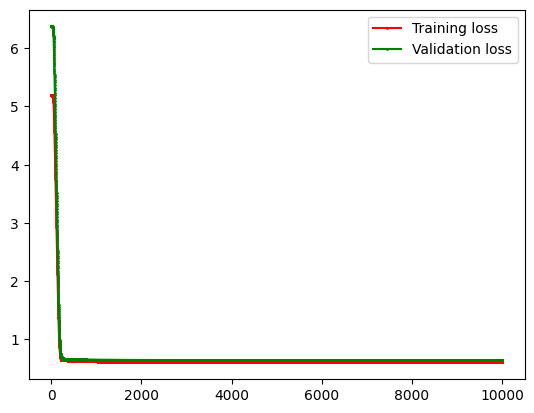

50. Training loss: 5.377240875202837, Val loss:5.872171886822211
100. Training loss: 3.624987989209741, Val loss:3.968174090439176
150. Training loss: 1.6372103740127915, Val loss:1.7803172288860776
200. Training loss: 0.6752202660197101, Val loss:0.7263510347127815
250. Training loss: 0.6286697921959465, Val loss:0.6623382049311203
300. Training loss: 0.6260188005560777, Val loss:0.6577449851855022
350. Training loss: 0.6239863971866174, Val loss:0.6557717324722052
400. Training loss: 0.6220836212284934, Val loss:0.6541268583748121
450. Training loss: 0.6202993827257706, Val loss:0.6526095947242487
500. Training loss: 0.6186258904049377, Val loss:0.6511932274651943
550. Training loss: 0.6170557222181566, Val loss:0.6498689500803796
600. Training loss: 0.6155819637638922, Val loss:0.6486302215232211
650. Training loss: 0.6141981921820693, Val loss:0.6474711362820325
700. Training loss: 0.6128984420246262, Val loss:0.6463862286632944
750. Training loss: 0.6116771716042642, Val loss:0.64

6700. Training loss: 0.5908966435678064, Val loss:0.6290288832545611
6750. Training loss: 0.5908937034483183, Val loss:0.6290266109939383
6800. Training loss: 0.590890892484042, Val loss:0.6290244340791374
6850. Training loss: 0.5908882049154628, Val loss:0.6290223484033045
6900. Training loss: 0.5908856352449706, Val loss:0.629020350042536
6950. Training loss: 0.5908831782246428, Val loss:0.6290184352473653
7000. Training loss: 0.5908808288446136, Val loss:0.6290166004346697
7050. Training loss: 0.5908785823220063, Val loss:0.629014842179972
7100. Training loss: 0.5908764340903937, Val loss:0.6290131572101197
7150. Training loss: 0.5908743797897671, Val loss:0.6290115423963191
7200. Training loss: 0.5908724152569823, Val loss:0.6290099947475067
7250. Training loss: 0.5908705365166623, Val loss:0.6290085114040436
7300. Training loss: 0.5908687397725354, Val loss:0.6290070896317097
7350. Training loss: 0.5908670213991807, Val loss:0.6290057268159902
7400. Training loss: 0.59086537793416

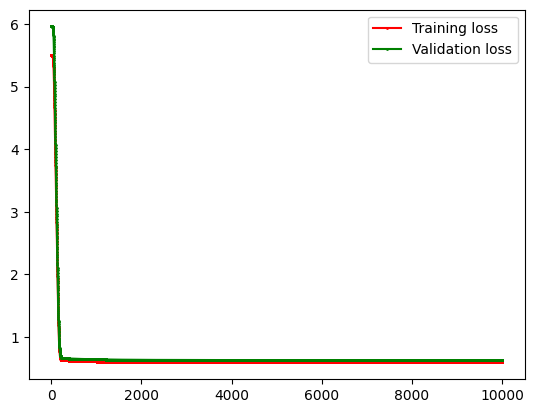

50. Training loss: 5.333211296849024, Val loss:5.00287260245607
100. Training loss: 3.6313699969466517, Val loss:3.3295985452383623
150. Training loss: 1.6697346305092804, Val loss:1.4878150730223056
200. Training loss: 0.6899488563593522, Val loss:0.6253152612219439
250. Training loss: 0.6393235005446148, Val loss:0.5993418153616439
300. Training loss: 0.6369209954313508, Val loss:0.6007597831618805
350. Training loss: 0.6351727366389047, Val loss:0.6008771710899307
400. Training loss: 0.6335294115500455, Val loss:0.6008440103967985
450. Training loss: 0.6319816589799927, Val loss:0.6008218308997122
500. Training loss: 0.6305236131006574, Val loss:0.6008245736505143
550. Training loss: 0.6291495853543912, Val loss:0.6008510331675475
600. Training loss: 0.6278542464623602, Val loss:0.6008986981210137
650. Training loss: 0.6266326266721165, Val loss:0.6009651322463048
700. Training loss: 0.6254800933649403, Val loss:0.6010480972225007
750. Training loss: 0.6243923277839729, Val loss:0.6

6600. Training loss: 0.6040886272847604, Val loss:0.609298571911682
6650. Training loss: 0.6040838442527698, Val loss:0.6093045324741719
6700. Training loss: 0.6040792554170507, Val loss:0.6093102732952086
6750. Training loss: 0.6040748527861641, Val loss:0.6093158024038138
6800. Training loss: 0.6040706287031369, Val loss:0.609321127540559
6850. Training loss: 0.6040665758311408, Val loss:0.6093262561675774
6900. Training loss: 0.6040626871398048, Val loss:0.609331195478252
6950. Training loss: 0.6040589558921327, Val loss:0.6093359524065924
7000. Training loss: 0.6040553756319945, Val loss:0.6093405336363072
7050. Training loss: 0.6040519401721702, Val loss:0.6093449456095789
7100. Training loss: 0.6040486435829159, Val loss:0.6093491945355509
7150. Training loss: 0.6040454801810301, Val loss:0.6093532863985356
7200. Training loss: 0.6040424445193994, Val loss:0.6093572269659465
7250. Training loss: 0.604039531376998, Val loss:0.6093610217959696
7300. Training loss: 0.604036735749323

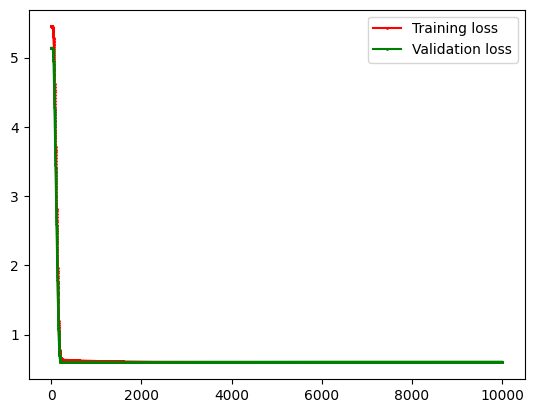


================ learning_rate = 0.1 ================
50. Training loss: 0.6196669253349809, Val loss:0.6674774122345802
100. Training loss: 0.609200817968432, Val loss:0.6593031211398568
150. Training loss: 0.6033511354916357, Val loss:0.6551183355143717
200. Training loss: 0.5999770990166431, Val loss:0.6529228496414221
250. Training loss: 0.5979803430870506, Val loss:0.6517426525379404
300. Training loss: 0.5967748724925583, Val loss:0.651093423895227
350. Training loss: 0.5960361031906078, Val loss:0.6507285420210506
400. Training loss: 0.5955782786240692, Val loss:0.6505193628065238
450. Training loss: 0.5952922128052409, Val loss:0.6503972127464424
500. Training loss: 0.5951123692821595, Val loss:0.6503246335473091
550. Training loss: 0.5949987797236332, Val loss:0.6502807855732178
600. Training loss: 0.5949267771409767, Val loss:0.6502538640751193
650. Training loss: 0.5948810031562731, Val loss:0.6502370709958922
700. Training loss: 0.5948518324090719, Val loss:0.6502264311518

6200. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6250. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6300. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6350. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6400. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6450. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6500. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6550. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6600. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6650. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6700. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6750. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6800. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6850. Training loss: 0.5947997956645575, Val loss:0.6502057276778576
6900. Training loss: 0.59479979566

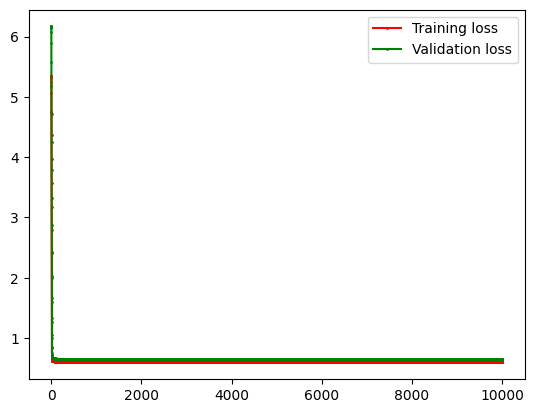

50. Training loss: 0.627152307868036, Val loss:0.6397783512849016
100. Training loss: 0.6143086374394109, Val loss:0.6312274691426231
150. Training loss: 0.6069922532048705, Val loss:0.6269994315909629
200. Training loss: 0.6026770134548605, Val loss:0.6248837956579083
250. Training loss: 0.6000599791760829, Val loss:0.6238142823440075
300. Training loss: 0.598438638933305, Val loss:0.6232702346250075
350. Training loss: 0.5974179997650747, Val loss:0.6229933891393352
400. Training loss: 0.596767830474741, Val loss:0.6228535938692735
450. Training loss: 0.596349966729096, Val loss:0.6227843413826282
500. Training loss: 0.5960795921772505, Val loss:0.62275128654617
550. Training loss: 0.5959037339554006, Val loss:0.6227365855450333
600. Training loss: 0.5957888752714547, Val loss:0.622730963852941
650. Training loss: 0.5957136013314225, Val loss:0.6227296331857548
700. Training loss: 0.5956641275838835, Val loss:0.622730161391772
750. Training loss: 0.5956315297736732, Val loss:0.622731

7300. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7350. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7400. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7450. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7500. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7550. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7600. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7650. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7700. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7750. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7800. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7850. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7900. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
7950. Training loss: 0.5955675024530322, Val loss:0.6227374789000183
8000. Training loss: 0.59556750245

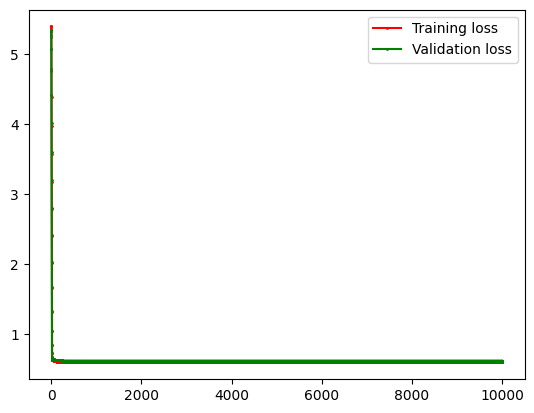

50. Training loss: 0.6347093779642817, Val loss:0.6613650636557399
100. Training loss: 0.6224912644272537, Val loss:0.6532434220572568
150. Training loss: 0.6155833232620009, Val loss:0.6493464155194479
200. Training loss: 0.6115439084099444, Val loss:0.6474951251983122
250. Training loss: 0.6091140948702538, Val loss:0.6466348466178644
300. Training loss: 0.6076190315386751, Val loss:0.6462530368134188
350. Training loss: 0.6066827898992554, Val loss:0.6460994331703521
400. Training loss: 0.6060885501910286, Val loss:0.6460516466332444
450. Training loss: 0.6057074988604862, Val loss:0.6460501332620713
500. Training loss: 0.605461233584432, Val loss:0.6460663991986101
550. Training loss: 0.6053011125194311, Val loss:0.6460872914364106
600. Training loss: 0.6051965060003981, Val loss:0.646107172536057
650. Training loss: 0.6051279051406809, Val loss:0.6461240073264527
700. Training loss: 0.6050827747386421, Val loss:0.646137411068193
750. Training loss: 0.6050530055968696, Val loss:0.6

6500. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6550. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6600. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6650. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6700. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6750. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6800. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6850. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6900. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
6950. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
7000. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
7050. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
7100. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
7150. Training loss: 0.6049943164578749, Val loss:0.6461749389870902
7200. Training loss: 0.60499431645

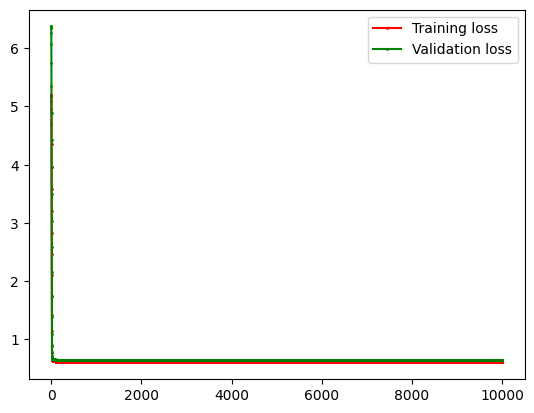

50. Training loss: 0.6188079984695959, Val loss:0.65111114188771
100. Training loss: 0.6066388873651312, Val loss:0.6411015226321032
150. Training loss: 0.6000058510094346, Val loss:0.6358361258723322
200. Training loss: 0.5962730605529298, Val loss:0.6329715273722275
250. Training loss: 0.594115173479411, Val loss:0.6313619615550018
300. Training loss: 0.5928400185651734, Val loss:0.6304307025670433
350. Training loss: 0.5920730677141481, Val loss:0.6298779663863313
400. Training loss: 0.5916052374522451, Val loss:0.6295427452033752
450. Training loss: 0.5913166531718458, Val loss:0.629335790039006
500. Training loss: 0.5911370426126398, Val loss:0.6292061600324695
550. Training loss: 0.5910244536192885, Val loss:0.6291240106597981
600. Training loss: 0.5909534680729998, Val loss:0.6290714585388141
650. Training loss: 0.5909085009181622, Val loss:0.6290375826340807
700. Training loss: 0.5908799040401816, Val loss:0.6290156086205252
750. Training loss: 0.5908616581461079, Val loss:0.62

6900. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
6950. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7000. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7050. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7100. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7150. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7200. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7250. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7300. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7350. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7400. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7450. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7500. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7550. Training loss: 0.5908289259442573, Val loss:0.6289735913587663
7600. Training loss: 0.59082892594

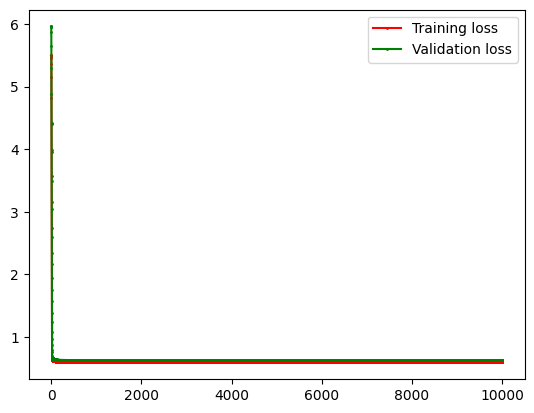

50. Training loss: 0.6306888986377299, Val loss:0.6007705581878958
100. Training loss: 0.6198543057916124, Val loss:0.601768603186809
150. Training loss: 0.6136700389221018, Val loss:0.6034053840757173
200. Training loss: 0.6100184203319478, Val loss:0.6049576085833068
250. Training loss: 0.6078011481612252, Val loss:0.6062155338510271
300. Training loss: 0.6064251152409954, Val loss:0.6071651896587014
350. Training loss: 0.6055569356370828, Val loss:0.6078555123032456
400. Training loss: 0.6050023921175249, Val loss:0.6083463979100683
450. Training loss: 0.6046449235910766, Val loss:0.6086907872726256
500. Training loss: 0.6044129041930161, Val loss:0.6089303396406824
550. Training loss: 0.6042615158186389, Val loss:0.6090960419277284
600. Training loss: 0.6041623295210498, Val loss:0.6092102358465095
650. Training loss: 0.6040971274513043, Val loss:0.6092887341224137
700. Training loss: 0.6040541455174334, Val loss:0.609342600137638
750. Training loss: 0.6040257426994654, Val loss:0.

6350. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6400. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6450. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6500. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6550. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6600. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6650. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6700. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6750. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6800. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6850. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6900. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
6950. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
7000. Training loss: 0.6039694718098002, Val loss:0.6094594479874215
7050. Training loss: 0.60396947180

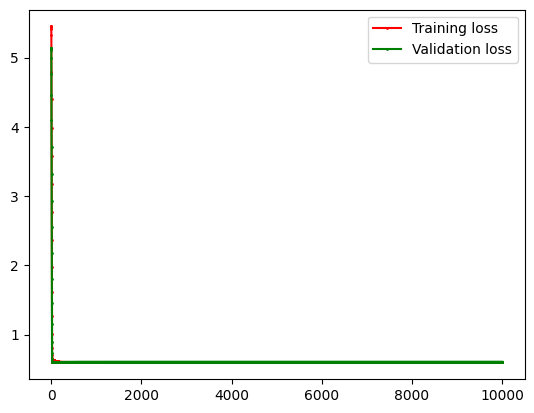


================ learning_rate = 0.5 ================
50. Training loss: 0.7847443116917887, Val loss:0.7190823481515051
100. Training loss: 0.7783243195229438, Val loss:0.7161554632516675
150. Training loss: 0.7776245940619578, Val loss:0.715879167896097
200. Training loss: 0.7775518087484325, Val loss:0.7158533413483726
250. Training loss: 0.7775440917629837, Val loss:0.71585076562997
300. Training loss: 0.7775432488328432, Val loss:0.715850472949756
350. Training loss: 0.7775431537280092, Val loss:0.715850433488817
400. Training loss: 0.7775431426315116, Val loss:0.7158504273201622
450. Training loss: 0.7775431412925088, Val loss:0.7158504262703415
500. Training loss: 0.7775431411256422, Val loss:0.7158504260859931
550. Training loss: 0.7775431411042325, Val loss:0.7158504260535569
600. Training loss: 0.7775431411014164, Val loss:0.715850426047908
650. Training loss: 0.777543141101039, Val loss:0.715850426046938
700. Training loss: 0.7775431411009873, Val loss:0.7158504260467741
75

6550. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6600. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6650. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6700. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6750. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6800. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6850. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6900. Training loss: 0.7775431411009793, Val loss:0.715850426046741
6950. Training loss: 0.7775431411009793, Val loss:0.715850426046741
7000. Training loss: 0.7775431411009793, Val loss:0.715850426046741
7050. Training loss: 0.7775431411009793, Val loss:0.715850426046741
7100. Training loss: 0.7775431411009793, Val loss:0.715850426046741
7150. Training loss: 0.7775431411009793, Val loss:0.715850426046741
7200. Training loss: 0.7775431411009793, Val loss:0.715850426046741
7250. Training loss: 0.7775431411009793, Val los

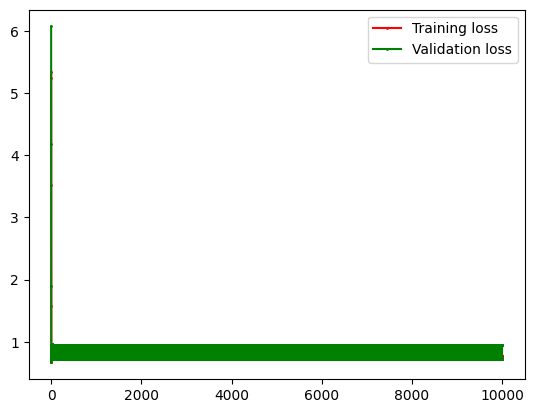

50. Training loss: 0.7653738324808158, Val loss:0.761053964972758
100. Training loss: 0.757867346290385, Val loss:0.7552160905252533
150. Training loss: 0.7570045377215896, Val loss:0.7545695309403461
200. Training loss: 0.756905188830925, Val loss:0.7544967598472277
250. Training loss: 0.756893138363254, Val loss:0.7544881627477379
300. Training loss: 0.7568916047569658, Val loss:0.7544870998809611
350. Training loss: 0.7568914020446746, Val loss:0.7544869634421862
400. Training loss: 0.7568913744757023, Val loss:0.7544869454097981
450. Training loss: 0.7568913706475293, Val loss:0.7544869429758683
500. Training loss: 0.7568913701080316, Val loss:0.7544869426427772
550. Training loss: 0.7568913700312139, Val loss:0.7544869425968431
600. Training loss: 0.7568913700201989, Val loss:0.7544869425904934
650. Training loss: 0.7568913700186123, Val loss:0.7544869425896177
700. Training loss: 0.7568913700183828, Val loss:0.7544869425894974
750. Training loss: 0.7568913700183497, Val loss:0.75

6350. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6400. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6450. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6500. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6550. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6600. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6650. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6700. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6750. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6800. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6850. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6900. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
6950. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
7000. Training loss: 0.7568913700183442, Val loss:0.7544869425894788
7050. Training loss: 0.75689137001

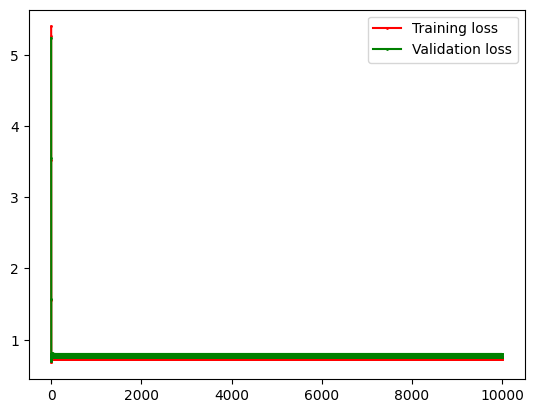

50. Training loss: 0.7981481333751547, Val loss:0.6802013775662417
100. Training loss: 0.7909145297375941, Val loss:0.6769191172163025
150. Training loss: 0.7901035039895443, Val loss:0.6766447017098576
200. Training loss: 0.7900110785559514, Val loss:0.6766240354706132
250. Training loss: 0.7899999353357534, Val loss:0.6766228711513024
300. Training loss: 0.789998526467679, Val loss:0.6766228839024911
350. Training loss: 0.7899983417768217, Val loss:0.6766229042634352
400. Training loss: 0.7899983168839492, Val loss:0.676622909146804
450. Training loss: 0.7899983134553646, Val loss:0.6766229100604525
500. Training loss: 0.7899983129750007, Val loss:0.6766229102152611
550. Training loss: 0.7899983129067845, Val loss:0.6766229102401883
600. Training loss: 0.7899983128969932, Val loss:0.6766229102440854
650. Training loss: 0.7899983128955759, Val loss:0.6766229102446838
700. Training loss: 0.7899983128953695, Val loss:0.6766229102447745
750. Training loss: 0.789998312895339, Val loss:0.6

6600. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6650. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6700. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6750. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6800. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6850. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6900. Training loss: 0.789998312895334, Val loss:0.6766229102447906
6950. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7000. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7050. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7100. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7150. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7200. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7250. Training loss: 0.789998312895334, Val loss:0.6766229102447906
7300. Training loss: 0.789998312895334, Val loss

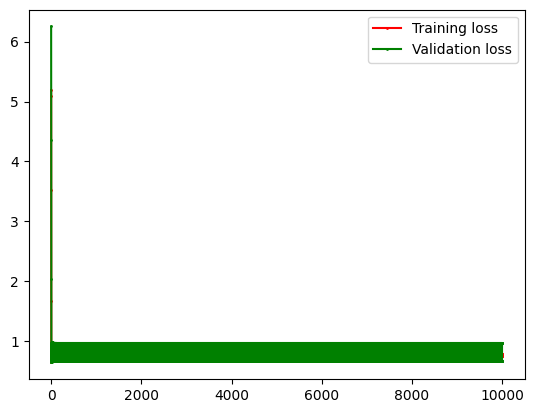

50. Training loss: 0.7736459980445248, Val loss:0.728144210158154
100. Training loss: 0.7664125120185954, Val loss:0.7211291717486991
150. Training loss: 0.7657321943084019, Val loss:0.720319917122553
200. Training loss: 0.765666155175076, Val loss:0.7202191966756927
250. Training loss: 0.7656592346646383, Val loss:0.7202058449212068
300. Training loss: 0.7656584621264699, Val loss:0.7202040050204294
350. Training loss: 0.7656583720896423, Val loss:0.7202037455047022
400. Training loss: 0.7656583613054408, Val loss:0.7202037083544189
450. Training loss: 0.7656583599924008, Val loss:0.7202037029819738
500. Training loss: 0.7656583598311463, Val loss:0.7202037021992285
550. Training loss: 0.7656583598112949, Val loss:0.7202037020845266
600. Training loss: 0.7656583598088594, Val loss:0.7202037020676408
650. Training loss: 0.7656583598085634, Val loss:0.7202037020651455
700. Training loss: 0.7656583598085283, Val loss:0.7202037020647756
750. Training loss: 0.7656583598085241, Val loss:0.7

6600. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6650. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6700. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6750. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6800. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6850. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6900. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
6950. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7000. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7050. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7100. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7150. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7200. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7250. Training loss: 0.7656583598085235, Val loss:0.7202037020647108
7300. Training loss: 0.76565835980

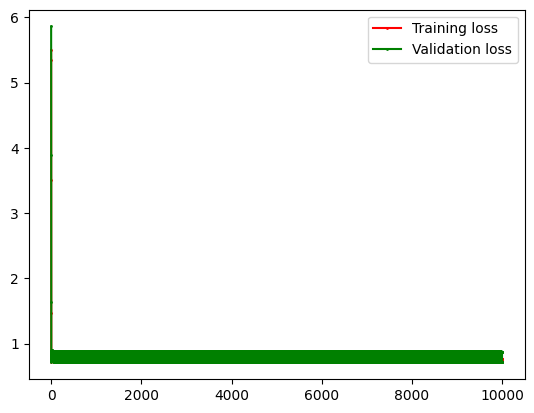

50. Training loss: 0.796815146852534, Val loss:0.7934059395018489
100. Training loss: 0.7904972513645231, Val loss:0.7919164762462252
150. Training loss: 0.7897271595026373, Val loss:0.7918137173848773
200. Training loss: 0.789636106619738, Val loss:0.7918122996799327
250. Training loss: 0.7896249187503447, Val loss:0.7918132859351494
300. Training loss: 0.7896234844701825, Val loss:0.7918135301312069
350. Training loss: 0.7896232937639847, Val loss:0.791813574015874
400. Training loss: 0.789623267647641, Val loss:0.7918135810736728
450. Training loss: 0.7896232639870556, Val loss:0.7918135821519854
500. Training loss: 0.7896232634646496, Val loss:0.7918135823125555
550. Training loss: 0.789623263389058, Val loss:0.7918135823361822
600. Training loss: 0.7896232633780034, Val loss:0.791813582339647
650. Training loss: 0.7896232633763735, Val loss:0.7918135823401566
700. Training loss: 0.7896232633761316, Val loss:0.791813582340232
750. Training loss: 0.7896232633760956, Val loss:0.79181

7300. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7350. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7400. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7450. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7500. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7550. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7600. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7650. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7700. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7750. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7800. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7850. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7900. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
7950. Training loss: 0.7896232633760892, Val loss:0.7918135823402453
8000. Training loss: 0.78962326337

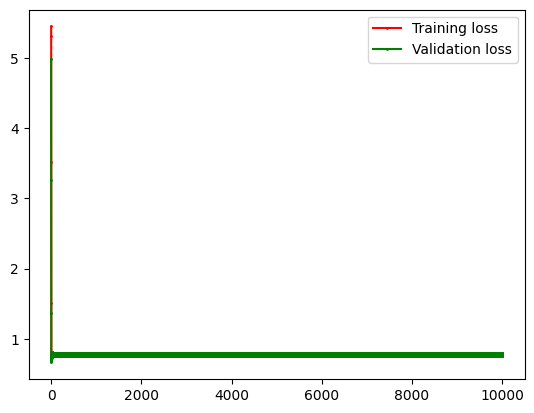

In [14]:
regs = [1.0, 2.0, 4.0, 8.0]
lr_list = [0.005, 0.01, 0.1, 0.5]
results = []


cv = KFold(n_splits=5, shuffle=True, random_state=40)

for reg in regs:
    print(f'\n================ reg_lambda = {reg} ================')
    for lr in lr_list:
        print(f'\n================ learning_rate = {lr} ================')
        seed=40
        np.random.seed(seed)
        model = LinearModel(lr=lr, n_iteration =10000, reg_type='l2', reg_lambda=reg, 
                            dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, 
                            act_fn=act_fn, grad_fn=grad_fn, random_state=seed)
        acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
        results.append((reg, lr, acc_scores.mean(), acc_scores))

In [15]:
result_df = pd.DataFrame(data=results, columns=['reg_lambda', 'learning_rate', 'mean_acc', 'acc_list'])

In [16]:
result_df

,reg_lambda,learning_rate,mean_acc,acc_list
0,1.0,0.005,0.717143,"[0.7, 0.7571428571428571, 0.7285714285714285, ..."
1,1.0,0.010,0.722857,"[0.7, 0.7857142857142857, 0.7285714285714285, ..."
2,1.0,0.100,0.722857,"[0.7142857142857143, 0.7428571428571429, 0.714..."
3,1.0,0.500,0.722857,"[0.7142857142857143, 0.7428571428571429, 0.714..."
4,2.0,0.005,0.720000,"[0.7, 0.7571428571428571, 0.7142857142857143, ..."
5,2.0,0.010,0.728571,"[0.7142857142857143, 0.7857142857142857, 0.728..."
6,2.0,0.100,0.725714,"[0.7285714285714285, 0.7714285714285715, 0.7, ..."
7,2.0,0.500,0.691429,"[0.7428571428571429, 0.7714285714285715, 0.614..."
8,4.0,0.005,0.725714,"[0.7285714285714285, 0.7428571428571429, 0.714..."
9,4.0,0.010,0.725714,"[0.7428571428571429, 0.7571428571428571, 0.7, ..."


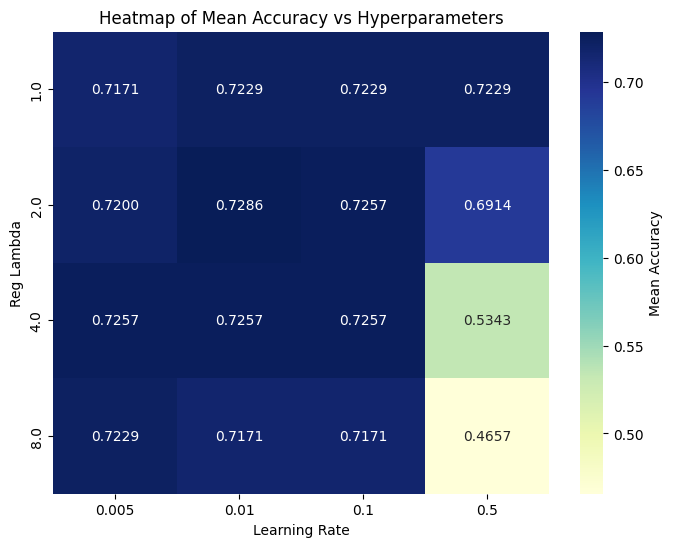

In [67]:
import seaborn as sns

heatmap_data = result_df.pivot(index='reg_lambda', columns='learning_rate', values='mean_acc')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Mean Accuracy'})

plt.title('Heatmap of Mean Accuracy vs Hyperparameters')
plt.xlabel('Learning Rate')
plt.ylabel('Reg Lambda')
plt.show()

In [87]:
heatmap_data

learning_rate,0.005,0.010,0.100,0.500
reg_lambda,,,,
1.0,0.717143,0.722857,0.722857,0.722857
2.0,0.720000,0.728571,0.725714,0.691429
4.0,0.725714,0.725714,0.725714,0.534286
8.0,0.722857,0.717143,0.717143,0.465714


### Best params evaluation

In [18]:
top2_result_df = result_df.sort_values(by='mean_acc', ascending=False).reset_index(drop=True)[:2]

In [19]:
top2_result_df

,reg_lambda,learning_rate,mean_acc,acc_list
0,2.0,0.01,0.728571,"[0.7142857142857143, 0.7857142857142857, 0.728..."
1,2.0,0.10,0.725714,"[0.7285714285714285, 0.7714285714285715, 0.7, ..."



================ reg_lambda = 2.0, learning_rate = 0.01 ================
50. Training loss: 5.327946752967027, Val loss:5.70528731276978
100. Training loss: 3.8781876200102974, Val loss:4.177217222261749
150. Training loss: 2.0055978737858755, Val loss:2.150404665710076
200. Training loss: 0.7865285880317292, Val loss:0.8281506305034363
250. Training loss: 0.6792642973657574, Val loss:0.6924060866409768
300. Training loss: 0.6732753541994332, Val loss:0.6833310653951479
350. Training loss: 0.6687797122817034, Val loss:0.6793593065882356
400. Training loss: 0.6644712350457056, Val loss:0.6759321033664547
450. Training loss: 0.6603290292308382, Val loss:0.6726846464067366
500. Training loss: 0.6563452368201808, Val loss:0.6695747122822642
550. Training loss: 0.652512417820488, Val loss:0.6665922182366082
600. Training loss: 0.6488234897770062, Val loss:0.6637306542515721
650. Training loss: 0.6452717220282392, Val loss:0.6609841612021494
700. Training loss: 0.6418507224799078, Val loss:

6100. Training loss: 0.532092013572221, Val loss:0.5838992755456294
6150. Training loss: 0.5318449661426954, Val loss:0.5837855501794738
6200. Training loss: 0.531602126586313, Val loss:0.5836743940551574
6250. Training loss: 0.5313634088740475, Val loss:0.5835657447296002
6300. Training loss: 0.5311287291265221, Val loss:0.5834595414945307
6350. Training loss: 0.5308980055486408, Val loss:0.5833557253205743
6400. Training loss: 0.530671158366586, Val loss:0.5832542388034087
6450. Training loss: 0.5304481097670823, Val loss:0.5831550261119085
6500. Training loss: 0.5302287838388322, Val loss:0.5830580329381893
6550. Training loss: 0.530013106516033, Val loss:0.5829632064494782
6600. Training loss: 0.5298010055238909, Val loss:0.5828704952417287
6650. Training loss: 0.5295924103260503, Val loss:0.5827798492949143
6700. Training loss: 0.5293872520738574, Val loss:0.582691219929929
6750. Training loss: 0.5291854635573869, Val loss:0.5826045597670286
6800. Training loss: 0.5289869791581614

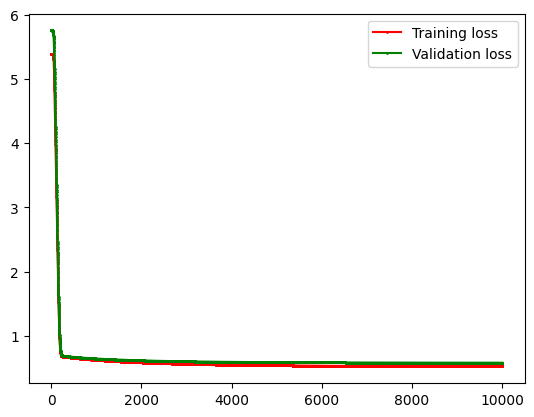

Model parameters (weights):
 [[-0.62359703]
 [ 0.35926906]
 [ 0.10961973]
 [ 0.08768591]
 [ 0.71538681]
 [ 0.36537863]
 [ 0.16925323]
 [ 0.16854582]
 [ 0.38850818]
 [ 0.24785939]
 [ 0.37086984]
 [ 0.22675091]
 [ 0.26959073]
 [-0.00174467]
 [ 0.02022446]
 [ 0.01980333]
 [ 0.14344903]
 [ 0.06401012]
 [ 0.16602163]
 [ 0.08000145]
 [ 0.28484956]
 [ 0.22777313]
 [ 0.08560235]
 [ 0.304969  ]
 [ 0.08842831]
 [ 0.61386108]
 [ 0.56767251]
 [ 0.5569392 ]
 [ 0.67651346]
 [ 0.65296   ]
 [ 0.58282126]
 [-0.34885573]
 [ 0.19856124]
 [-0.22054494]
 [-0.08357286]
 [-0.18383473]
 [ 0.0425881 ]
 [-0.29115235]
 [-0.66354191]
 [-0.07308034]
 [-0.30830608]
 [-0.08604588]
 [-0.42283646]
 [-0.21192071]
 [ 0.03133059]
 [-0.1067559 ]
 [-0.15144318]
 [-0.13548695]
 [-0.32330156]
 [-0.23808037]
 [-0.15773676]
 [-0.14583462]
 [-0.09113362]
 [-0.22583167]
 [-0.12736813]
 [-0.04209753]
 [-0.2785541 ]
 [-0.36222193]
 [-0.21963347]
 [-0.14277134]
 [-0.40765932]
 [ 0.05168522]
 [ 0.10957334]
 [-0.29820531]
 [-0.241169

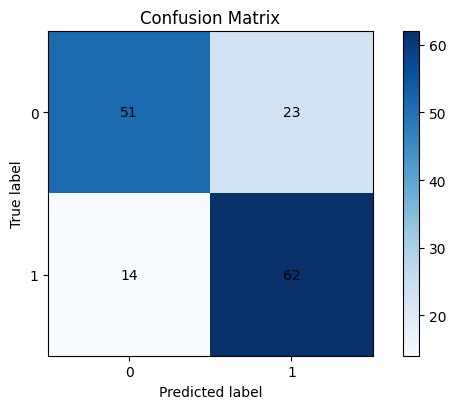


================ reg_lambda = 2.0, learning_rate = 0.1 ================
50. Training loss: 0.6569678496711399, Val loss:0.669511083223374
100. Training loss: 0.62413178856037, Val loss:0.6444709241529653
150. Training loss: 0.601019474171776, Val loss:0.6274409782773862
200. Training loss: 0.5841621931768883, Val loss:0.6154915546130558
250. Training loss: 0.5714876355260756, Val loss:0.6068797612855857
300. Training loss: 0.5617169353024724, Val loss:0.6005341592139823
350. Training loss: 0.5540301904891894, Val loss:0.5957724633573941
400. Training loss: 0.5478819145428138, Val loss:0.5921456008864935
450. Training loss: 0.542896800548072, Val loss:0.589349143210162
500. Training loss: 0.5388088839836477, Val loss:0.5871713097130216
550. Training loss: 0.5354247840288741, Val loss:0.585461415566523
600. Training loss: 0.5326007378408809, Val loss:0.5841101224966346
650. Training loss: 0.530227798628453, Val loss:0.5830367228722493
700. Training loss: 0.528222020428569, Val loss:0.58

6350. Training loss: 0.515199553215875, Val loss:0.5792895352935151
6400. Training loss: 0.5151995408614684, Val loss:0.5792895762102032
6450. Training loss: 0.5151995295870385, Val loss:0.5792896141736323
6500. Training loss: 0.5151995192976475, Val loss:0.5792896493961385
6550. Training loss: 0.5151995099067557, Val loss:0.5792896820748785
6600. Training loss: 0.5151995013354733, Val loss:0.5792897123929072
6650. Training loss: 0.51519949351188, Val loss:0.5792897405201776
6700. Training loss: 0.5151994863704041, Val loss:0.5792897666144707
6750. Training loss: 0.5151994798512591, Val loss:0.5792897908222624
6800. Training loss: 0.5151994738999293, Val loss:0.5792898132795244
6850. Training loss: 0.5151994684667015, Val loss:0.5792898341124753
6900. Training loss: 0.515199463506241, Val loss:0.5792898534382735
6950. Training loss: 0.5151994589772014, Val loss:0.579289871365664
7000. Training loss: 0.5151994548418729, Val loss:0.5792898879955792
7050. Training loss: 0.5151994510658594

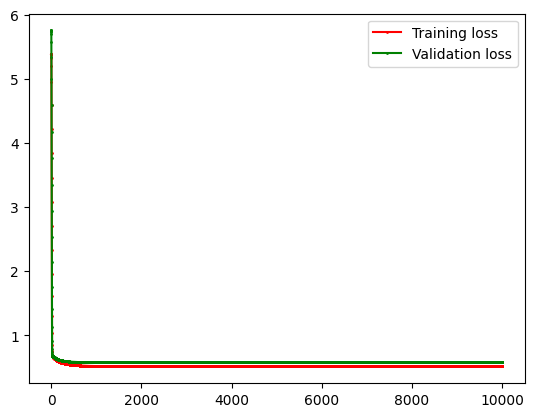

Model parameters (weights):
 [[-4.49405522e-01]
 [ 3.67848874e-01]
 [ 1.15869549e-01]
 [ 6.82787888e-02]
 [ 6.18110590e-01]
 [ 2.64161325e-01]
 [ 1.80442049e-01]
 [ 2.46564674e-01]
 [ 2.76734908e-01]
 [ 3.67338240e-01]
 [ 3.06677232e-01]
 [ 3.05728435e-01]
 [ 3.53685682e-01]
 [ 2.70831026e-02]
 [-5.78283552e-02]
 [ 7.55210055e-02]
 [ 1.43102321e-01]
 [ 1.24444846e-01]
 [ 9.33702819e-02]
 [ 1.45389328e-01]
 [ 1.90622948e-01]
 [ 2.24987337e-01]
 [ 1.57683735e-01]
 [ 2.08656404e-01]
 [ 1.64738885e-01]
 [ 6.27458913e-01]
 [ 6.38855674e-01]
 [ 6.51313384e-01]
 [ 6.58636632e-01]
 [ 6.68895569e-01]
 [ 6.53338016e-01]
 [-4.57975497e-01]
 [ 1.71897804e-01]
 [-1.73183644e-01]
 [-3.16018284e-02]
 [-2.26051821e-01]
 [ 5.41794048e-05]
 [-3.27300413e-01]
 [-7.96180018e-01]
 [-1.38822091e-01]
 [-3.40661982e-01]
 [-1.56784341e-01]
 [-4.14330511e-01]
 [-2.88541954e-01]
 [ 2.47159402e-02]
 [-1.87650729e-01]
 [-1.66915719e-01]
 [-1.35203198e-01]
 [-2.66198525e-01]
 [-2.64137131e-01]
 [-1.45897116e-01]
 [

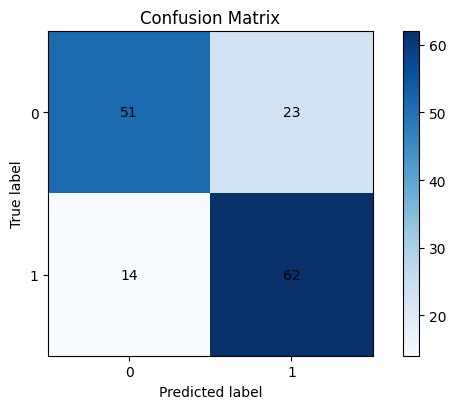

In [20]:
params = top2_result_df[['reg_lambda', 'learning_rate']].to_numpy()

for param in params:
    seed=40
    np.random.seed(seed)

    print(f'\n================ reg_lambda = {param[0]}, learning_rate = {param[1]} ================')
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train,lr=param[1], n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=param[0])
    # print model parameters
    print("Model parameters (weights):\n", model.W)
    # sum of absolute values of weights
    print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))
    
    print(f'\n================ reg_lambda = {param[0]}, learning_rate = {param[1]} ================')
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)

# Question 2: SVM

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

## Load Mobile dataset

In [22]:
mobile_df = pd.read_csv("data/mobile_price.csv")

In [23]:
mobile_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [24]:
mobile_df.shape

(2000, 21)

In [25]:
# split features and label
X = mobile_df.drop(columns=["price_range"])
y = mobile_df["price_range"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

print("Train size:", X_train.shape, y_train.shape)
print("Validation size:", X_val.shape, y_val.shape)
print("Test size:", X_test.shape, y_test.shape)

Train size: (1200, 20) (1200,)
Validation size: (400, 20) (400,)
Test size: (400, 20) (400,)


## Train SVM classifier with C = 1.0

In [26]:
svm_clf = SVC(C=1.0, random_state=42)

svm_clf.fit(X_train, y_train)

# predictions
y_train_pred = svm_clf.predict(X_train)
y_val_pred = svm_clf.predict(X_val)
y_test_pred = svm_clf.predict(X_test)

# metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
val_f1 = f1_score(y_val, y_val_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("SVM with C = 1.0")
print(f"Train Accuracy: {train_acc:.4f}, Train F1-score: {train_f1:.4f}")
print(f"Val   Accuracy: {val_acc:.4f}, Val   F1-score: {val_f1:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}, Test  F1-score: {test_f1:.4f}")

SVM with C = 1.0
Train Accuracy: 0.9500, Train F1-score: 0.9505
Val   Accuracy: 0.9475, Val   F1-score: 0.9463
Test  Accuracy: 0.9625, Test  F1-score: 0.9617


## Fine tuning parameter C

In [27]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

results = []

for c in C_values:
    model = SVC(C=c, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    results.append((c, accuracy_score(y_train, y_train_pred), accuracy_score(y_val, y_val_pred),
                   accuracy_score(y_test, y_test_pred), f1_score(y_train, y_train_pred, average='macro'),
                   f1_score(y_val, y_val_pred, average='macro'), f1_score(y_test, y_test_pred, average='macro')))

results_df = pd.DataFrame(data = results, columns = ['c', 'train_accuracy', 'val_accuracy', 'test_accuracy', 
                                                    'train_f1', 'val_f1', 'test_f1'])

In [28]:
results_df

,c,train_accuracy,val_accuracy,test_accuracy,train_f1,val_f1,test_f1
0,0.001,0.262500,0.2325,0.2300,0.103960,0.094320,0.093496
1,0.010,0.324167,0.3075,0.3000,0.218165,0.224865,0.211054
2,0.100,0.894167,0.8950,0.9000,0.895939,0.894865,0.898654
3,1.000,0.950000,0.9475,0.9625,0.950473,0.946321,0.961672
4,10.000,0.969167,0.9450,0.9700,0.969639,0.944181,0.969295
5,100.000,0.977500,0.9550,0.9700,0.977829,0.954316,0.969557
6,1000.000,0.986667,0.9500,0.9700,0.986839,0.948807,0.969212
7,10000.000,0.997500,0.9400,0.9700,0.997527,0.938914,0.969718


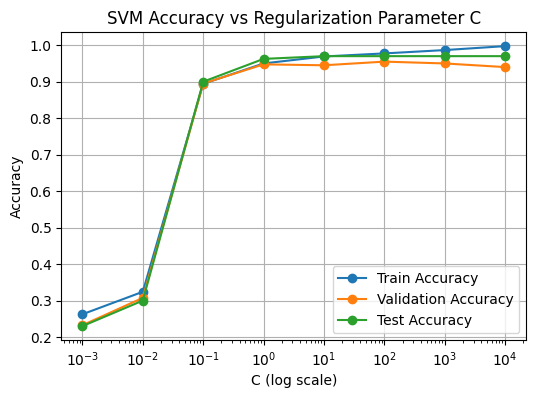

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["c"], results_df["train_accuracy"], marker='o', label="Train Accuracy")
plt.plot(results_df["c"], results_df["val_accuracy"], marker='o', label="Validation Accuracy")
plt.plot(results_df["c"], results_df["test_accuracy"], marker='o', label="Test Accuracy")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy vs Regularization Parameter C")
plt.legend()
plt.grid(True)
plt.show()

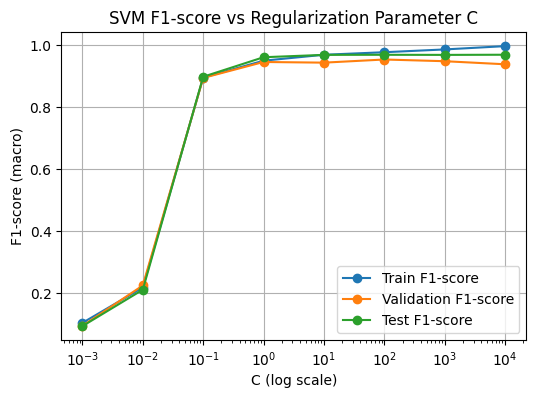

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["c"], results_df["train_f1"], marker='o', label="Train F1-score")
plt.plot(results_df["c"], results_df["val_f1"], marker='o', label="Validation F1-score")
plt.plot(results_df["c"], results_df["test_f1"], marker='o', label="Test F1-score")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("F1-score (macro)")
plt.title("SVM F1-score vs Regularization Parameter C")
plt.legend()
plt.grid(True)
plt.show()

# Question 3: Association Rule Mining

In [31]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

## Data preprocessing

In [32]:
focus_cols = ["ram", "int_memory", "px_width", "battery_power"]
filtered_df = mobile_df[mobile_df['price_range']==1][focus_cols]

In [33]:
mobile_df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [34]:
filtered_df.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 0 to 1989
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ram            500 non-null    int64
 1   int_memory     500 non-null    int64
 2   px_width       500 non-null    int64
 3   battery_power  500 non-null    int64
dtypes: int64(4)
memory usage: 19.5 KB


In [35]:
def low_high_threshold(data):
    min_val = data.min()
    value_range = data.max() - min_val
    low_threshold = min_val + 0.3 * value_range
    high_threshold = min_val + 0.7 * value_range
    return low_threshold, high_threshold

In [36]:
def categorization(val, low_th, high_th):
    if val <= low_th:
        return 'low'
    elif val <= high_th:
        return 'medium'
    else:
        return 'high'

In [37]:
for col in focus_cols:
    low_th, high_th = low_high_threshold(filtered_df[col])
    filtered_df[col] = filtered_df[col].apply(lambda x: categorization(x, low_th, high_th))
    filtered_df[col] = f'{col}_' + filtered_df[col]

## Frequent Patterns

In [38]:
dataset = filtered_df.to_numpy()

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
transaction_df = pd.DataFrame(te_ary, columns=te.columns_)

In [39]:
frequent_itemsets = fpgrowth(transaction_df, min_support=0.3, use_colnames=True)

In [40]:
frequent_itemsets.sort_values(by=['support'], ascending=False)

,support,itemsets
2,0.682,frozenset({ram_medium})
3,0.416,frozenset({px_width_medium})
5,0.414,frozenset({battery_power_medium})
4,0.412,frozenset({int_memory_medium})
7,0.318,"frozenset({ram_medium, battery_power_medium})"
0,0.316,frozenset({int_memory_low})
1,0.308,frozenset({battery_power_low})
6,0.306,"frozenset({ram_medium, px_width_medium})"


## Association rules

In [41]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

In [42]:
rules_filtered = rules[
    (rules["support"] >= 0.3) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 0.8)
]

In [43]:
rules_filtered

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({ram_medium}),frozenset({px_width_medium}),0.682,0.416,0.306,0.448680,1.078559,1.0,0.022288,1.059277,0.229046,0.386364,0.055960,0.592129
1,frozenset({px_width_medium}),frozenset({ram_medium}),0.416,0.682,0.306,0.735577,1.078559,1.0,0.022288,1.202618,0.124720,0.386364,0.168481,0.592129
2,frozenset({ram_medium}),frozenset({battery_power_medium}),0.682,0.414,0.318,0.466276,1.126270,1.0,0.035652,1.097945,0.352557,0.408740,0.089208,0.617196
3,frozenset({battery_power_medium}),frozenset({ram_medium}),0.414,0.682,0.318,0.768116,1.126270,1.0,0.035652,1.371375,0.191319,0.408740,0.270805,0.617196


# Question 4: PCA and K-means

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

## Z-score Standardization

In [45]:
X = mobile_df.drop(columns=["price_range"])
y = mobile_df["price_range"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Standardized feature shape:", X_scaled.shape)

Original feature shape: (2000, 20)
Standardized feature shape: (2000, 20)


## PCA

In [46]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (2000, 2)
Explained variance ratio: [0.08386288 0.08112475]
Total explained variance: 0.1649876289428196


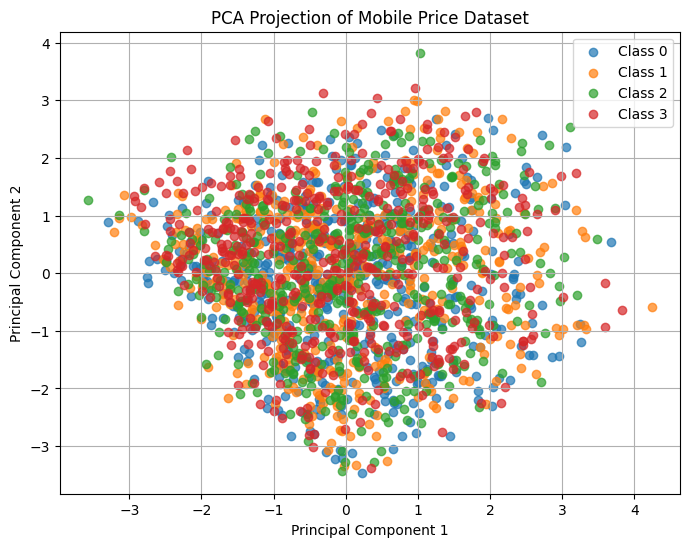

In [47]:
plt.figure(figsize=(8, 6))

for label in sorted(y.unique()):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=f"Class {label}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Mobile Price Dataset")
plt.legend()
plt.grid(True)
plt.show()

## K-means with original features

In [48]:
kmeans_all = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_all = kmeans_all.fit_predict(X_scaled)

ari_all = adjusted_rand_score(y, cluster_all)

print("Adjusted Rand Score using all standardized features:", ari_all)

Adjusted Rand Score using all standardized features: 0.005961567406388764


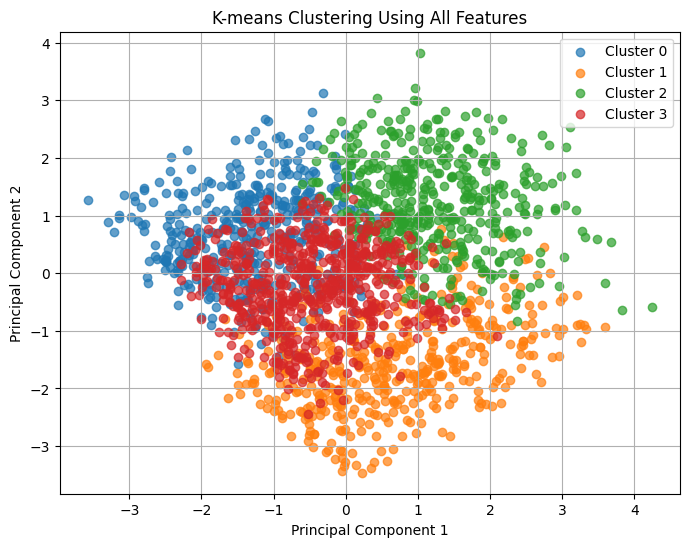

In [49]:
plt.figure(figsize=(8, 6))

for cluster in sorted(np.unique(cluster_all)):
    plt.scatter(
        X_pca[cluster_all == cluster, 0],
        X_pca[cluster_all == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering Using All Features")
plt.legend()
plt.grid(True)
plt.show()

## K-means with reduced features

In [50]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_pca = kmeans_pca.fit_predict(X_pca)

ari_pca = adjusted_rand_score(y, cluster_pca)

print("Adjusted Rand Score using 2D PCA features:", ari_pca)

Adjusted Rand Score using 2D PCA features: 0.001694571795386637


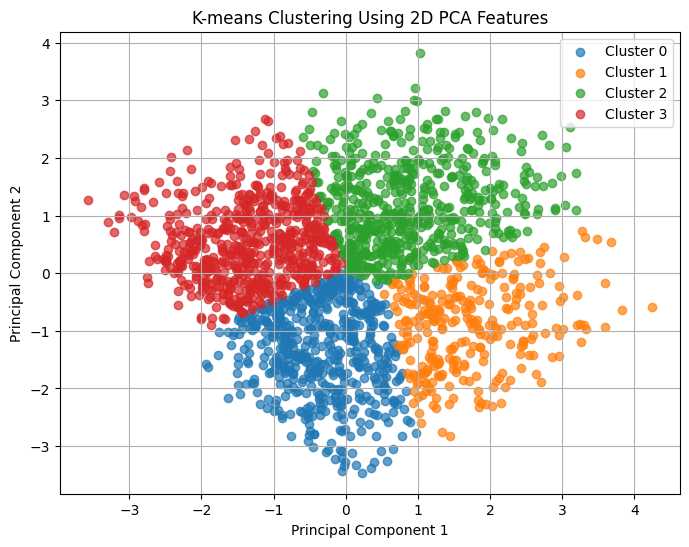

In [51]:
plt.figure(figsize=(8, 6))

for cluster in sorted(np.unique(cluster_pca)):
    plt.scatter(
        X_pca[cluster_pca == cluster, 0],
        X_pca[cluster_pca == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering Using 2D PCA Features")
plt.legend()
plt.grid(True)
plt.show()

# Question 5: K-means with Association Rule

## EDA

In [52]:
mobile_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

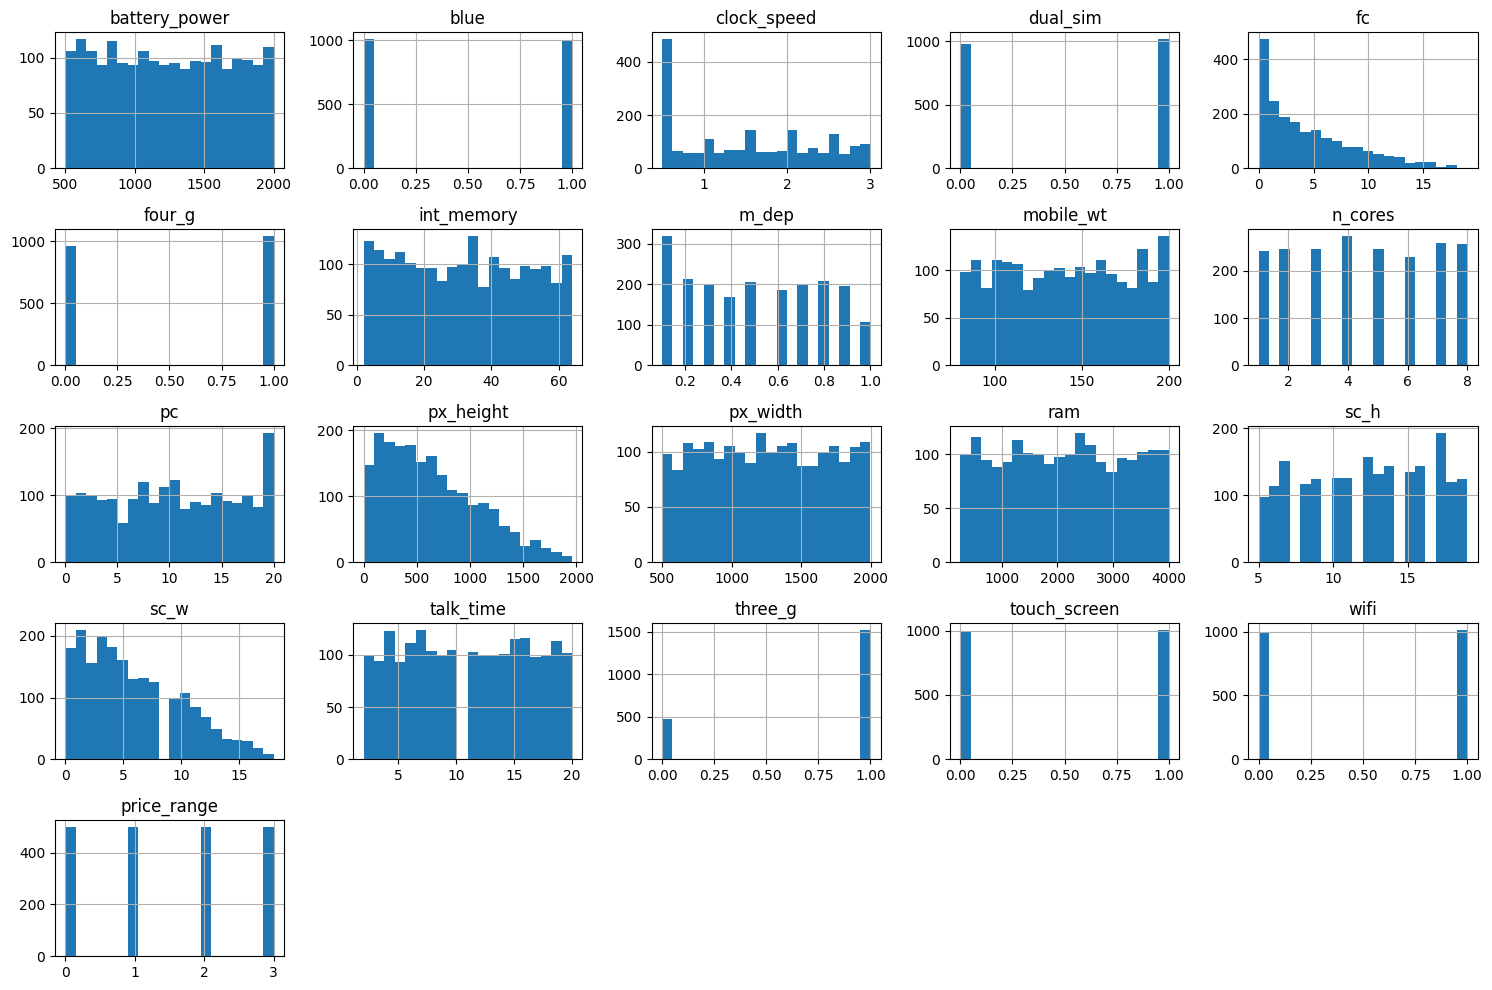

In [53]:
mobile_df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [54]:
mobile_df['px_height'].describe()

count    2000.000000
mean      645.108000
std       443.780811
min         0.000000
25%       282.750000
50%       564.000000
75%       947.250000
max      1960.000000
Name: px_height, dtype: float64

## Frequent Patterns

In [55]:
df = mobile_df.copy()
df.drop(columns=['price_range'], inplace=True)

In [56]:
focus_cols = df.columns

In [57]:
for col in focus_cols:
    low_th, high_th = low_high_threshold(df[col])
    df[col] = df[col].apply(lambda x: categorization(x, low_th, high_th))
    df[col] = f'{col}_' + df[col]

In [58]:
dataset = df.to_numpy()

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
transaction_df = pd.DataFrame(te_ary, columns=te.columns_)

In [59]:
frequent_itemsets = fpgrowth(transaction_df, min_support=0.1, use_colnames=True)

In [60]:
frequent_itemsets.sort_values(by=['support'], ascending=False).head(20)

,support,itemsets
20,0.7615,frozenset({three_g_high})
0,0.6750,frozenset({fc_low})
21,0.5440,frozenset({sc_w_low})
1252,0.5215,"frozenset({four_g_high, three_g_high})"
22,0.5215,frozenset({four_g_high})
1,0.5155,frozenset({px_height_low})
51,0.5145,"frozenset({fc_low, three_g_high})"
23,0.5095,frozenset({dual_sim_high})
2,0.5070,frozenset({wifi_high})
3,0.5050,frozenset({blue_low})


In [61]:
# frequent_itemsets['item_length'] = frequent_itemsets['itemsets'].apply(len)

## Association rules

In [62]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

In [63]:
rules_filtered = rules[
    (rules["support"] >= 0.1) &
    (rules["confidence"] >= 0.7) &
    (rules["lift"] >= 0.8)
]

In [64]:
top_rules = rules_filtered.copy()
top_rules['ante_length'] = top_rules['antecedents'].apply(len)
top_rules['cons_length'] = top_rules['consequents'].apply(len)
top_rules['rule_length'] = top_rules['ante_length'] + top_rules['cons_length']

In [65]:
top_rules.sort_values(by=['lift'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,ante_length,cons_length,rule_length
2963,"frozenset({three_g_low, wifi_low})",frozenset({four_g_low}),0.1185,0.4785,0.1185,1.000000,2.089864,1.0,0.061798,inf,0.591605,0.247649,1.000000,0.623824,2,1,3
2966,"frozenset({touch_screen_high, three_g_low})",frozenset({four_g_low}),0.1170,0.4785,0.1170,1.000000,2.089864,1.0,0.061016,inf,0.590600,0.244514,1.000000,0.622257,2,1,3
2958,"frozenset({dual_sim_high, three_g_low})",frozenset({four_g_low}),0.1245,0.4785,0.1245,1.000000,2.089864,1.0,0.064927,inf,0.595660,0.260188,1.000000,0.630094,2,1,3
2954,"frozenset({blue_high, three_g_low})",frozenset({four_g_low}),0.1245,0.4785,0.1245,1.000000,2.089864,1.0,0.064927,inf,0.595660,0.260188,1.000000,0.630094,2,1,3
2950,"frozenset({sc_w_low, three_g_low})",frozenset({four_g_low}),0.1285,0.4785,0.1285,1.000000,2.089864,1.0,0.067013,inf,0.598394,0.268548,1.000000,0.634274,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7250,"frozenset({touch_screen_low, mobile_wt_low})",frozenset({three_g_high}),0.1505,0.7615,0.1075,0.714286,0.937998,1.0,-0.007106,0.834750,-0.072193,0.133623,-0.197963,0.427727,2,1,3
3430,"frozenset({sc_w_low, blue_high, dual_sim_high})",frozenset({three_g_high}),0.1455,0.7615,0.1035,0.711340,0.934130,1.0,-0.007298,0.826232,-0.076231,0.128811,-0.210314,0.423628,3,1,4
1742,"frozenset({pc_medium, sc_w_medium})",frozenset({three_g_high}),0.1520,0.7615,0.1070,0.703947,0.924422,1.0,-0.008748,0.805600,-0.087934,0.132672,-0.241311,0.422230,2,1,3
5872,"frozenset({sc_h_medium, blue_high})",frozenset({three_g_high}),0.1700,0.7615,0.1195,0.702941,0.923101,1.0,-0.009955,0.802871,-0.091213,0.147167,-0.245530,0.429934,2,1,3


<Axes: ylabel='lift'>

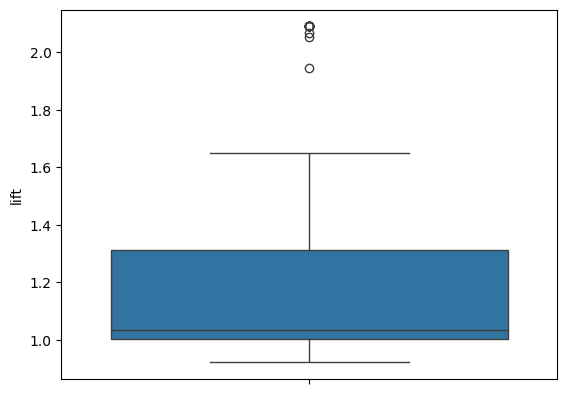

In [68]:
sns.boxplot(top_rules['lift'])

In [69]:
iqr = top_rules['lift'].quantile(0.75) - top_rules['lift'].quantile(0.25)
high_corr_threshold = top_rules['lift'].quantile(0.75) + 1.5*iqr
high_corr_threshold

np.float64(1.781563807171161)

In [70]:
top_rules = top_rules[top_rules['lift']>high_corr_threshold]

In [71]:
import re

In [72]:
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: [re.sub(r'\_low|\_medium|\_high', '', i) for i in list(x)])
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: [re.sub(r'\_low|\_medium|\_high', '', i) for i in list(x)])

In [73]:
def union_overlapping_lists(lists):
    sets = [set(lst) for lst in lists]
    merged = True
    
    while merged:
        merged = False
        results = []
        while sets:
            current = sets.pop(0)
            rest = []
            for s in sets:
                # Nếu có phần tử chung
                if not current.isdisjoint(s):
                    current.update(s)
                    merged = True
                else:
                    rest.append(s)
            results.append(current)
            sets = rest
        sets = results
        
    return [sorted(list(s)) for s in sets]

In [74]:
ante_cons_list = top_rules['antecedents'] + top_rules['consequents']

In [75]:
high_corr_feature_sets = union_overlapping_lists(ante_cons_list.values)
high_corr_feature_sets

[['blue',
  'dual_sim',
  'fc',
  'four_g',
  'pc',
  'px_height',
  'px_width',
  'sc_h',
  'sc_w',
  'three_g',
  'touch_screen',
  'wifi']]

## Kmeans with new features

In [76]:
X = mobile_df.drop(columns=['price_range'])
y = mobile_df["price_range"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Standardized feature shape:", X_scaled.shape)

Original feature shape: (2000, 20)
Standardized feature shape: (2000, 20)


In [77]:
all_feature_cols = mobile_df.drop(columns=["price_range"]).columns
df = pd.DataFrame(data=X_scaled, columns = all_feature_cols)
df.shape

(2000, 20)

In [78]:
high_corr_cols = np.array(high_corr_feature_sets).flatten()
distilled_df = df.drop(columns = high_corr_cols)

In [79]:
X_final = distilled_df.to_numpy()
for high_corr_set in high_corr_feature_sets:
    high_corr_df = df[high_corr_cols].copy()
    X_high_corr_scaled = high_corr_df.to_numpy()
    pca = PCA(n_components=1, random_state=42)
    X_pca = pca.fit_transform(X_high_corr_scaled)
    print('X_pca shape: ', X_pca.shape)
    X_final = np.concatenate([X_final, X_pca], axis = 1)

X_pca shape:  (2000, 1)


In [80]:
X_final.shape

(2000, 9)

In [81]:
scores = []
for rd in [0, 10, 42, 100, 999]:
    kmeans = KMeans(
        n_clusters=4,
        random_state=rd,
        n_init=10
    )

    cluster_new = kmeans.fit_predict(X_final)

    ari_new = adjusted_rand_score(y, cluster_new)
    scores.append(ari_new)

    print("Adjusted Rand Score using new standardized features:", ari_new)
    
print(np.mean(scores), np.std(scores))

Adjusted Rand Score using new standardized features: 0.007561318145062724
Adjusted Rand Score using new standardized features: 0.003216197826389823
Adjusted Rand Score using new standardized features: 0.09285996704242655
Adjusted Rand Score using new standardized features: 0.009047010057106767
Adjusted Rand Score using new standardized features: 0.057777626280852576
0.03409242387036769 0.03549401809462842


In [82]:
scores = []
for rd in [0,10,42,100,999]:
    kmeans_all = KMeans(
        n_clusters=4,
        random_state=rd,
        n_init=10
    )

    cluster_all = kmeans_all.fit_predict(X_scaled)

    ari_all = adjusted_rand_score(y, cluster_all)
    scores.append(ari_all)

    print("Adjusted Rand Score using all standardized features:", ari_all)
    
print(np.mean(scores), np.std(scores))

Adjusted Rand Score using all standardized features: 0.005262653552611806
Adjusted Rand Score using all standardized features: 0.005609904212713027
Adjusted Rand Score using all standardized features: 0.005961567406388764
Adjusted Rand Score using all standardized features: 0.005520453922284243
Adjusted Rand Score using all standardized features: 0.006834050783514811
0.00583772597550253 0.000546126803222096


In [83]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

def map_cluster_to_label(y_true, y_cluster):
    cm = confusion_matrix(y_true, y_cluster)
    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {}
    for true_label, cluster_label in zip(row_ind, col_ind):
        mapping[cluster_label] = true_label

    y_pred = np.array([mapping[c] for c in y_cluster])
    return y_pred

def evaluate_kmeans_features(X_features, y, seeds):
    results = []

    for seed in seeds:
        kmeans = KMeans(n_clusters=4, random_state=seed, n_init=10)
        clusters = kmeans.fit_predict(X_features)

        y_pred = map_cluster_to_label(y, clusters)

        results.append({
            "seed": seed,
            "accuracy": accuracy_score(y, y_pred),
            "precision": precision_score(y, y_pred, average="macro"),
            "recall": recall_score(y, y_pred, average="macro"),
            "f1": f1_score(y, y_pred, average="macro"),
        })

    return pd.DataFrame(results)

In [84]:
seeds = [0, 10, 42, 100, 999]

baseline_results = evaluate_kmeans_features(X_scaled, y, seeds)
improved_results = evaluate_kmeans_features(X_final, y, seeds)

print("Original K-means")
display(baseline_results)
print('Overall performance: Average ± Standard Deviation')
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    print(f'{metric}: {baseline_results[metric].mean():.4f} ± {baseline_results[metric].std():.4f}')

print("\nImproved K-means with Association Rule Feature Reduction")
display(improved_results)
print('Overall performance: Average ± Standard Deviation')
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    print(f'{metric}: {improved_results[metric].mean():.4f} ± {improved_results[metric].std():.4f}')

Original K-means


,seed,accuracy,precision,recall,f1
0,0,0.2945,0.294042,0.2945,0.292637
1,10,0.2955,0.295336,0.2955,0.293648
2,42,0.2970,0.296623,0.2970,0.295035
3,100,0.2955,0.294995,0.2955,0.293510
4,999,0.2985,0.298367,0.2985,0.295579


Overall performance: Average ± Standard Deviation
accuracy: 0.2962 ± 0.0016
precision: 0.2959 ± 0.0017
recall: 0.2962 ± 0.0016
f1: 0.2941 ± 0.0012

Improved K-means with Association Rule Feature Reduction


,seed,accuracy,precision,recall,f1
0,0,0.2930,0.294196,0.2930,0.293274
1,10,0.2710,0.269687,0.2710,0.269334
2,42,0.4095,0.419700,0.4095,0.413888
3,100,0.2975,0.297790,0.2975,0.297441
4,999,0.3710,0.382407,0.3710,0.375524


Overall performance: Average ± Standard Deviation
accuracy: 0.3284 ± 0.0589
precision: 0.3328 ± 0.0646
recall: 0.3284 ± 0.0589
f1: 0.3299 ± 0.0616
